# Libraries

In [ ]:
!pip install ucimlrepo
!pip install torch_geometric
!pip install faiss-gpu
!pip install networkx
!pip install torchmetrics
!pip install sklearn
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 42.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import from_networkx
import faiss
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
import torchmetrics.functional as FM
from sklearn.model_selection import train_test_split
import torch.nn as nn

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [ ]:
# import dataset
breast_cancer = fetch_ucirepo(id=17)

# access data
X = breast_cancer.data.features
y = breast_cancer.data.targets
# train model e.g. sklearn.linear_model.LinearRegression().fit(X, y)

In [ ]:
data = pd.concat([X,y], axis=1)

In [ ]:
data

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


In [ ]:
data.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

### Data Pre-Processing

In [ ]:
# Encoding Target Values
string_columns = data.select_dtypes(include=['object']).columns

data_encoding = data.copy()

for col in string_columns:
    label_encoder = LabelEncoder()
    data_encoding[col] = label_encoder.fit_transform(data[col])

data = data_encoding
data

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [ ]:
# After encoding
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

### Exploratory Data Analysis

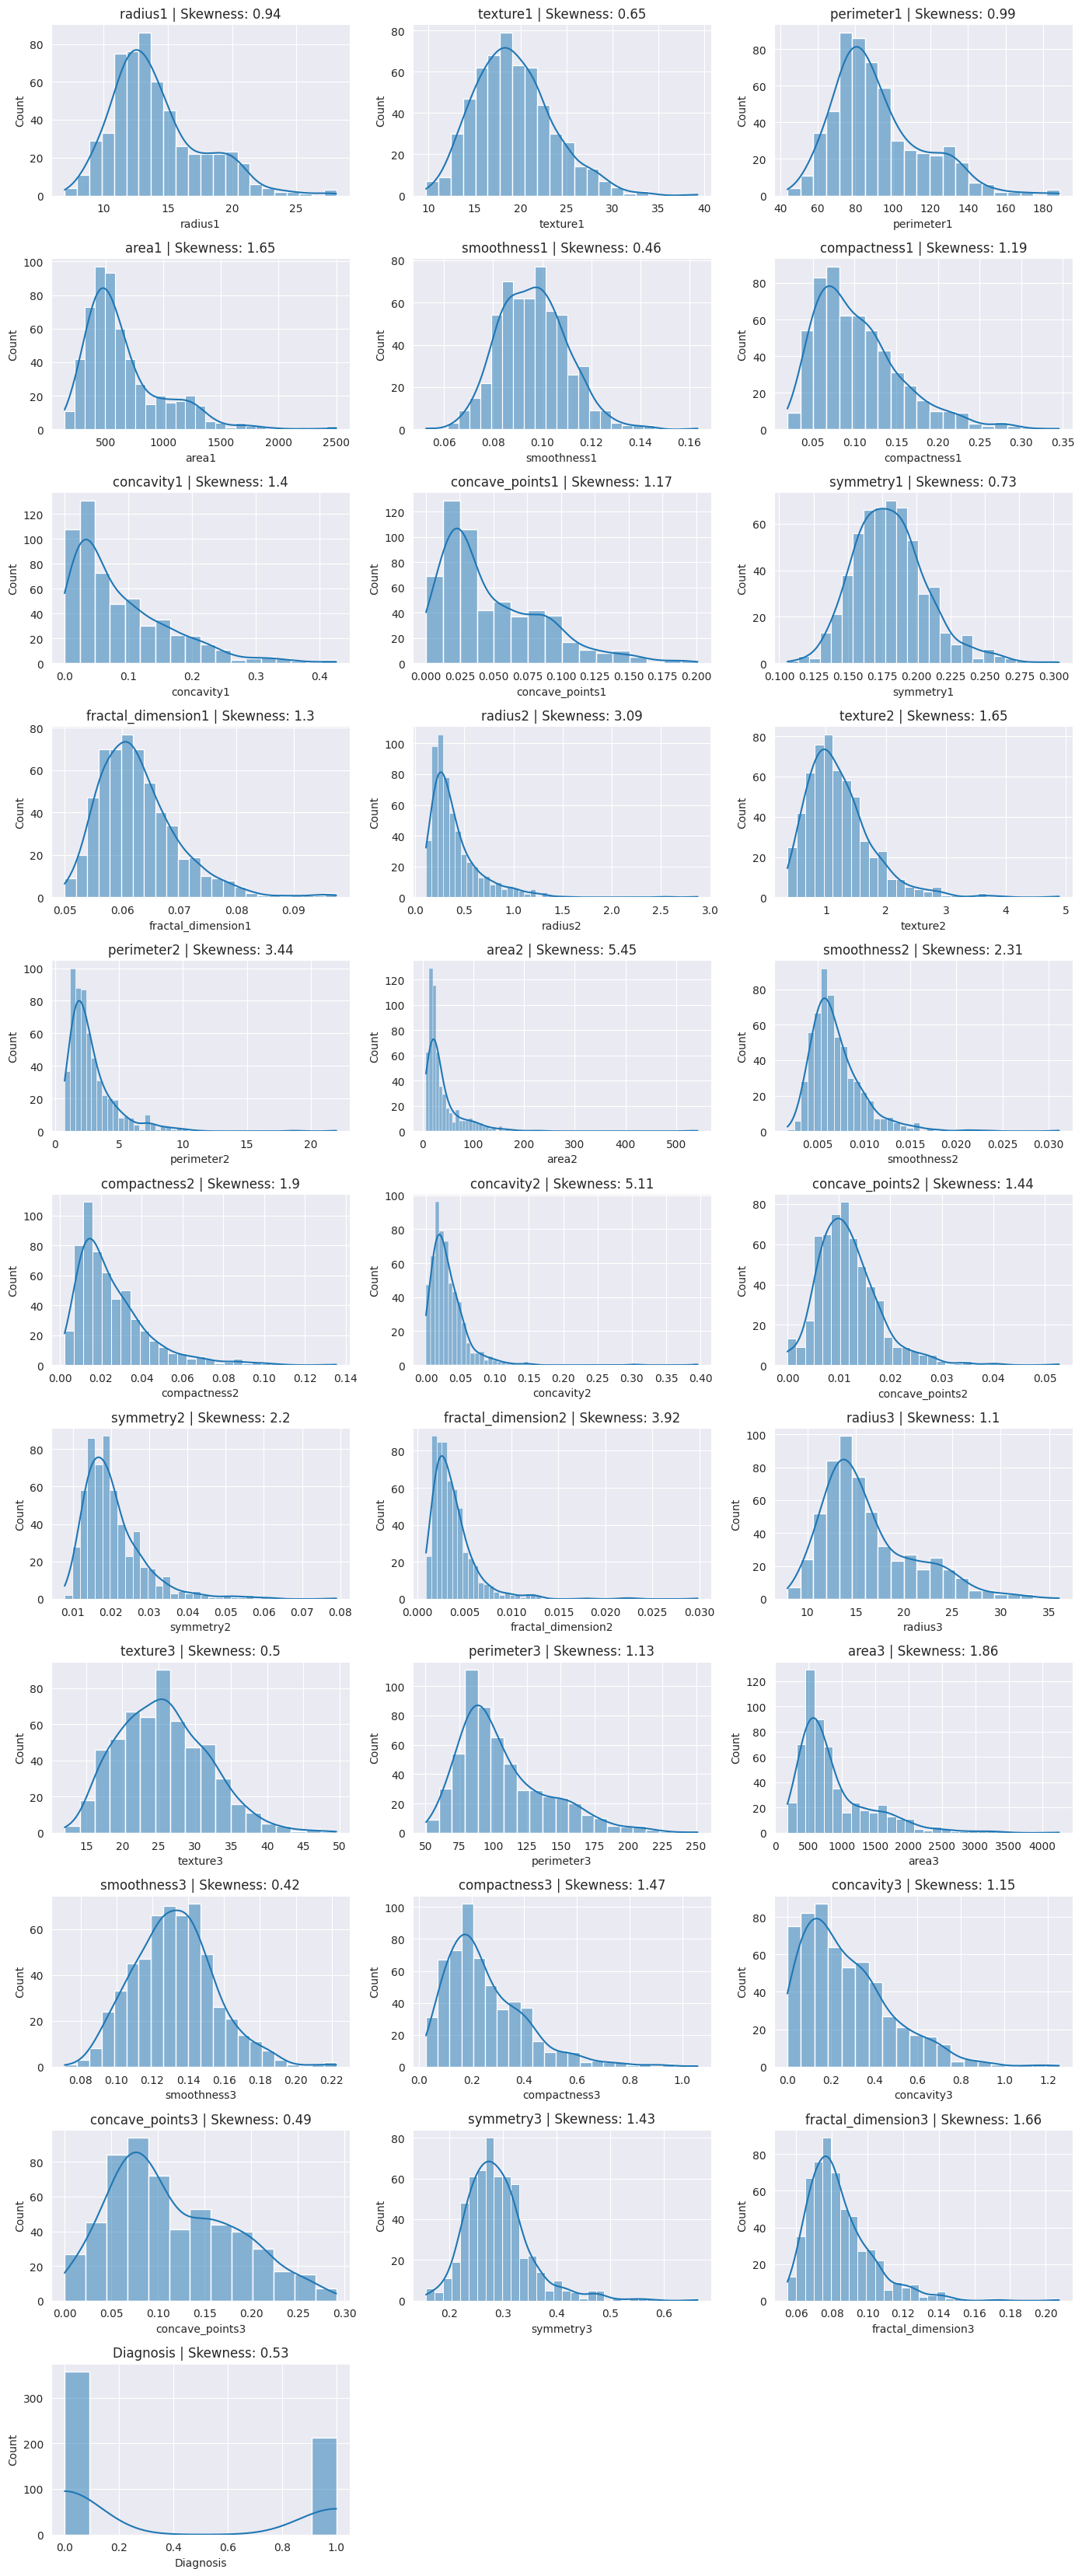

In [ ]:
# Set Seaborn style
sns.set_style("darkgrid")

# Plot distribution of each feature and target
plt.figure(figsize=(14, len(data.columns) * 3))
for idx, feature in enumerate(data.columns, 1):
    plt.subplot(len(data.columns), 3, idx)
    sns.histplot(data[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

# Adjust layout and show plots
plt.tight_layout()
plt.show()

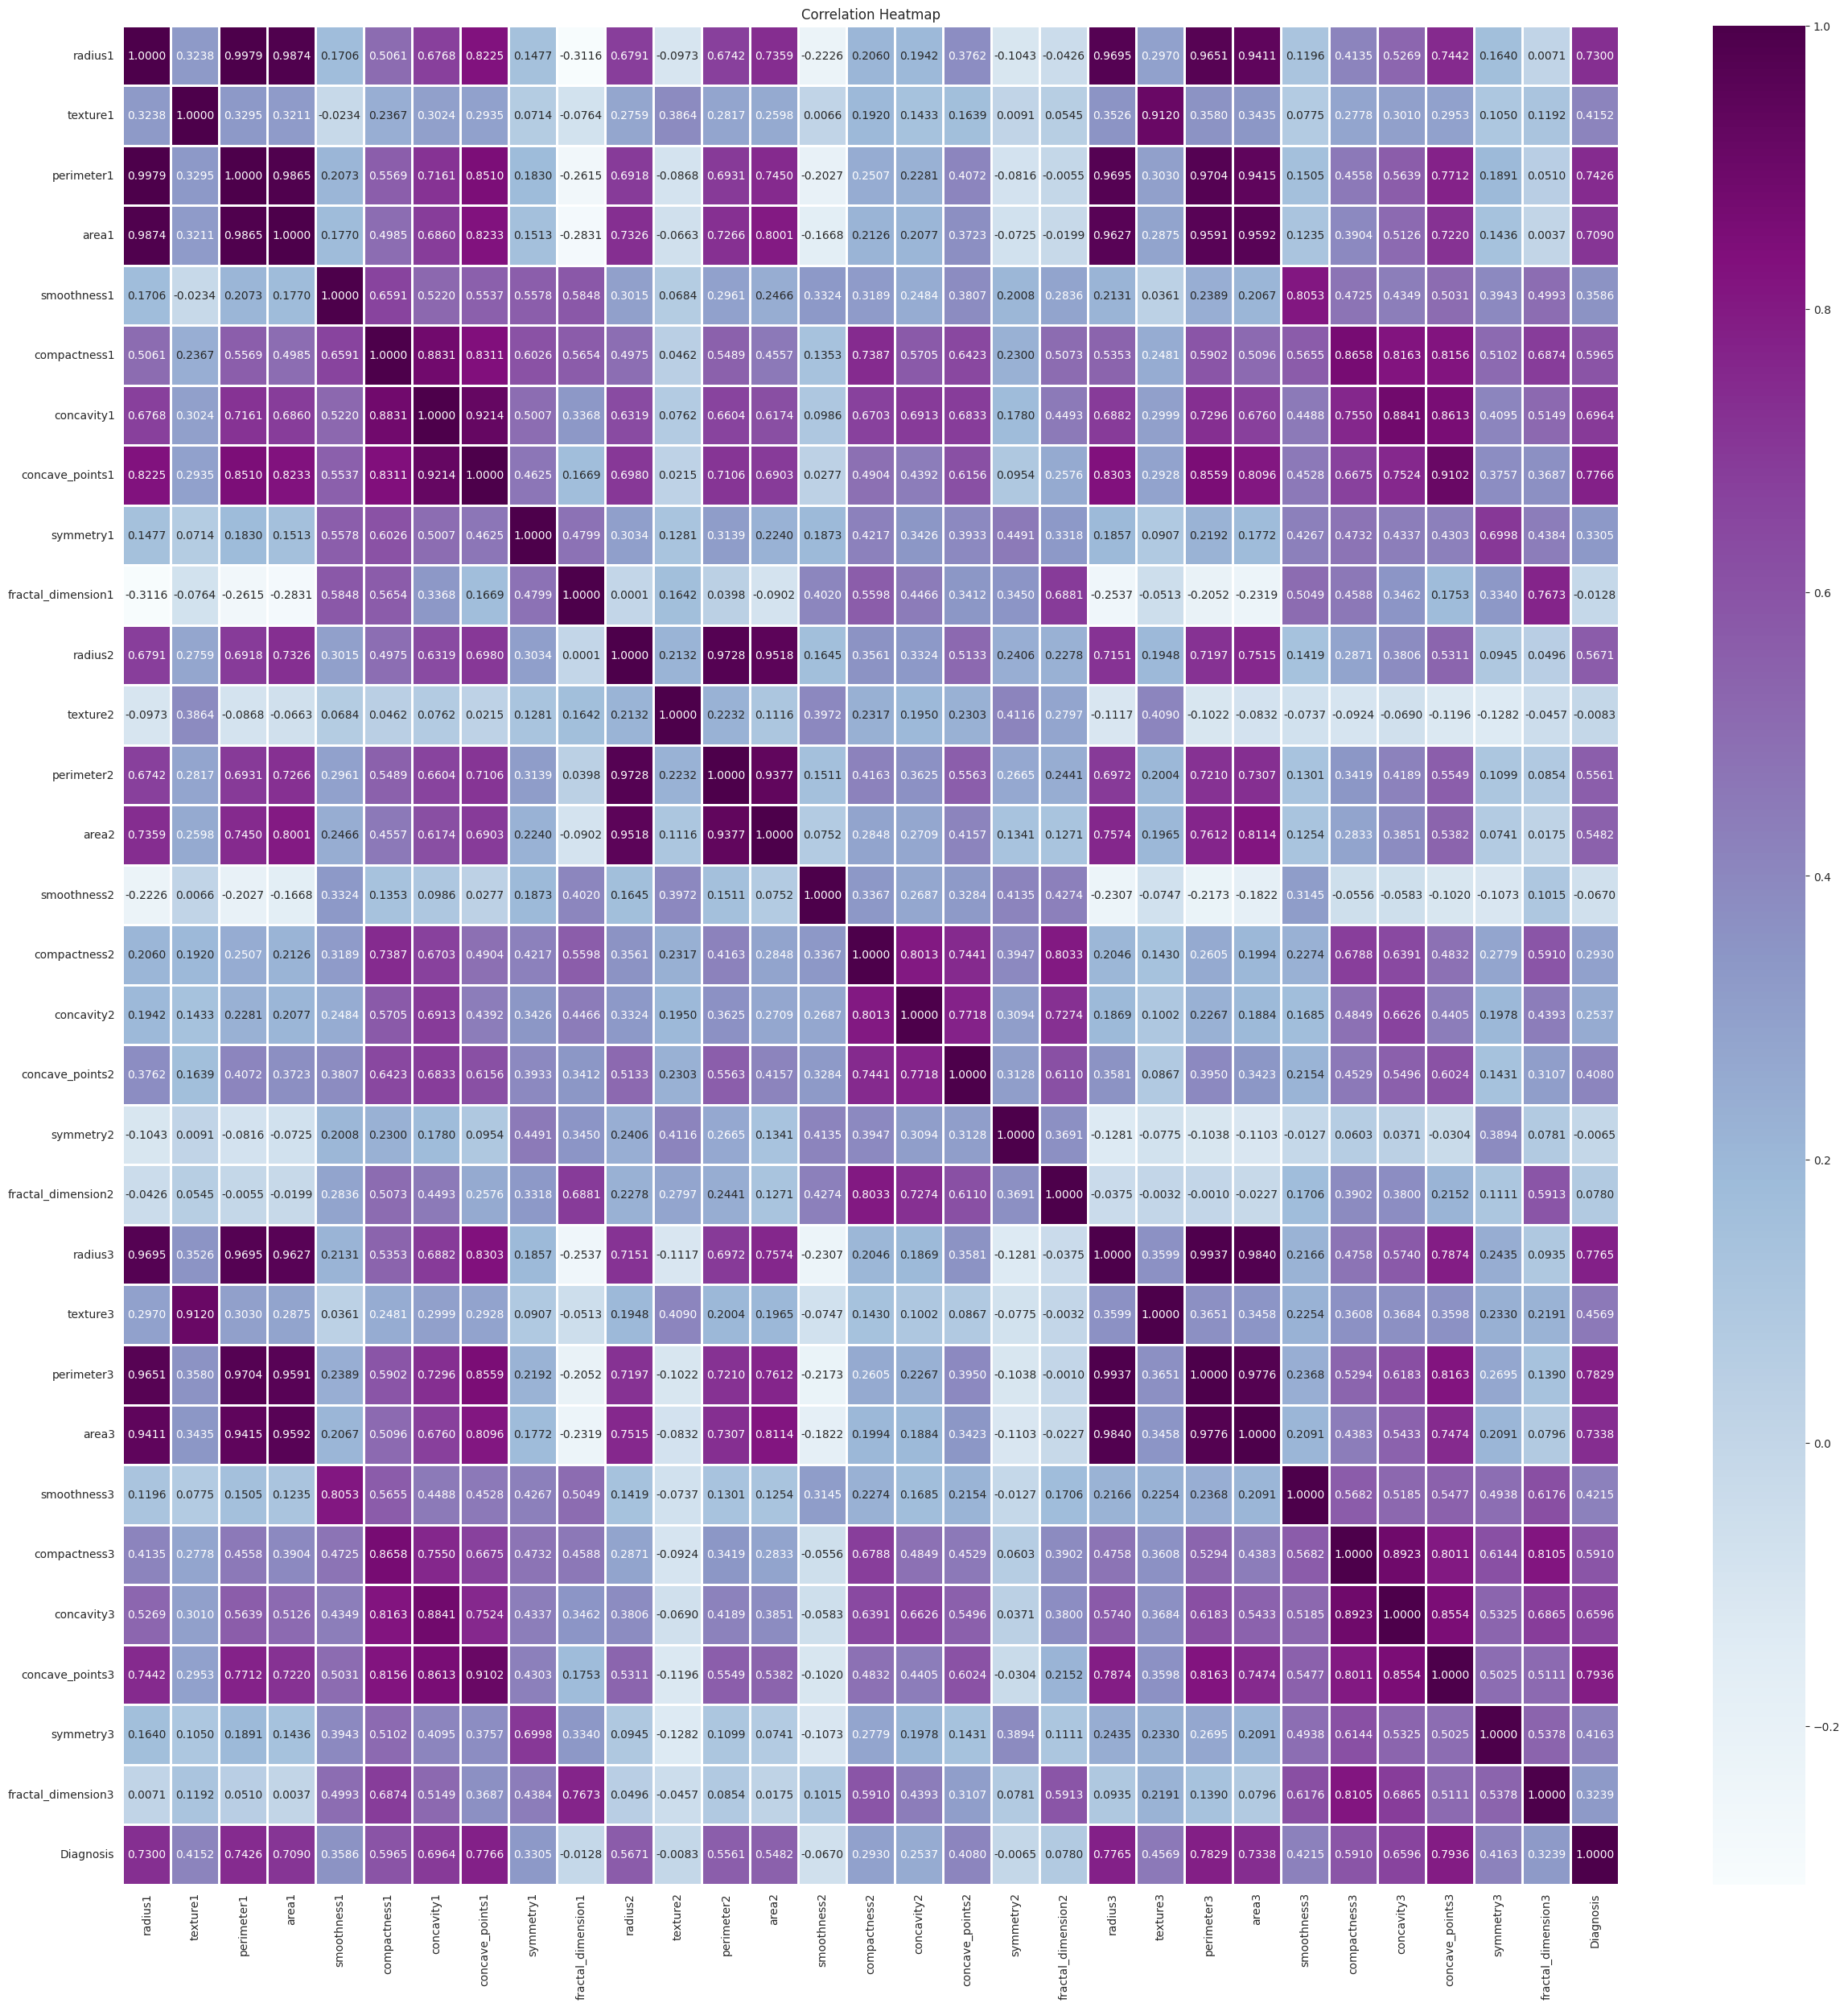

In [ ]:
plt.figure(figsize=(30, 30))

# Using Seaborn to create a heatmap
sns.heatmap(data[data.columns].corr(), annot=True, fmt='.4f', cmap='BuPu', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

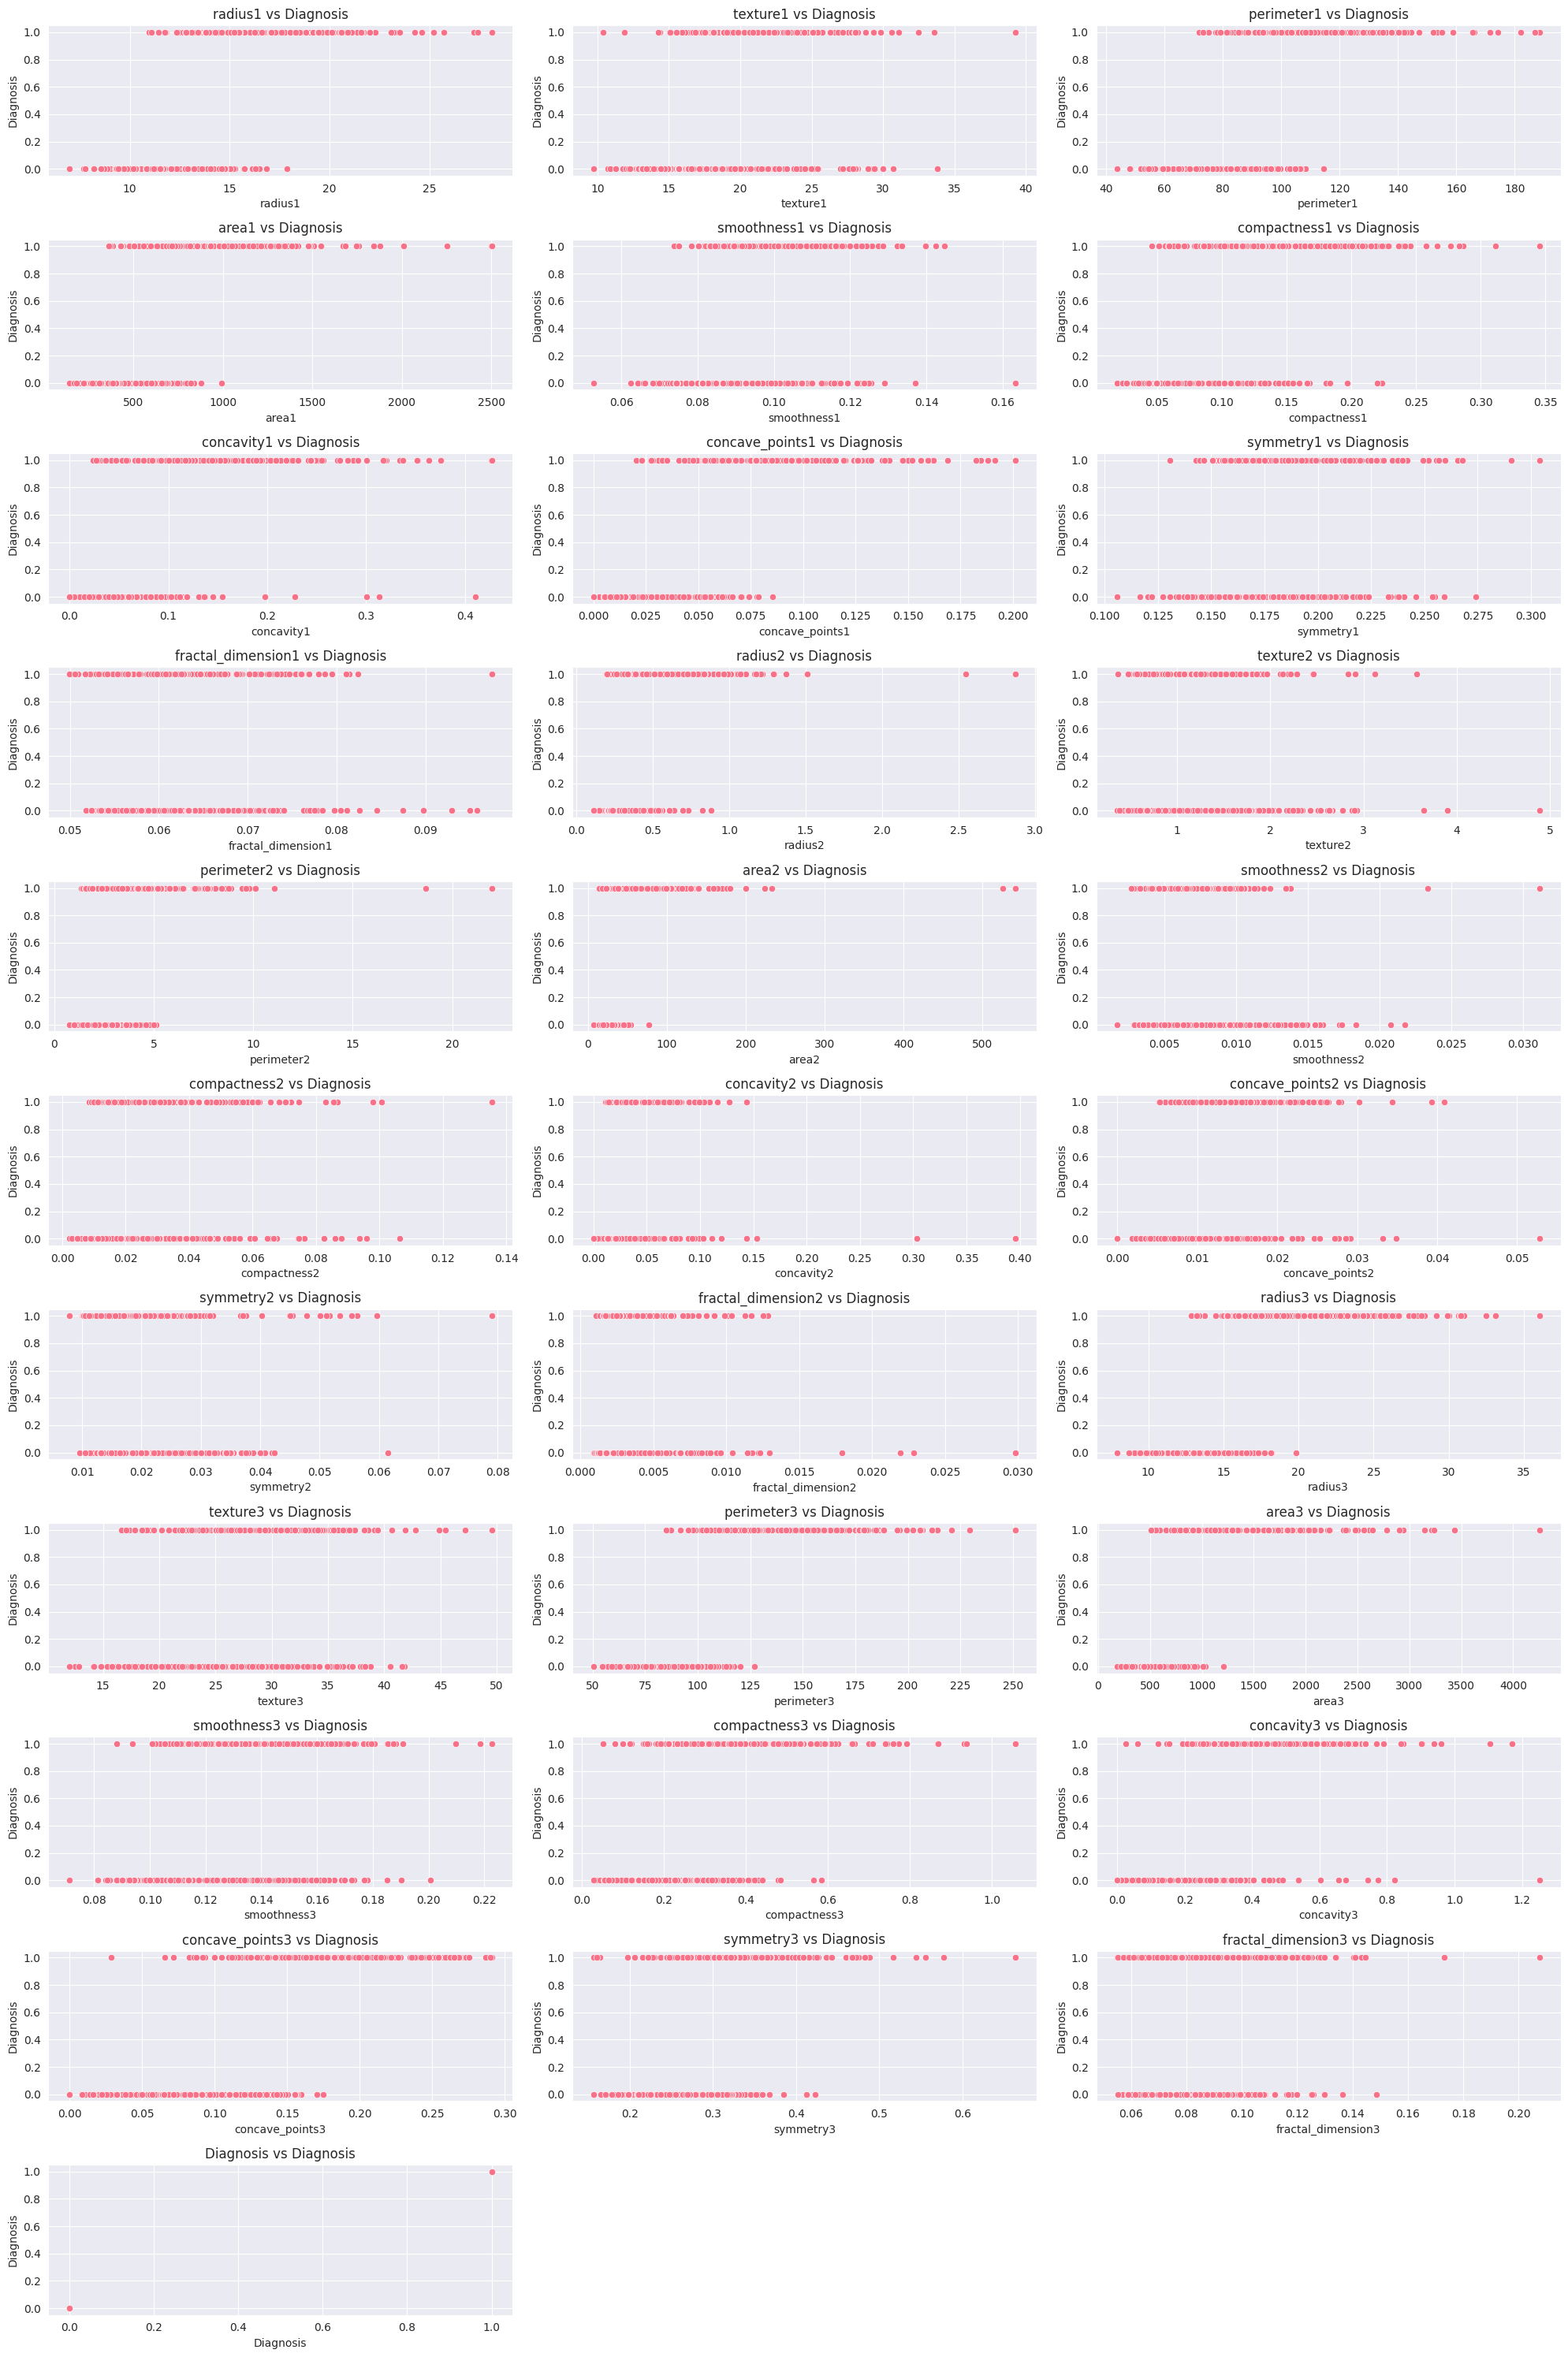

In [ ]:
# Set Seaborn style
sns.set_style("darkgrid")
sns.set_palette("husl")

target_variable = 'Diagnosis'

num_features = len(data.columns)
nrows, ncols = 11, 3  # Define subplot grid dimensions

plt.figure(figsize=(20, 30))  # Adjust the figure size as needed

for i, column in enumerate(data.columns):
    plt.subplot(nrows, ncols, i + 1)  # Create a subplot for each feature
    sns.scatterplot(data=data, x=column, y=target_variable)
    plt.title(f'{column} vs {target_variable}')
    plt.xlabel(column)
    plt.ylabel(target_variable)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

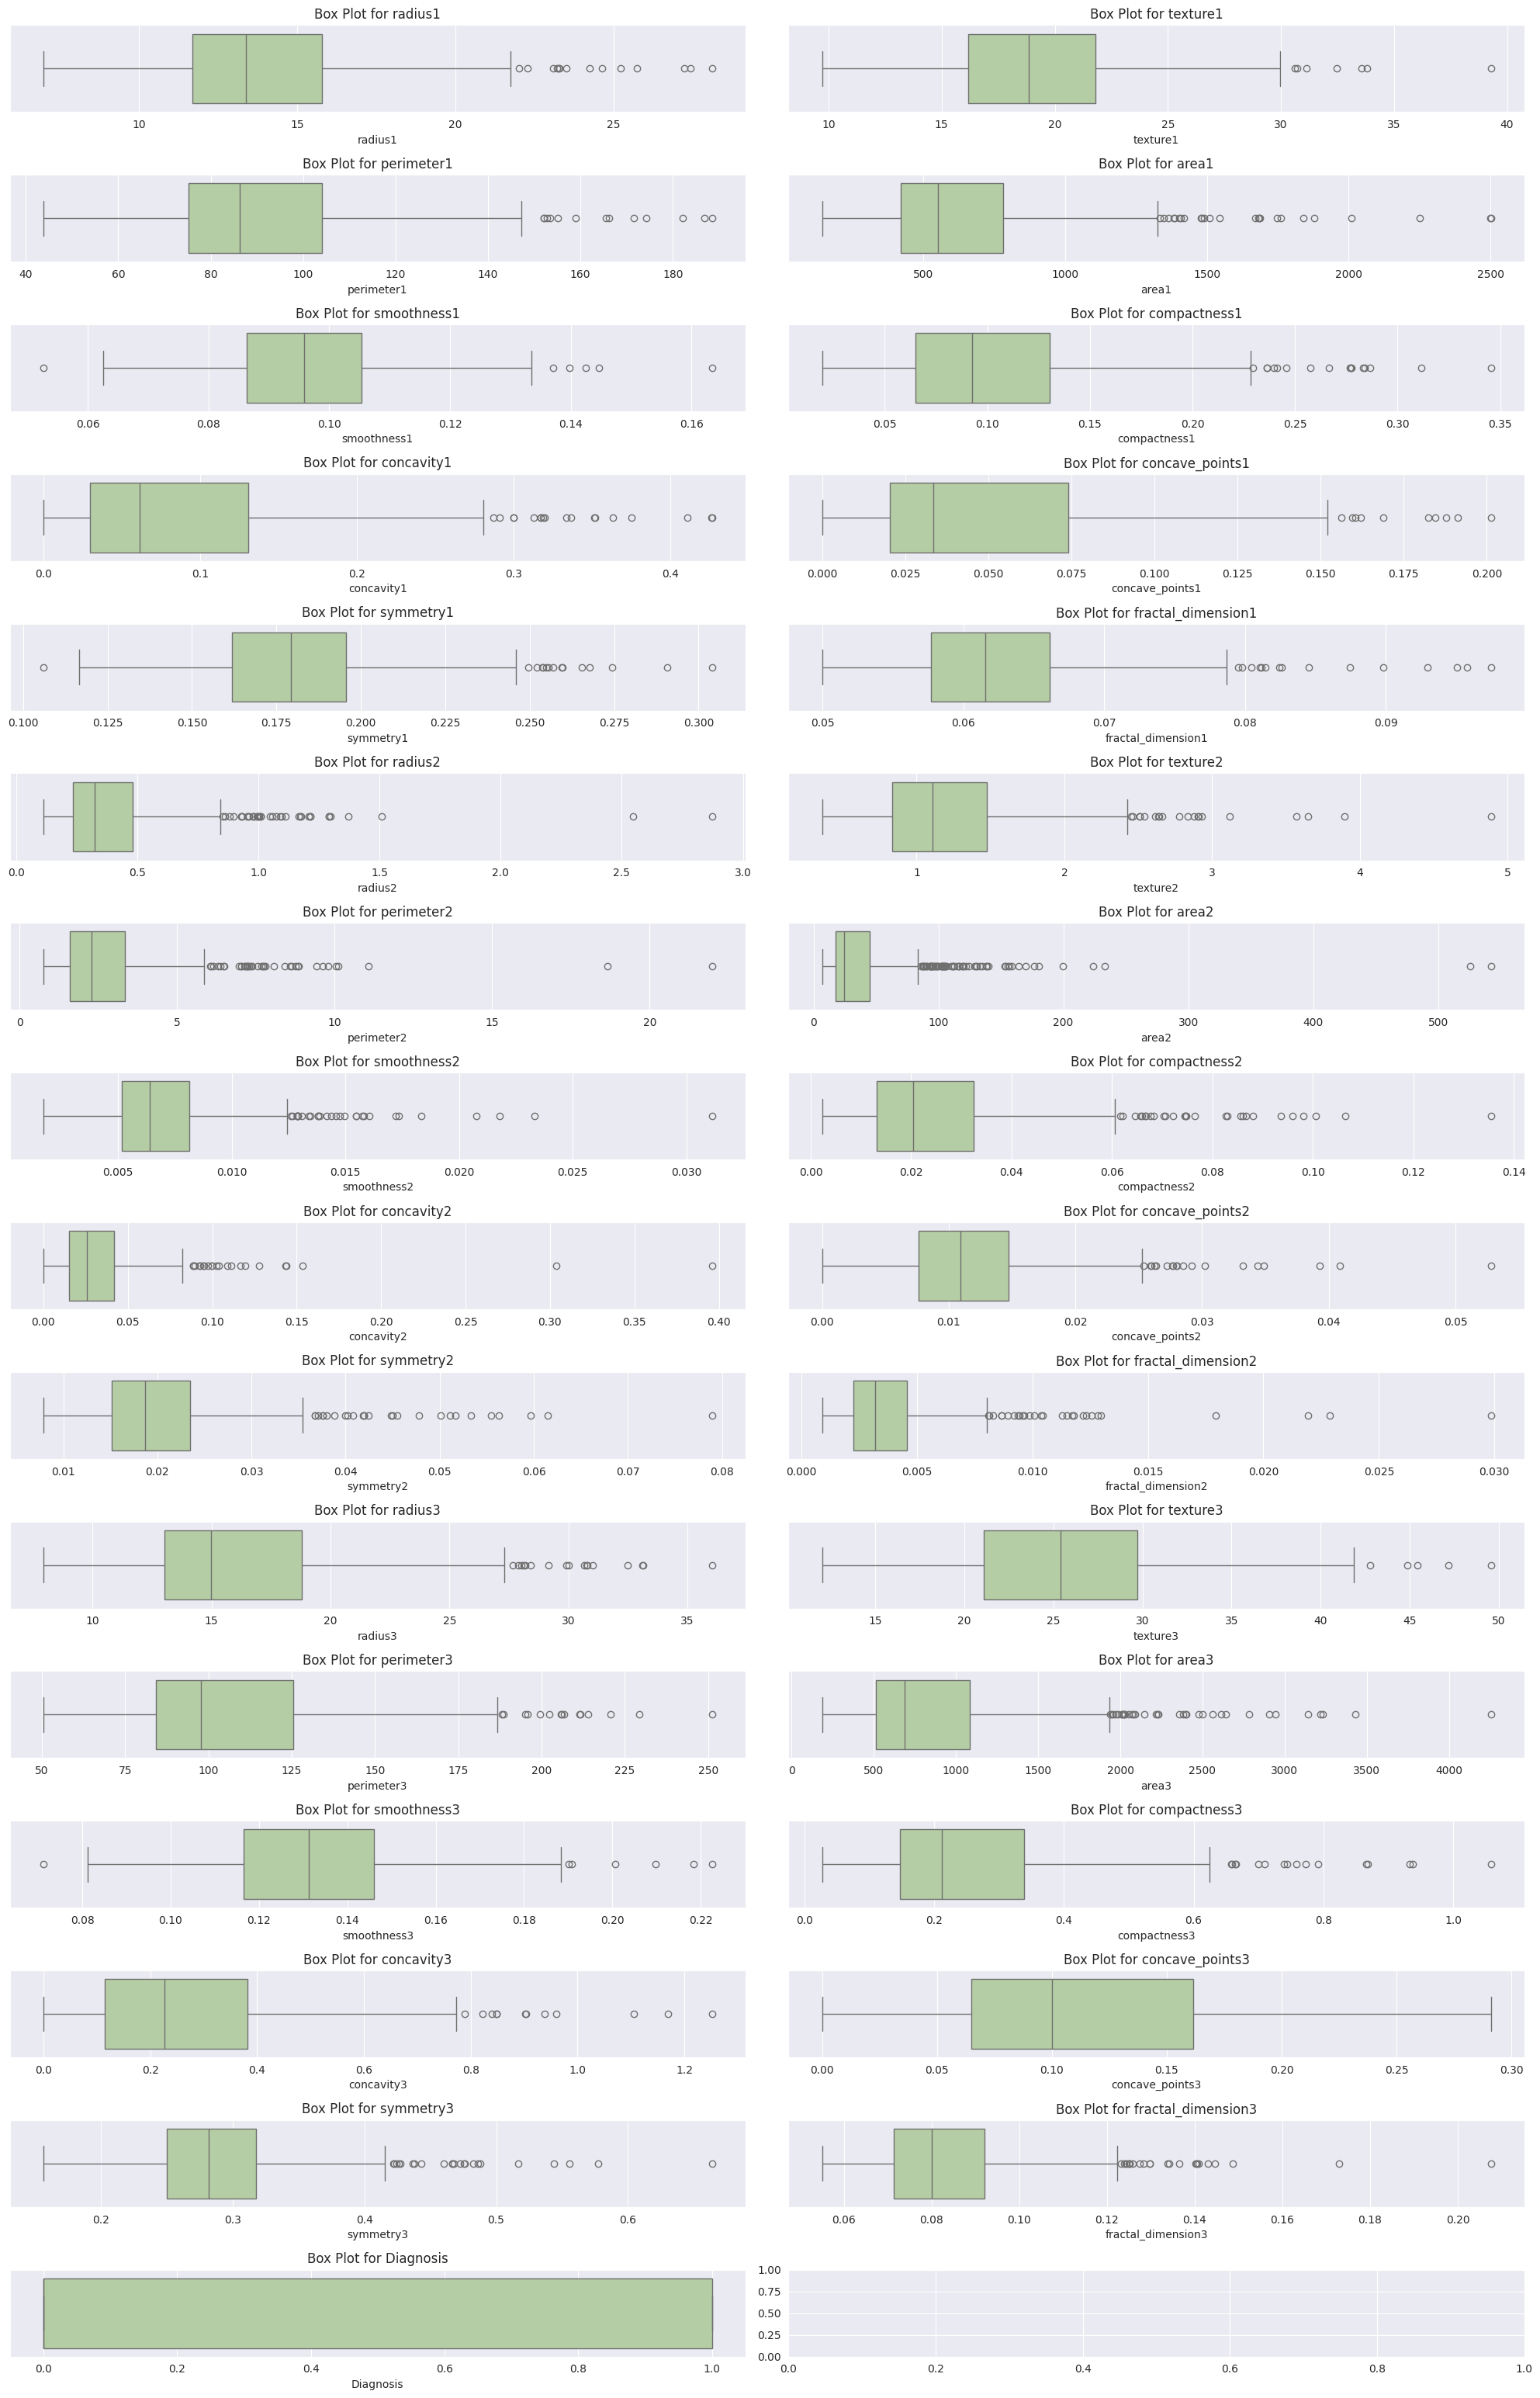

In [ ]:
fig, axes = plt.subplots(nrows=16, ncols=2, figsize=(20, len(data.columns)))

plt_count = 0
for i in range(0,17):
    for j in range(0,2):
        if plt_count >= len(data.columns):
            break
        sns.boxplot(x=data[data.columns[plt_count]], ax=axes[i,j], color='#b4d49d')
        axes[i, j].set_title(f'Box Plot for {data.columns[plt_count]}')
        axes[i, j].set_xlabel(data.columns[plt_count])
        plt_count += 1

plt.tight_layout()
plt.show()

# Graph Learning

In [ ]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

### Transductive Setting

##### GCN

In [ ]:
from torch_geometric.nn import GCNConv  # Import GCN layer

hidden_channels = 64
optimizer = torch.optim.Adam

class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.gcn_conv1 = GCNConv(num_features, hidden_channels)
        self.gcn_conv2 = GCNConv(hidden_channels, num_classes)
        self.init_weights()

    def init_weights(self):
        self.gcn_conv1.reset_parameters()
        self.gcn_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gcn_conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.gcn_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Then update the model instantiation in your cross-validation loop
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}")

    # Normalize train and test sets
    X_train = scaler.fit_transform(X.iloc[train_idx])
    X_test = scaler.transform(X.iloc[test_idx])

    # Update graph data with features
    data.x = torch.zeros_like(torch.tensor(X.values, dtype=torch.float))
    data.x[train_idx] = torch.tensor(X_train, dtype=torch.float)
    data.x[test_idx] = torch.tensor(X_test, dtype=torch.float)

    # Create a new GCN model for each fold
    model = GCN(num_features=X.shape[1], hidden_channels=hidden_channels, num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Create masks for training and testing
    data.train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.test_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.train_mask[train_idx] = True
    data.test_mask[test_idx] = True

    # Train the model for 600 epochs
    for epoch in range(600):
        train_loss = train(model, data, optimizer)

        if epoch % 10 == 0:
            train_acc = accuracy(model, data, data.train_mask)
            current_test_loss = test_loss(model, data)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model after training
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, data)
    print(f"\nFold {fold + 1} - Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}\n")

    # Append results
    test_accs.append(test_acc)
    test_f1s.append(test_f1)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    aurocs.append(auroc)


Fold 1
Epoch 0, Train Loss: 0.7179, Train Accuracy: 0.6719, Test Loss: 0.6103
Epoch 10, Train Loss: 0.5712, Train Accuracy: 0.7207, Test Loss: 0.5731
Epoch 20, Train Loss: 0.5620, Train Accuracy: 0.7188, Test Loss: 0.5607
Epoch 30, Train Loss: 0.5607, Train Accuracy: 0.7266, Test Loss: 0.5548
Epoch 40, Train Loss: 0.5563, Train Accuracy: 0.7285, Test Loss: 0.5637
Epoch 50, Train Loss: 0.5529, Train Accuracy: 0.7285, Test Loss: 0.5554
Epoch 60, Train Loss: 0.5468, Train Accuracy: 0.7266, Test Loss: 0.5515
Epoch 70, Train Loss: 0.5444, Train Accuracy: 0.7266, Test Loss: 0.5459
Epoch 80, Train Loss: 0.5404, Train Accuracy: 0.7305, Test Loss: 0.5520
Epoch 90, Train Loss: 0.5417, Train Accuracy: 0.7305, Test Loss: 0.5434
Epoch 100, Train Loss: 0.5360, Train Accuracy: 0.7324, Test Loss: 0.5380
Epoch 110, Train Loss: 0.5316, Train Accuracy: 0.7285, Test Loss: 0.5380
Epoch 120, Train Loss: 0.5272, Train Accuracy: 0.7285, Test Loss: 0.5409
Epoch 130, Train Loss: 0.5291, Train Accuracy: 0.7285, 

In [ ]:
print(sum(test_accs) / len(test_accs))
print(sum(test_f1s) / len(test_f1s))
print(sum(test_precisions) / len(test_precisions))
print(sum(test_recalls) / len(test_recalls))
print(sum(aurocs) / len(aurocs))

0.8594193817878026
0.8373730311791102
0.8566003561019897
0.8365436752637228
0.8805696964263916


##### GAT

In [ ]:
from torch_geometric.nn import GATConv  # Import GAT layer

hidden_channels = 256
optimizer = torch.optim.Adam

class GAT(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes, heads=8):
        super(GAT, self).__init__()
        self.gat_conv1 = GATConv(num_features, hidden_channels, heads=heads)
        self.gat_conv2 = GATConv(hidden_channels * heads, num_classes, heads=1)  # Output layer only uses 1 head
        self.init_weights()

    def init_weights(self):
        self.gat_conv1.reset_parameters()
        self.gat_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gat_conv1(x, edge_index)
        x = F.elu(x)  # Use ELU non-linearity for GAT
        x = F.dropout(x, training=self.training)
        x = self.gat_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Then update the model instantiation in your cross-validation loop
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}")

    # Normalize train and test sets
    X_train = scaler.fit_transform(X.iloc[train_idx])
    X_test = scaler.transform(X.iloc[test_idx])

    # Update graph data with features
    data.x = torch.zeros_like(torch.tensor(X.values, dtype=torch.float))
    data.x[train_idx] = torch.tensor(X_train, dtype=torch.float)
    data.x[test_idx] = torch.tensor(X_test, dtype=torch.float)

    # Create a new GAT model for each fold
    model = GAT(num_features=X.shape[1], hidden_channels=hidden_channels, num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Create masks for training and testing
    data.train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.test_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.train_mask[train_idx] = True
    data.test_mask[test_idx] = True

    # Train the model for 600 epochs
    for epoch in range(600):
        train_loss = train(model, data, optimizer)

        if epoch % 10 == 0:
            train_acc = accuracy(model, data, data.train_mask)
            current_test_loss = test_loss(model, data)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model after training
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, data)
    print(f"\nFold {fold + 1} - Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}\n")

    # Append results
    test_accs.append(test_acc)
    test_f1s.append(test_f1)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    aurocs.append(auroc)


Fold 1
Epoch 0, Train Loss: 0.6936, Train Accuracy: 0.6895, Test Loss: 1.1237
Epoch 10, Train Loss: 0.8363, Train Accuracy: 0.4414, Test Loss: 1.8683
Epoch 20, Train Loss: 0.8437, Train Accuracy: 0.6992, Test Loss: 0.6246
Epoch 30, Train Loss: 0.5446, Train Accuracy: 0.7207, Test Loss: 0.4546
Epoch 40, Train Loss: 0.3738, Train Accuracy: 0.8301, Test Loss: 0.3768
Epoch 50, Train Loss: 0.2971, Train Accuracy: 0.9121, Test Loss: 0.3648
Epoch 60, Train Loss: 0.2320, Train Accuracy: 0.9258, Test Loss: 0.3106
Epoch 70, Train Loss: 0.1713, Train Accuracy: 0.9590, Test Loss: 0.2665
Epoch 80, Train Loss: 0.1546, Train Accuracy: 0.9688, Test Loss: 0.1946
Epoch 90, Train Loss: 0.1197, Train Accuracy: 0.9766, Test Loss: 0.1660
Epoch 100, Train Loss: 0.0978, Train Accuracy: 0.9824, Test Loss: 0.1713
Epoch 110, Train Loss: 0.0857, Train Accuracy: 0.9746, Test Loss: 0.1759
Epoch 120, Train Loss: 0.0812, Train Accuracy: 0.9863, Test Loss: 0.2110
Epoch 130, Train Loss: 0.0837, Train Accuracy: 0.9922, 

In [ ]:
print(sum(test_accs) / len(test_accs))
print(sum(test_f1s) / len(test_f1s))
print(sum(test_precisions) / len(test_precisions))
print(sum(test_recalls) / len(test_recalls))
print(sum(aurocs) / len(aurocs))

0.9332080200501253
0.9269401729106903
0.936625549197197
0.9257234394550323
0.9632732093334198


##### GraphSAGE (with tuned hyperparameters: Hidden Channel 320, Learning Rate 0.01, Weight Decay 5e-4, Optimizer RMSprop)

In [ ]:
# KNN graph construction (as in your original code)
k = 15
index = faiss.IndexFlatL2(X.shape[1])
X_contiguous = np.ascontiguousarray(X.values.astype(np.float32))
index.add(X_contiguous)
_, knn_graph = index.search(X_contiguous, k)

# NetworkX graph creation (as in your original code)
G = nx.Graph()
for i in range(X.shape[0]):
    for j in knn_graph[i]:
        G.add_edge(i, j)

data = from_networkx(G)  # Convert to a PyTorch Geometric data object
data.y = torch.tensor(y.values, dtype=torch.long)  # Convert labels to tensor

# Set hidden_channels and optimizer parameters
hidden_channels = 320
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.sage_conv1 = SAGEConv(num_features, hidden_channels)
        self.sage_conv2 = SAGEConv(hidden_channels, num_classes)
        self.init_weights()

    def init_weights(self):
        self.sage_conv1.reset_parameters()
        self.sage_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.sage_conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.sage_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.to(device))
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask].to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

def accuracy(model, data, mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits[mask].max(1)[1]
        correct = preds.eq(data.y[mask].to(device)).sum().item()
        acc = correct / mask.sum().item()
    return acc

def test_loss(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data.to(device))
        loss = F.nll_loss(out[data.test_mask], data.y[data.test_mask].to(device))
    return loss.item()

def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits[data.test_mask].max(1)[1]
        y_true = data.y[data.test_mask].to(device)
        y_pred = preds

        test_acc = (y_pred == y_true).sum().item() / y_true.size(0)
        test_precision = FM.precision(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_recall = FM.recall(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_f1 = FM.f1_score(y_pred, y_true, average='macro', num_classes=2, task='multiclass')

        probs = torch.softmax(logits[data.test_mask], dim=1)[:, 1]
        auroc = FM.auroc(probs, y_true, task='binary')

        fpr, tpr, _ = roc_curve(y_true.cpu().numpy(), probs.cpu().numpy())
        roc_auc = auc(fpr, tpr)

        return test_acc, test_f1.item(), test_precision.item(), test_recall.item(), auroc.item()

# Perform 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Lists to hold results from each fold
test_accs, test_f1s, test_precisions, test_recalls, aurocs = [], [], [], [], []

hidden_channels = 320
optimizer = torch.optim.SGD

scaler = StandardScaler()  # StandardScaler instance for normalization

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):  # Change from data.x to X (the feature matrix)
    print(f"Fold {fold + 1}")

    # Normalize the train and test sets separately
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    # Fit scaler on training data and transform both train and test sets
    X_train = scaler.fit_transform(X_train)  # Fit and transform the training set
    X_test = scaler.transform(X_test)        # Only transform the test set (don't fit again)

    # Convert normalized train and test sets back to tensors
    data.x = torch.zeros_like(torch.tensor(X.values, dtype=torch.float))
    data.x[train_idx] = torch.tensor(X_train, dtype=torch.float)
    data.x[test_idx] = torch.tensor(X_test, dtype=torch.float)

    # Create a new model for each fold
    model = GraphSAGE(num_features=X.shape[1], hidden_channels=hidden_channels, num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Create masks for training and testing
    data.train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.test_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
    data.train_mask[train_idx] = True
    data.test_mask[test_idx] = True

    # Train the model for 600 epochs
    for epoch in range(600):
        train_loss = train(model, data, optimizer)

        if epoch % 10 == 0:
            train_acc = accuracy(model, data, data.train_mask)
            current_test_loss = test_loss(model, data)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model after training
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, data)
    print(f"\nFold {fold + 1} - Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}\n")

    # Append results
    test_accs.append(test_acc)
    test_f1s.append(test_f1)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    aurocs.append(auroc)

# Calculate and print average results
print(f"\nAverage Test Accuracy: {np.mean(test_accs):.4f}, F1 Score: {np.mean(test_f1s):.4f}, Precision: {np.mean(test_precisions):.4f}, Recall: {np.mean(test_recalls):.4f}, AUROC: {np.mean(aurocs):.4f}\n")


Fold 1
Epoch 0, Train Loss: 0.7835, Train Accuracy: 0.8555, Test Loss: 0.2708
Epoch 10, Train Loss: 0.0592, Train Accuracy: 0.9863, Test Loss: 0.0983
Epoch 20, Train Loss: 0.0212, Train Accuracy: 0.9941, Test Loss: 0.1939
Epoch 30, Train Loss: 0.0171, Train Accuracy: 1.0000, Test Loss: 0.1966
Epoch 40, Train Loss: 0.0069, Train Accuracy: 1.0000, Test Loss: 0.1779
Epoch 50, Train Loss: 0.0059, Train Accuracy: 1.0000, Test Loss: 0.1503
Epoch 60, Train Loss: 0.0059, Train Accuracy: 1.0000, Test Loss: 0.1461
Epoch 70, Train Loss: 0.0043, Train Accuracy: 1.0000, Test Loss: 0.1694
Epoch 80, Train Loss: 0.0045, Train Accuracy: 1.0000, Test Loss: 0.1307
Epoch 90, Train Loss: 0.0039, Train Accuracy: 1.0000, Test Loss: 0.1657
Epoch 100, Train Loss: 0.0045, Train Accuracy: 1.0000, Test Loss: 0.1400
Epoch 110, Train Loss: 0.0046, Train Accuracy: 1.0000, Test Loss: 0.1612
Epoch 120, Train Loss: 0.0044, Train Accuracy: 1.0000, Test Loss: 0.1504
Epoch 130, Train Loss: 0.0039, Train Accuracy: 1.0000, 

##### GraphSAGE + AutoEncoder


Fold 1/10

Epoch [0/50], Loss: 52244.3594
Epoch [10/50], Loss: 49957.8242
Epoch [20/50], Loss: 47966.5703
Epoch [30/50], Loss: 46032.8789
Epoch [40/50], Loss: 43718.1602
Epoch 0, Train Loss: 51.3912, Train Accuracy: 0.6191, Test Loss: 201.9987
Epoch 10, Train Loss: 20.2636, Train Accuracy: 0.7676, Test Loss: 11.5438
Epoch 20, Train Loss: 10.5834, Train Accuracy: 0.8613, Test Loss: 2.2690
Epoch 30, Train Loss: 3.5748, Train Accuracy: 0.8965, Test Loss: 0.2107
Epoch 40, Train Loss: 1.6495, Train Accuracy: 0.9238, Test Loss: 0.2866
Epoch 50, Train Loss: 0.9261, Train Accuracy: 0.8965, Test Loss: 0.3377
Epoch 60, Train Loss: 0.5743, Train Accuracy: 0.9219, Test Loss: 0.0484
Epoch 70, Train Loss: 0.5690, Train Accuracy: 0.9277, Test Loss: 0.0585
Epoch 80, Train Loss: 0.4044, Train Accuracy: 0.9219, Test Loss: 0.0465
Epoch 90, Train Loss: 0.4891, Train Accuracy: 0.9258, Test Loss: 0.0410
Epoch 100, Train Loss: 0.3100, Train Accuracy: 0.9238, Test Loss: 0.0487
Epoch 110, Train Loss: 0.3301, 

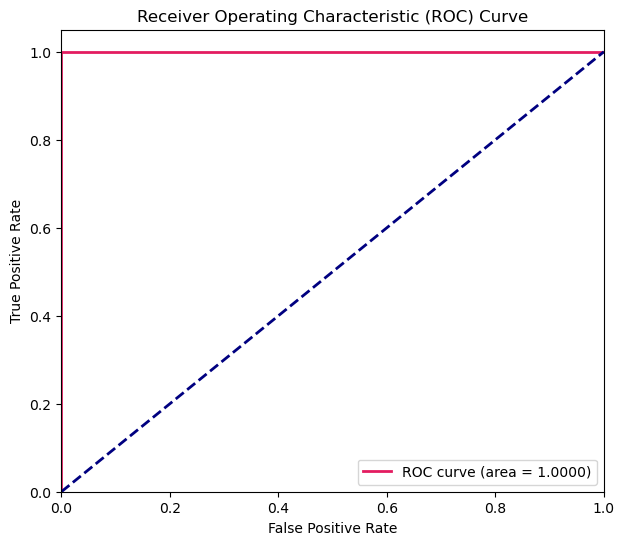

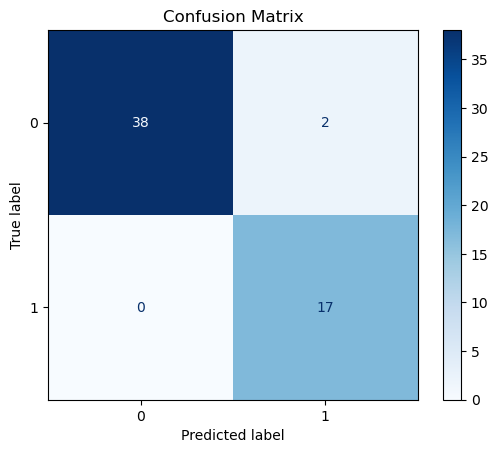



Fold 1 Results - Accuracy: 0.9649, F1 Score: 0.9594, Precision: 0.9474, Recall: 0.9750, AUROC: 1.0000

Fold 2/10

Epoch [0/50], Loss: 40332.4414
Epoch [10/50], Loss: 37602.8047
Epoch [20/50], Loss: 34551.8477
Epoch [30/50], Loss: 31080.4668
Epoch [40/50], Loss: 27028.2832
Epoch 0, Train Loss: 83.7225, Train Accuracy: 0.6367, Test Loss: 441.2583
Epoch 10, Train Loss: 33.0348, Train Accuracy: 0.7676, Test Loss: 58.4185
Epoch 20, Train Loss: 15.4230, Train Accuracy: 0.8652, Test Loss: 8.8849
Epoch 30, Train Loss: 8.0468, Train Accuracy: 0.8945, Test Loss: 5.5992
Epoch 40, Train Loss: 2.9782, Train Accuracy: 0.9082, Test Loss: 1.6205
Epoch 50, Train Loss: 2.2981, Train Accuracy: 0.9023, Test Loss: 1.0443
Epoch 60, Train Loss: 1.2464, Train Accuracy: 0.8828, Test Loss: 1.6930
Epoch 70, Train Loss: 1.1917, Train Accuracy: 0.8809, Test Loss: 1.5288
Epoch 80, Train Loss: 0.6466, Train Accuracy: 0.9199, Test Loss: 0.4512
Epoch 90, Train Loss: 0.8311, Train Accuracy: 0.8262, Test Loss: 0.3906


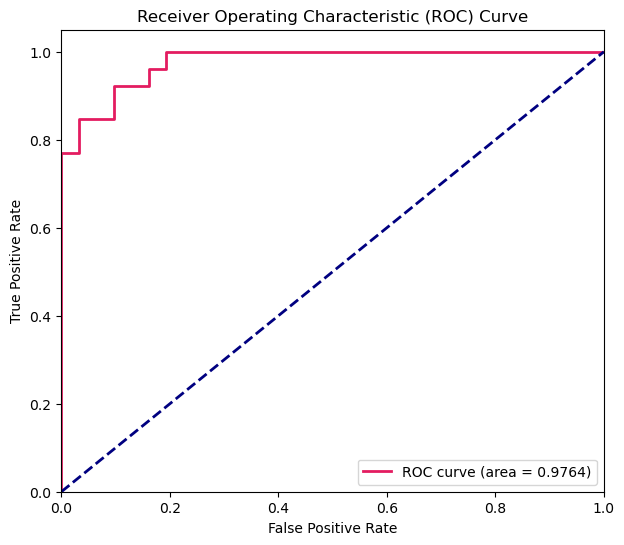

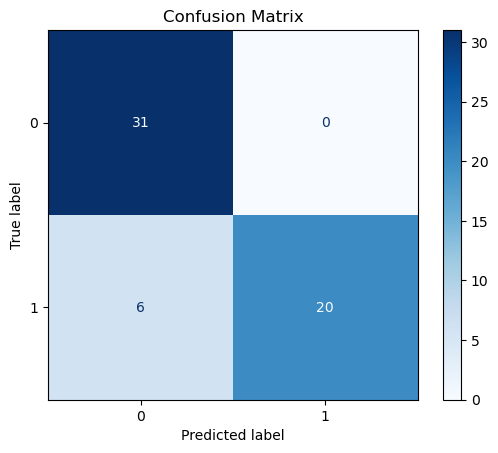



Fold 2 Results - Accuracy: 0.8947, F1 Score: 0.8907, Precision: 0.9189, Recall: 0.8846, AUROC: 0.9764

Fold 3/10

Epoch [0/50], Loss: 23323.8418
Epoch [10/50], Loss: 19458.3750
Epoch [20/50], Loss: 15984.1650
Epoch [30/50], Loss: 12936.4092
Epoch [40/50], Loss: 10335.7900
Epoch 0, Train Loss: 97.7138, Train Accuracy: 0.3750, Test Loss: 595.0721
Epoch 10, Train Loss: 28.5295, Train Accuracy: 0.4355, Test Loss: 75.9350
Epoch 20, Train Loss: 15.9151, Train Accuracy: 0.8574, Test Loss: 7.6336
Epoch 30, Train Loss: 5.3660, Train Accuracy: 0.8887, Test Loss: 3.3119
Epoch 40, Train Loss: 2.6520, Train Accuracy: 0.8672, Test Loss: 2.7330
Epoch 50, Train Loss: 1.8300, Train Accuracy: 0.8770, Test Loss: 1.2553
Epoch 60, Train Loss: 1.3715, Train Accuracy: 0.9004, Test Loss: 1.3224
Epoch 70, Train Loss: 1.2324, Train Accuracy: 0.8906, Test Loss: 0.8799
Epoch 80, Train Loss: 0.9040, Train Accuracy: 0.9102, Test Loss: 0.5528
Epoch 90, Train Loss: 0.9375, Train Accuracy: 0.8945, Test Loss: 0.3944


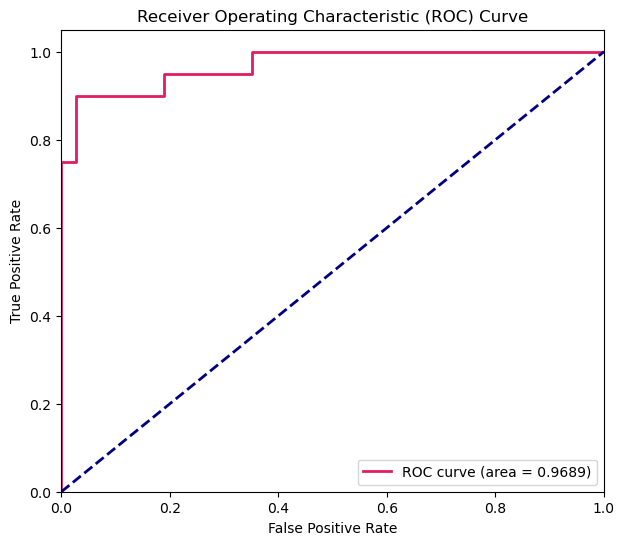

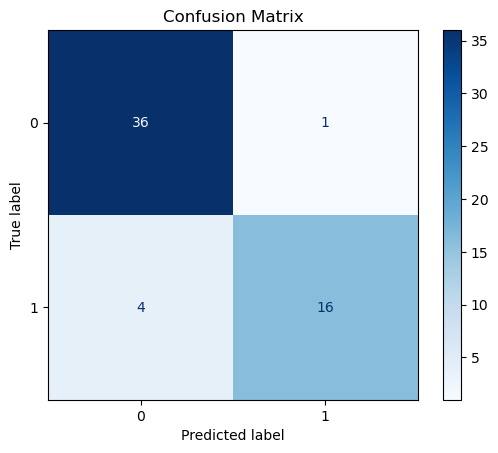



Fold 3 Results - Accuracy: 0.9123, F1 Score: 0.9000, Precision: 0.9206, Recall: 0.8865, AUROC: 0.9689

Fold 4/10

Epoch [0/50], Loss: 8222.1328
Epoch [10/50], Loss: 6504.6694
Epoch [20/50], Loss: 5196.9790
Epoch [30/50], Loss: 4244.5498
Epoch [40/50], Loss: 3575.1873
Epoch 0, Train Loss: 73.2279, Train Accuracy: 0.6191, Test Loss: 461.9712
Epoch 10, Train Loss: 74.2383, Train Accuracy: 0.7285, Test Loss: 42.3803
Epoch 20, Train Loss: 14.6500, Train Accuracy: 0.8711, Test Loss: 9.1766
Epoch 30, Train Loss: 5.6597, Train Accuracy: 0.8770, Test Loss: 1.9526
Epoch 40, Train Loss: 3.1801, Train Accuracy: 0.9004, Test Loss: 0.4311
Epoch 50, Train Loss: 1.4685, Train Accuracy: 0.9023, Test Loss: 0.5387
Epoch 60, Train Loss: 0.9117, Train Accuracy: 0.9043, Test Loss: 0.4286
Epoch 70, Train Loss: 0.7089, Train Accuracy: 0.9102, Test Loss: 0.1475
Epoch 80, Train Loss: 0.6194, Train Accuracy: 0.8984, Test Loss: 0.3198
Epoch 90, Train Loss: 0.4965, Train Accuracy: 0.9160, Test Loss: 0.1332
Epoch

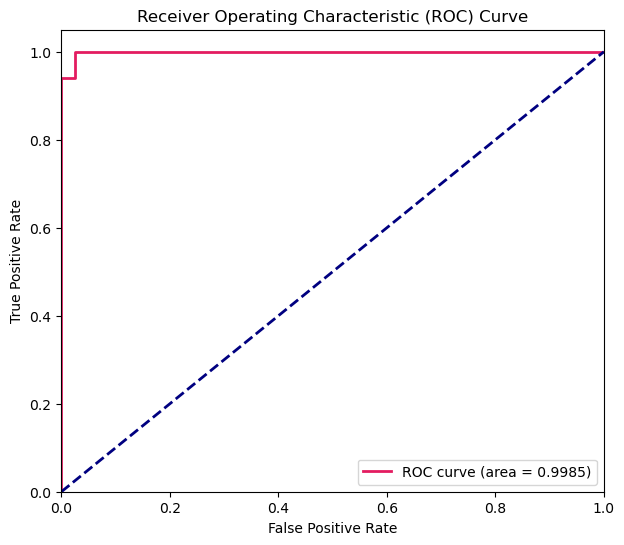

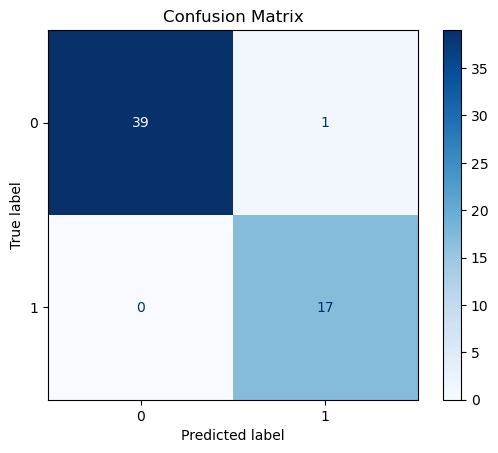



Fold 4 Results - Accuracy: 0.9825, F1 Score: 0.9794, Precision: 0.9722, Recall: 0.9875, AUROC: 0.9985

Fold 5/10

Epoch [0/50], Loss: 3205.1619
Epoch [10/50], Loss: 2881.4175
Epoch [20/50], Loss: 2653.0444
Epoch [30/50], Loss: 2487.6042
Epoch [40/50], Loss: 2363.5579
Epoch 0, Train Loss: 161.9013, Train Accuracy: 0.3789, Test Loss: 792.3828
Epoch 10, Train Loss: 78.3474, Train Accuracy: 0.5156, Test Loss: 141.6087
Epoch 20, Train Loss: 15.2788, Train Accuracy: 0.8145, Test Loss: 30.3600
Epoch 30, Train Loss: 6.6170, Train Accuracy: 0.9082, Test Loss: 7.9116
Epoch 40, Train Loss: 3.9861, Train Accuracy: 0.9238, Test Loss: 3.6171
Epoch 50, Train Loss: 2.4326, Train Accuracy: 0.9141, Test Loss: 2.7242
Epoch 60, Train Loss: 1.9138, Train Accuracy: 0.9238, Test Loss: 2.2550
Epoch 70, Train Loss: 2.3931, Train Accuracy: 0.9258, Test Loss: 1.6345
Epoch 80, Train Loss: 0.9657, Train Accuracy: 0.8438, Test Loss: 2.3415
Epoch 90, Train Loss: 0.8826, Train Accuracy: 0.8984, Test Loss: 2.2009
Ep

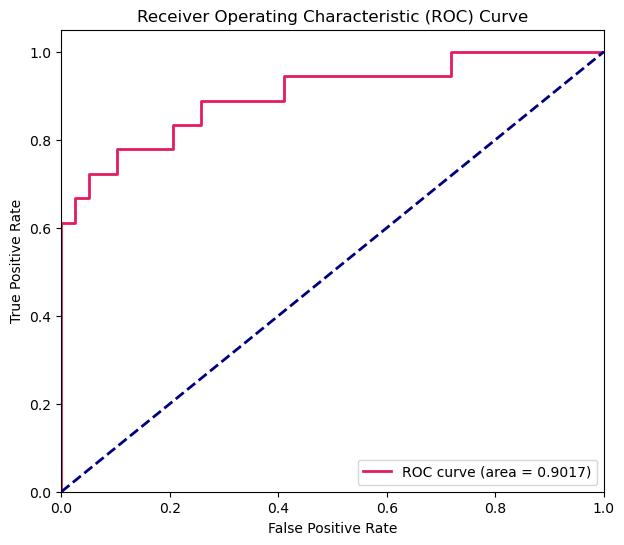

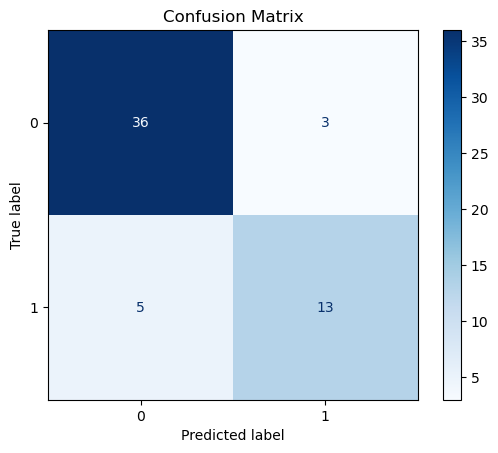



Fold 5 Results - Accuracy: 0.8596, F1 Score: 0.8324, Precision: 0.8453, Recall: 0.8226, AUROC: 0.9017

Fold 6/10

Epoch [0/50], Loss: 2322.6672
Epoch [10/50], Loss: 2247.8245
Epoch [20/50], Loss: 2184.9458
Epoch [30/50], Loss: 2130.0840
Epoch [40/50], Loss: 2080.7820
Epoch 0, Train Loss: 76.1828, Train Accuracy: 0.6348, Test Loss: 792.8242
Epoch 10, Train Loss: 79.9907, Train Accuracy: 0.7949, Test Loss: 67.6792
Epoch 20, Train Loss: 15.5756, Train Accuracy: 0.8672, Test Loss: 13.7765
Epoch 30, Train Loss: 5.0966, Train Accuracy: 0.8809, Test Loss: 2.8279
Epoch 40, Train Loss: 2.6007, Train Accuracy: 0.9062, Test Loss: 1.7392
Epoch 50, Train Loss: 1.7338, Train Accuracy: 0.9121, Test Loss: 1.1527
Epoch 60, Train Loss: 1.1071, Train Accuracy: 0.8887, Test Loss: 0.5604
Epoch 70, Train Loss: 1.2828, Train Accuracy: 0.8828, Test Loss: 1.1827
Epoch 80, Train Loss: 0.5617, Train Accuracy: 0.9199, Test Loss: 0.4120
Epoch 90, Train Loss: 0.4845, Train Accuracy: 0.9258, Test Loss: 0.3038
Epoc

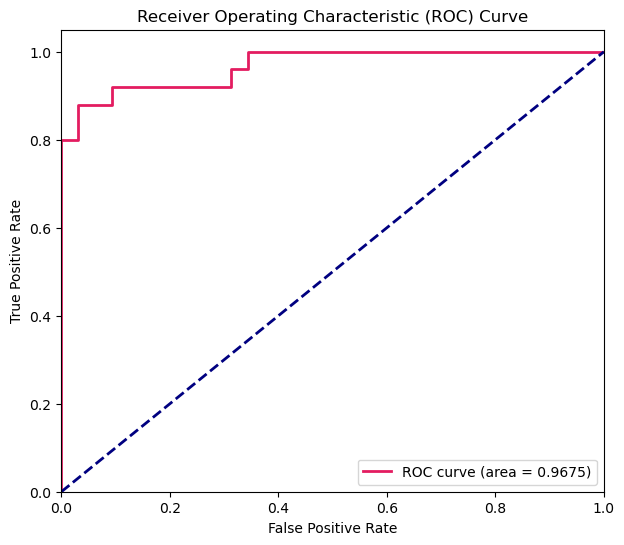

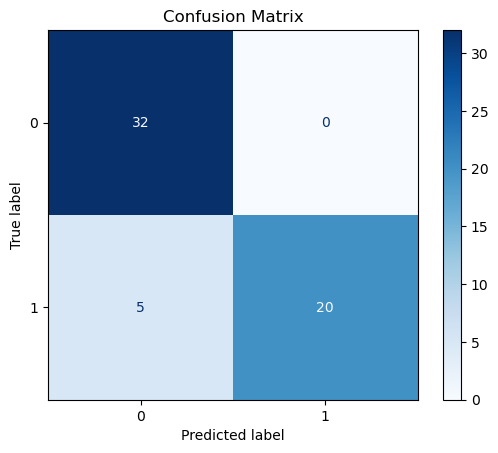



Fold 6 Results - Accuracy: 0.9123, F1 Score: 0.9082, Precision: 0.9324, Recall: 0.9000, AUROC: 0.9675

Fold 7/10

Epoch [0/50], Loss: 1989.2341
Epoch [10/50], Loss: 1946.6873
Epoch [20/50], Loss: 1906.2847
Epoch [30/50], Loss: 1867.2692
Epoch [40/50], Loss: 1829.0085
Epoch 0, Train Loss: 48.3491, Train Accuracy: 0.3809, Test Loss: 907.0844
Epoch 10, Train Loss: 53.4455, Train Accuracy: 0.7539, Test Loss: 24.2201
Epoch 20, Train Loss: 12.7067, Train Accuracy: 0.7949, Test Loss: 8.0958
Epoch 30, Train Loss: 3.2247, Train Accuracy: 0.8711, Test Loss: 1.1501
Epoch 40, Train Loss: 1.7845, Train Accuracy: 0.9004, Test Loss: 0.3738
Epoch 50, Train Loss: 0.9360, Train Accuracy: 0.8926, Test Loss: 0.2136
Epoch 60, Train Loss: 0.5529, Train Accuracy: 0.9082, Test Loss: 0.0994
Epoch 70, Train Loss: 0.3787, Train Accuracy: 0.9062, Test Loss: 0.1280
Epoch 80, Train Loss: 0.3279, Train Accuracy: 0.9004, Test Loss: 0.1299
Epoch 90, Train Loss: 0.2841, Train Accuracy: 0.9102, Test Loss: 0.1205
Epoch

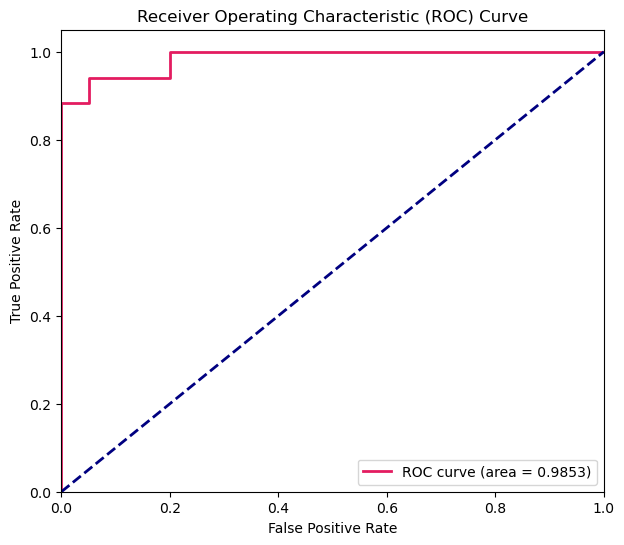

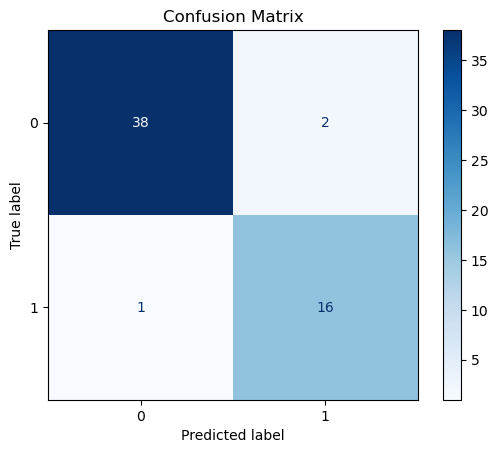



Fold 7 Results - Accuracy: 0.9474, F1 Score: 0.9382, Precision: 0.9316, Recall: 0.9456, AUROC: 0.9853

Fold 8/10

Epoch [0/50], Loss: 1761.6848
Epoch [10/50], Loss: 1724.3722
Epoch [20/50], Loss: 1687.1924
Epoch [30/50], Loss: 1649.7894
Epoch [40/50], Loss: 1612.0015
Epoch 0, Train Loss: 119.8773, Train Accuracy: 0.3633, Test Loss: 672.8102
Epoch 10, Train Loss: 61.3394, Train Accuracy: 0.4590, Test Loss: 69.8688
Epoch 20, Train Loss: 23.7738, Train Accuracy: 0.8770, Test Loss: 16.8763
Epoch 30, Train Loss: 9.5711, Train Accuracy: 0.8984, Test Loss: 3.9699
Epoch 40, Train Loss: 3.2692, Train Accuracy: 0.9043, Test Loss: 1.4289
Epoch 50, Train Loss: 2.5298, Train Accuracy: 0.9141, Test Loss: 2.2766
Epoch 60, Train Loss: 1.4937, Train Accuracy: 0.9199, Test Loss: 1.5332
Epoch 70, Train Loss: 1.0797, Train Accuracy: 0.9238, Test Loss: 0.4052
Epoch 80, Train Loss: 0.9826, Train Accuracy: 0.9023, Test Loss: 1.2050
Epoch 90, Train Loss: 0.4593, Train Accuracy: 0.9238, Test Loss: 0.2472
Epo

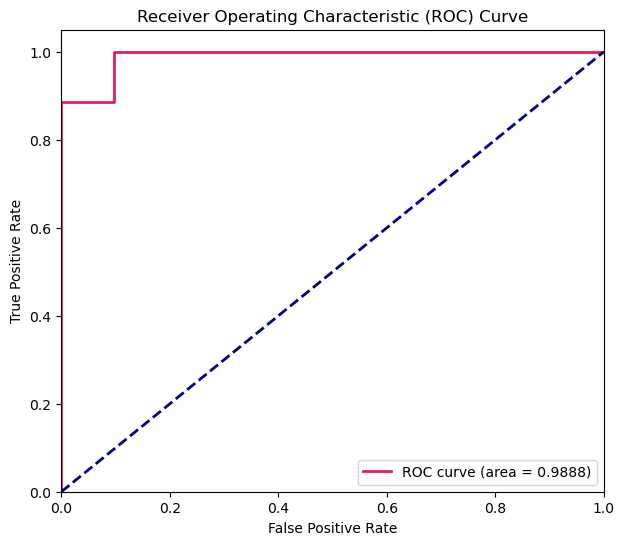

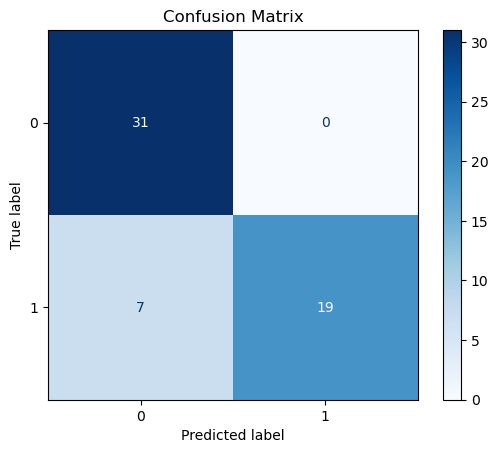



Fold 8 Results - Accuracy: 0.8772, F1 Score: 0.8715, Precision: 0.9079, Recall: 0.8654, AUROC: 0.9888

Fold 9/10

Epoch [0/50], Loss: 1594.9314
Epoch [10/50], Loss: 1555.9585
Epoch [20/50], Loss: 1516.5057
Epoch [30/50], Loss: 1476.6539
Epoch [40/50], Loss: 1436.4636
Epoch 0, Train Loss: 175.3964, Train Accuracy: 0.6387, Test Loss: 882.5532
Epoch 10, Train Loss: 60.0786, Train Accuracy: 0.7480, Test Loss: 144.8361
Epoch 20, Train Loss: 21.4704, Train Accuracy: 0.8906, Test Loss: 32.2527
Epoch 30, Train Loss: 9.9290, Train Accuracy: 0.8965, Test Loss: 17.1202
Epoch 40, Train Loss: 4.8502, Train Accuracy: 0.9004, Test Loss: 3.6744
Epoch 50, Train Loss: 2.3831, Train Accuracy: 0.9082, Test Loss: 2.3973
Epoch 60, Train Loss: 2.0793, Train Accuracy: 0.9141, Test Loss: 1.8757
Epoch 70, Train Loss: 1.3582, Train Accuracy: 0.8848, Test Loss: 0.6392
Epoch 80, Train Loss: 0.9553, Train Accuracy: 0.9141, Test Loss: 1.4453
Epoch 90, Train Loss: 0.7526, Train Accuracy: 0.9160, Test Loss: 1.3485
E

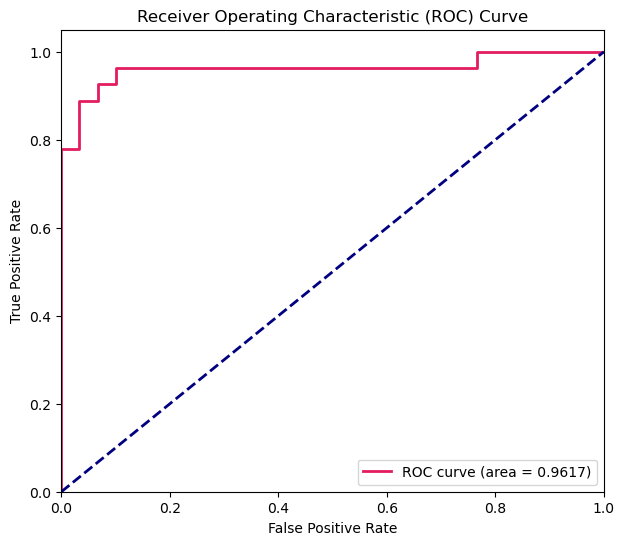

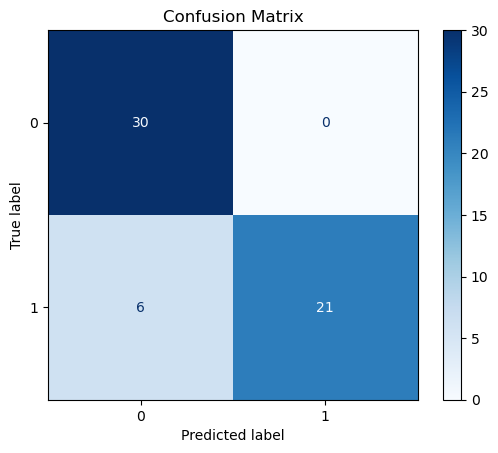



Fold 9 Results - Accuracy: 0.8947, F1 Score: 0.8920, Precision: 0.9167, Recall: 0.8889, AUROC: 0.9617

Fold 10/10

Epoch [0/50], Loss: 1405.7096
Epoch [10/50], Loss: 1364.2899
Epoch [20/50], Loss: 1322.5896
Epoch [30/50], Loss: 1280.8060
Epoch [40/50], Loss: 1239.0441
Epoch 0, Train Loss: 99.6991, Train Accuracy: 0.3762, Test Loss: 880.9810
Epoch 10, Train Loss: 62.3417, Train Accuracy: 0.5906, Test Loss: 97.9016
Epoch 20, Train Loss: 21.5709, Train Accuracy: 0.8947, Test Loss: 13.4121
Epoch 30, Train Loss: 6.9346, Train Accuracy: 0.8908, Test Loss: 5.7334
Epoch 40, Train Loss: 3.4838, Train Accuracy: 0.8947, Test Loss: 2.4442
Epoch 50, Train Loss: 2.8234, Train Accuracy: 0.8752, Test Loss: 1.0532
Epoch 60, Train Loss: 1.6347, Train Accuracy: 0.8889, Test Loss: 1.2087
Epoch 70, Train Loss: 1.0723, Train Accuracy: 0.8967, Test Loss: 0.8638
Epoch 80, Train Loss: 0.8528, Train Accuracy: 0.8402, Test Loss: 0.7531
Epoch 90, Train Loss: 0.6284, Train Accuracy: 0.8986, Test Loss: 0.5287
Epo

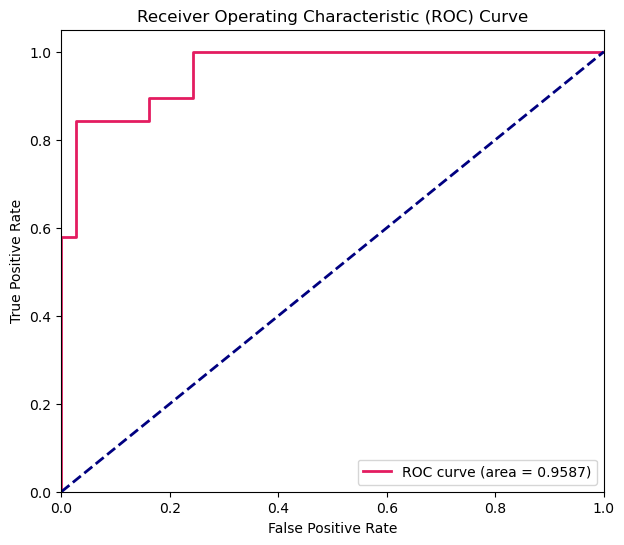

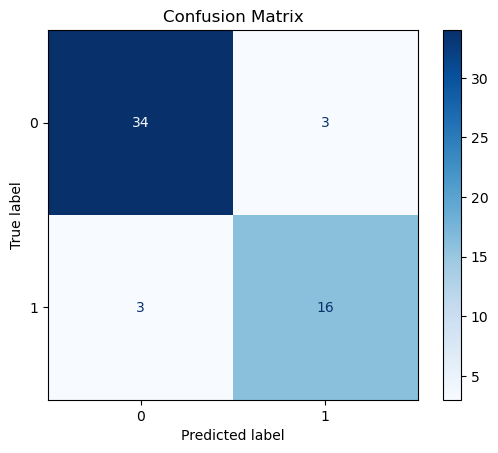



Fold 10 Results - Accuracy: 0.8929, F1 Score: 0.8805, Precision: 0.8805, Recall: 0.8805, AUROC: 0.9587

Average Results across 10 folds:
Accuracy: 0.9138, F1 Score: 0.9052, Precision: 0.9174, Recall: 0.9037, AUROC: 0.9708


In [ ]:
# Define a function to create KNN graph
def create_knn_graph(X, k):
    index = faiss.IndexFlatL2(X.shape[1])  # L2 distance
    X_contiguous = np.ascontiguousarray(X.astype(np.float32))  # Ensure array is contiguous
    index.add(X_contiguous)
    _, knn_graph = index.search(X_contiguous, k)

    G = nx.Graph()
    for i in range(X.shape[0]):
        for j in knn_graph[i]:
            G.add_edge(i, j)
    return from_networkx(G)

# Autoencoder parameters
input_dim = X.shape[1]  # Number of input features
hidden_dim = input_dim // 2  # Reduce dimension by half

# Instantiate autoencoder
autoencoder = Autoencoder(input_dim, hidden_dim).to(device)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Training function for autoencoder
def train_autoencoder(autoencoder, data, optimizer, epochs=50):
    criterion = nn.MSELoss()
    autoencoder.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        inputs = torch.tensor(data.values, dtype=torch.float).to(device)
        _, decoded = autoencoder(inputs)
        loss = criterion(decoded, inputs)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}')

# Set up K-Fold Cross Validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics across folds
accuracy_list = []
f1_list = []
precision_list = []
recall_list = []
auroc_list = []

# Training function modified for k-fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f'\nFold {fold + 1}/{k_folds}')

    # Split the data into train and test sets for this fold
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_fold.values, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test_fold.values, dtype=torch.float32).to(device)

    # Train the autoencoder
    for epoch in range(num_epochs):
        autoencoder.train()
        optimizer_ae.zero_grad()
        encoded, decoded = autoencoder(X_train_tensor)
        loss = criterion(decoded, X_train_tensor)
        loss.backward()
        optimizer_ae.step()

    # Encode the train and test sets using the trained autoencoder
    autoencoder.eval()
    with torch.no_grad():
        X_train_encoded, _ = autoencoder(X_train_tensor)
        X_test_encoded, _ = autoencoder(X_test_tensor)

    X_train_encoded = X_train_encoded.cpu().numpy()
    X_test_encoded = X_test_encoded.cpu().numpy()

    # Create KNN graphs for train and test sets (returning graph objects now)
    train_graph = create_knn_graph(X_train_encoded, k=15)
    test_graph = create_knn_graph(X_test_encoded, k=15)

    # Add labels to the graph
    train_graph.y = torch.tensor(y_train_fold.values, dtype=torch.long)
    test_graph.y = torch.tensor(y_test_fold.values, dtype=torch.long)

    # Train mask and test mask for current fold
    train_graph.train_mask = torch.ones(train_graph.num_nodes, dtype=torch.bool)
    test_graph.test_mask = torch.ones(test_graph.num_nodes, dtype=torch.bool)

    # Initialize a new model for each fold
    model = GraphSAGE(num_features=encoding_dim, hidden_channels=hidden_channels, num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Train the model for this fold
    for epoch in range(600):
        train_loss = train(model, train_graph, optimizer)
        if epoch % 10 == 0:
            train_acc = train_accuracy(model, train_graph)
            current_test_loss = test_loss(model, test_graph)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model on the test set for this fold
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, test_graph)

    # Store the metrics
    accuracy_list.append(test_acc)
    f1_list.append(test_f1)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    auroc_list.append(auroc)

    print(f"Fold {fold + 1} Results - Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}")

# Calculate and print the average results across all folds
avg_accuracy = np.mean(accuracy_list)
avg_f1 = np.mean(f1_list)
avg_precision = np.mean(precision_list)
avg_recall = np.mean(recall_list)
avg_auroc = np.mean(auroc_list)

print("\nAverage Results across 10 folds:")
print(f"Accuracy: {avg_accuracy:.4f}, F1 Score: {avg_f1:.4f}, Precision: {avg_precision:.4f}, Recall: {avg_recall:.4f}, AUROC: {avg_auroc:.4f}")


### Inductive Setting

##### GCN


Fold 1/10

Epoch 0, Train Loss: 0.6917, Train Accuracy: 0.6191, Test Loss: 0.6759
Epoch 10, Train Loss: 0.6159, Train Accuracy: 0.6797, Test Loss: 0.6051
Epoch 20, Train Loss: 0.5962, Train Accuracy: 0.6855, Test Loss: 0.5891
Epoch 30, Train Loss: 0.5845, Train Accuracy: 0.6953, Test Loss: 0.5867
Epoch 40, Train Loss: 0.5771, Train Accuracy: 0.6855, Test Loss: 0.5812
Epoch 50, Train Loss: 0.5719, Train Accuracy: 0.6875, Test Loss: 0.5833
Epoch 60, Train Loss: 0.5671, Train Accuracy: 0.6895, Test Loss: 0.5943
Epoch 70, Train Loss: 0.5623, Train Accuracy: 0.6895, Test Loss: 0.5943
Epoch 80, Train Loss: 0.5611, Train Accuracy: 0.6992, Test Loss: 0.5973
Epoch 90, Train Loss: 0.5578, Train Accuracy: 0.6914, Test Loss: 0.6020
Epoch 100, Train Loss: 0.5552, Train Accuracy: 0.7012, Test Loss: 0.6041
Epoch 110, Train Loss: 0.5542, Train Accuracy: 0.7031, Test Loss: 0.6110
Epoch 120, Train Loss: 0.5520, Train Accuracy: 0.7012, Test Loss: 0.6071
Epoch 130, Train Loss: 0.5496, Train Accuracy: 0.7

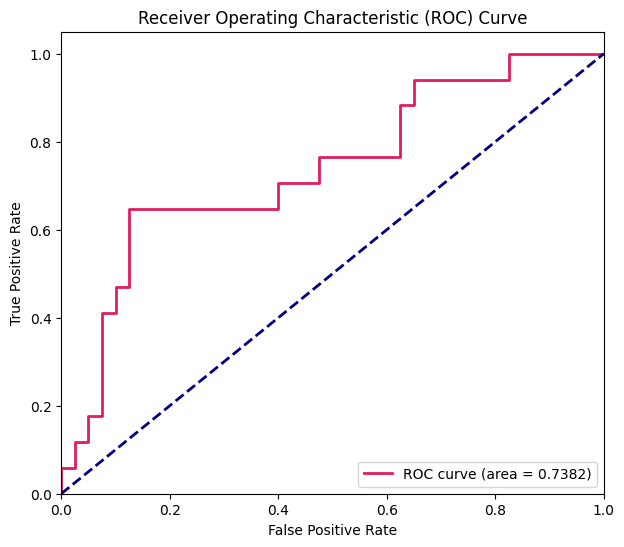

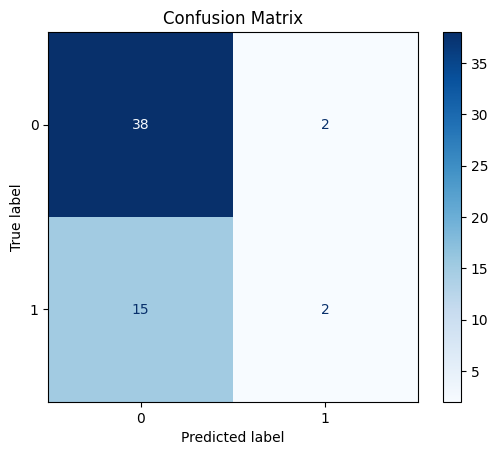



Fold 1 Results - Accuracy: 0.7018, F1 Score: 0.5038, Precision: 0.6085, Recall: 0.5338, AUROC: 0.7382

Fold 2/10

Epoch 0, Train Loss: 0.7027, Train Accuracy: 0.6094, Test Loss: 0.7085
Epoch 10, Train Loss: 0.5986, Train Accuracy: 0.6875, Test Loss: 0.6605
Epoch 20, Train Loss: 0.5766, Train Accuracy: 0.7090, Test Loss: 0.6587
Epoch 30, Train Loss: 0.5664, Train Accuracy: 0.7148, Test Loss: 0.6893
Epoch 40, Train Loss: 0.5594, Train Accuracy: 0.7285, Test Loss: 0.7217
Epoch 50, Train Loss: 0.5546, Train Accuracy: 0.7285, Test Loss: 0.7436
Epoch 60, Train Loss: 0.5498, Train Accuracy: 0.7305, Test Loss: 0.7697
Epoch 70, Train Loss: 0.5462, Train Accuracy: 0.7344, Test Loss: 0.7749
Epoch 80, Train Loss: 0.5428, Train Accuracy: 0.7324, Test Loss: 0.8003
Epoch 90, Train Loss: 0.5415, Train Accuracy: 0.7324, Test Loss: 0.8335
Epoch 100, Train Loss: 0.5387, Train Accuracy: 0.7383, Test Loss: 0.8523
Epoch 110, Train Loss: 0.5354, Train Accuracy: 0.7402, Test Loss: 0.8717
Epoch 120, Train Lo

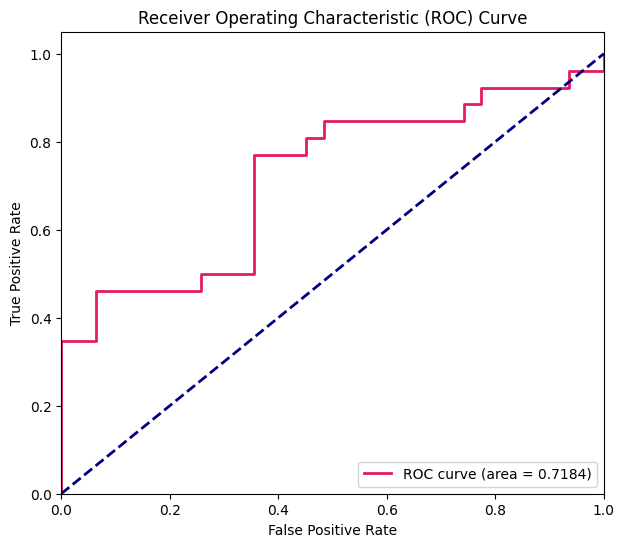

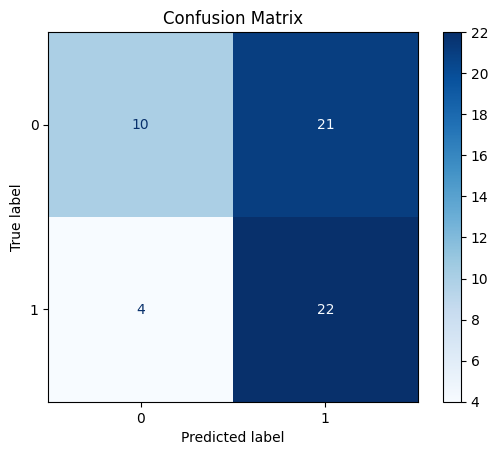



Fold 2 Results - Accuracy: 0.5614, F1 Score: 0.5411, Precision: 0.6130, Recall: 0.5844, AUROC: 0.7184

Fold 3/10

Epoch 0, Train Loss: 0.7065, Train Accuracy: 0.5508, Test Loss: 0.6879
Epoch 10, Train Loss: 0.6112, Train Accuracy: 0.6914, Test Loss: 0.6116
Epoch 20, Train Loss: 0.5784, Train Accuracy: 0.6914, Test Loss: 0.5892
Epoch 30, Train Loss: 0.5696, Train Accuracy: 0.7051, Test Loss: 0.5932
Epoch 40, Train Loss: 0.5638, Train Accuracy: 0.7090, Test Loss: 0.5873
Epoch 50, Train Loss: 0.5617, Train Accuracy: 0.7168, Test Loss: 0.5812
Epoch 60, Train Loss: 0.5588, Train Accuracy: 0.7109, Test Loss: 0.5811
Epoch 70, Train Loss: 0.5546, Train Accuracy: 0.7070, Test Loss: 0.5827
Epoch 80, Train Loss: 0.5538, Train Accuracy: 0.7109, Test Loss: 0.5825
Epoch 90, Train Loss: 0.5501, Train Accuracy: 0.7129, Test Loss: 0.5816
Epoch 100, Train Loss: 0.5484, Train Accuracy: 0.7129, Test Loss: 0.5832
Epoch 110, Train Loss: 0.5474, Train Accuracy: 0.7168, Test Loss: 0.5833
Epoch 120, Train Lo

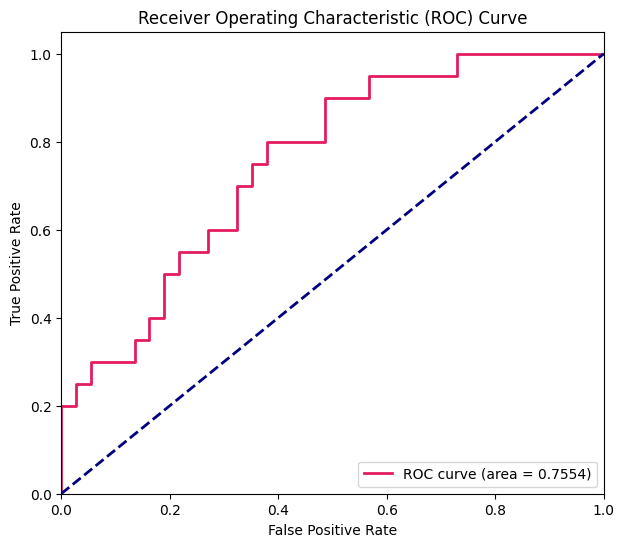

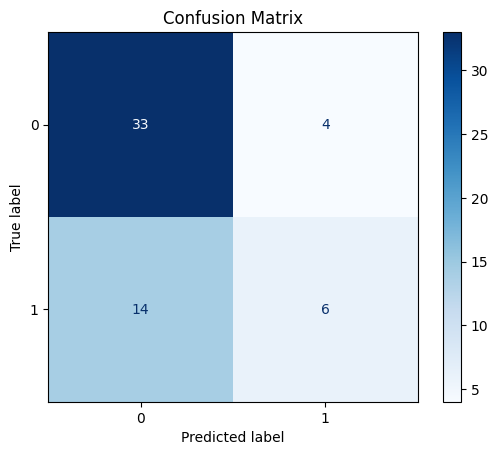



Fold 3 Results - Accuracy: 0.6842, F1 Score: 0.5929, Precision: 0.6511, Recall: 0.5959, AUROC: 0.7554

Fold 4/10

Epoch 0, Train Loss: 0.7003, Train Accuracy: 0.6230, Test Loss: 0.6746
Epoch 10, Train Loss: 0.6124, Train Accuracy: 0.6758, Test Loss: 0.5482
Epoch 20, Train Loss: 0.5971, Train Accuracy: 0.6719, Test Loss: 0.5597
Epoch 30, Train Loss: 0.5891, Train Accuracy: 0.6895, Test Loss: 0.5680
Epoch 40, Train Loss: 0.5879, Train Accuracy: 0.6855, Test Loss: 0.5643
Epoch 50, Train Loss: 0.5863, Train Accuracy: 0.6934, Test Loss: 0.5666
Epoch 60, Train Loss: 0.5843, Train Accuracy: 0.6973, Test Loss: 0.5728
Epoch 70, Train Loss: 0.5825, Train Accuracy: 0.7031, Test Loss: 0.5753
Epoch 80, Train Loss: 0.5810, Train Accuracy: 0.7070, Test Loss: 0.5705
Epoch 90, Train Loss: 0.5806, Train Accuracy: 0.7109, Test Loss: 0.5728
Epoch 100, Train Loss: 0.5781, Train Accuracy: 0.7090, Test Loss: 0.5741
Epoch 110, Train Loss: 0.5767, Train Accuracy: 0.7109, Test Loss: 0.5753
Epoch 120, Train Lo

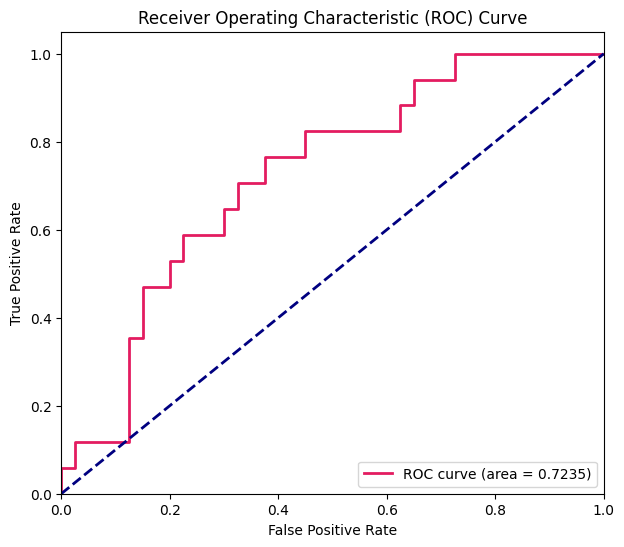

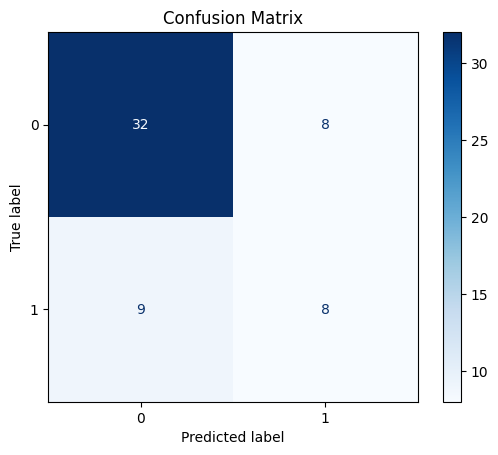



Fold 4 Results - Accuracy: 0.7018, F1 Score: 0.6375, Precision: 0.6402, Recall: 0.6353, AUROC: 0.7235

Fold 5/10

Epoch 0, Train Loss: 0.6899, Train Accuracy: 0.6152, Test Loss: 0.6579
Epoch 10, Train Loss: 0.6082, Train Accuracy: 0.6738, Test Loss: 0.5847
Epoch 20, Train Loss: 0.5964, Train Accuracy: 0.6836, Test Loss: 0.5851
Epoch 30, Train Loss: 0.5891, Train Accuracy: 0.6953, Test Loss: 0.5882
Epoch 40, Train Loss: 0.5873, Train Accuracy: 0.6953, Test Loss: 0.5875
Epoch 50, Train Loss: 0.5829, Train Accuracy: 0.7012, Test Loss: 0.5883
Epoch 60, Train Loss: 0.5800, Train Accuracy: 0.7051, Test Loss: 0.5882
Epoch 70, Train Loss: 0.5778, Train Accuracy: 0.7070, Test Loss: 0.5880
Epoch 80, Train Loss: 0.5754, Train Accuracy: 0.7051, Test Loss: 0.5859
Epoch 90, Train Loss: 0.5710, Train Accuracy: 0.7070, Test Loss: 0.5849
Epoch 100, Train Loss: 0.5681, Train Accuracy: 0.7148, Test Loss: 0.5841
Epoch 110, Train Loss: 0.5649, Train Accuracy: 0.7109, Test Loss: 0.5806
Epoch 120, Train Lo

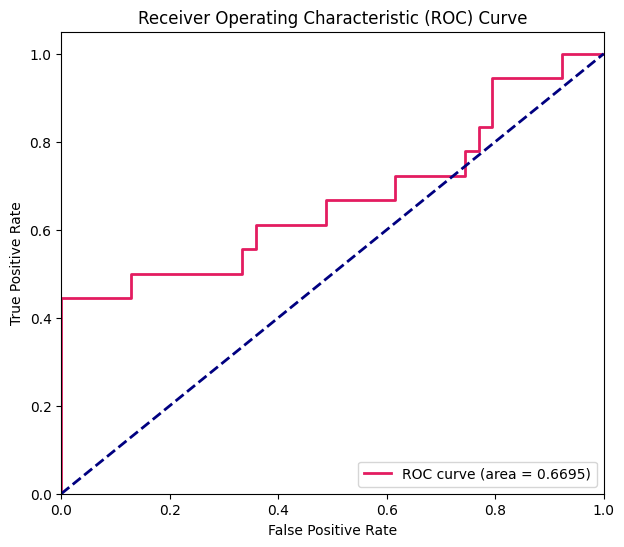

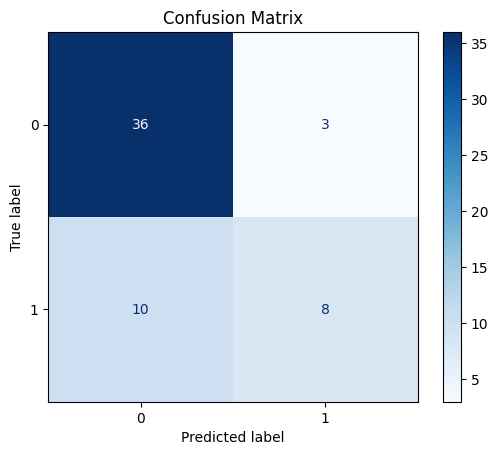



Fold 5 Results - Accuracy: 0.7719, F1 Score: 0.6994, Precision: 0.7549, Recall: 0.6838, AUROC: 0.6695

Fold 6/10

Epoch 0, Train Loss: 0.7128, Train Accuracy: 0.3750, Test Loss: 0.6864
Epoch 10, Train Loss: 0.6084, Train Accuracy: 0.6738, Test Loss: 0.6422
Epoch 20, Train Loss: 0.5812, Train Accuracy: 0.7012, Test Loss: 0.6366
Epoch 30, Train Loss: 0.5697, Train Accuracy: 0.7109, Test Loss: 0.6780
Epoch 40, Train Loss: 0.5578, Train Accuracy: 0.7031, Test Loss: 0.7458
Epoch 50, Train Loss: 0.5554, Train Accuracy: 0.7012, Test Loss: 0.7954
Epoch 60, Train Loss: 0.5514, Train Accuracy: 0.7012, Test Loss: 0.8198
Epoch 70, Train Loss: 0.5497, Train Accuracy: 0.7051, Test Loss: 0.8276
Epoch 80, Train Loss: 0.5470, Train Accuracy: 0.7012, Test Loss: 0.8254
Epoch 90, Train Loss: 0.5456, Train Accuracy: 0.7070, Test Loss: 0.8228
Epoch 100, Train Loss: 0.5440, Train Accuracy: 0.7090, Test Loss: 0.8311
Epoch 110, Train Loss: 0.5436, Train Accuracy: 0.7012, Test Loss: 0.8326
Epoch 120, Train Lo

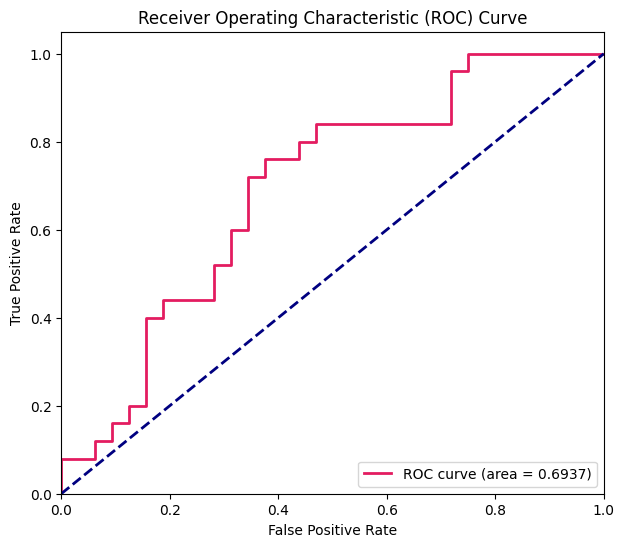

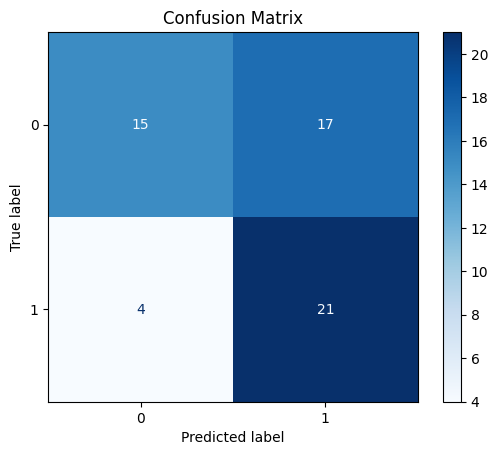



Fold 6 Results - Accuracy: 0.6316, F1 Score: 0.6275, Precision: 0.6711, Recall: 0.6544, AUROC: 0.6938

Fold 7/10

Epoch 0, Train Loss: 0.6845, Train Accuracy: 0.6191, Test Loss: 0.6556
Epoch 10, Train Loss: 0.6121, Train Accuracy: 0.7051, Test Loss: 0.5751
Epoch 20, Train Loss: 0.5898, Train Accuracy: 0.7090, Test Loss: 0.5807
Epoch 30, Train Loss: 0.5765, Train Accuracy: 0.7207, Test Loss: 0.5841
Epoch 40, Train Loss: 0.5688, Train Accuracy: 0.7344, Test Loss: 0.5829
Epoch 50, Train Loss: 0.5654, Train Accuracy: 0.7285, Test Loss: 0.5878
Epoch 60, Train Loss: 0.5634, Train Accuracy: 0.7227, Test Loss: 0.5968
Epoch 70, Train Loss: 0.5603, Train Accuracy: 0.7285, Test Loss: 0.5978
Epoch 80, Train Loss: 0.5591, Train Accuracy: 0.7344, Test Loss: 0.5974
Epoch 90, Train Loss: 0.5588, Train Accuracy: 0.7266, Test Loss: 0.6015
Epoch 100, Train Loss: 0.5544, Train Accuracy: 0.7344, Test Loss: 0.6027
Epoch 110, Train Loss: 0.5511, Train Accuracy: 0.7344, Test Loss: 0.6084
Epoch 120, Train Lo

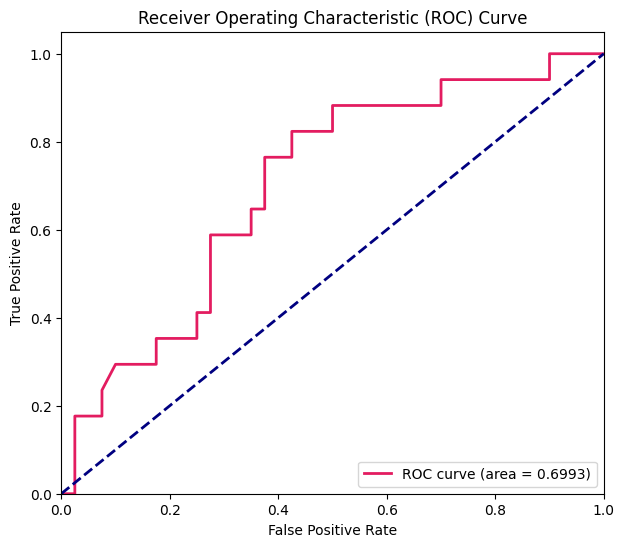

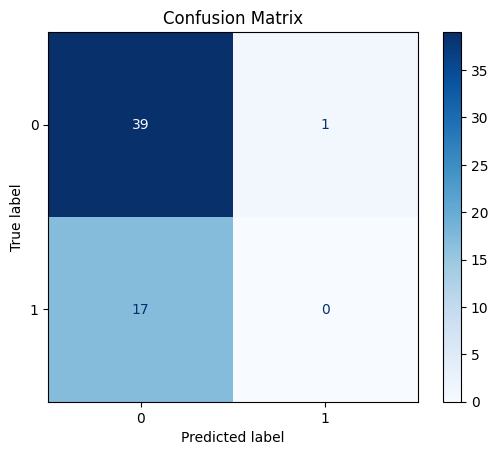



Fold 7 Results - Accuracy: 0.6842, F1 Score: 0.4062, Precision: 0.3482, Recall: 0.4875, AUROC: 0.6993

Fold 8/10

Epoch 0, Train Loss: 0.6879, Train Accuracy: 0.7090, Test Loss: 0.6819
Epoch 10, Train Loss: 0.5802, Train Accuracy: 0.6992, Test Loss: 0.6426
Epoch 20, Train Loss: 0.5621, Train Accuracy: 0.7109, Test Loss: 0.6250
Epoch 30, Train Loss: 0.5566, Train Accuracy: 0.7129, Test Loss: 0.6200
Epoch 40, Train Loss: 0.5500, Train Accuracy: 0.7070, Test Loss: 0.6189
Epoch 50, Train Loss: 0.5478, Train Accuracy: 0.7148, Test Loss: 0.6192
Epoch 60, Train Loss: 0.5445, Train Accuracy: 0.7227, Test Loss: 0.6174
Epoch 70, Train Loss: 0.5416, Train Accuracy: 0.7207, Test Loss: 0.6193
Epoch 80, Train Loss: 0.5371, Train Accuracy: 0.7305, Test Loss: 0.6226
Epoch 90, Train Loss: 0.5362, Train Accuracy: 0.7344, Test Loss: 0.6234
Epoch 100, Train Loss: 0.5323, Train Accuracy: 0.7344, Test Loss: 0.6266
Epoch 110, Train Loss: 0.5309, Train Accuracy: 0.7344, Test Loss: 0.6321
Epoch 120, Train Lo

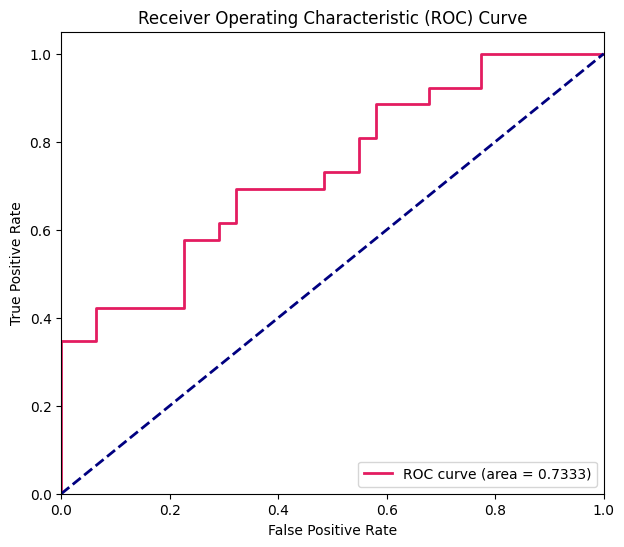

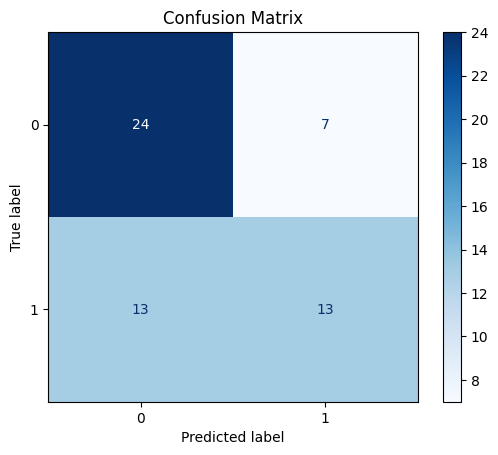



Fold 8 Results - Accuracy: 0.6491, F1 Score: 0.6355, Precision: 0.6493, Recall: 0.6371, AUROC: 0.7333

Fold 9/10

Epoch 0, Train Loss: 0.6981, Train Accuracy: 0.5801, Test Loss: 0.6870
Epoch 10, Train Loss: 0.6133, Train Accuracy: 0.6836, Test Loss: 0.6119
Epoch 20, Train Loss: 0.5883, Train Accuracy: 0.6992, Test Loss: 0.5968
Epoch 30, Train Loss: 0.5750, Train Accuracy: 0.7129, Test Loss: 0.6208
Epoch 40, Train Loss: 0.5665, Train Accuracy: 0.7227, Test Loss: 0.6535
Epoch 50, Train Loss: 0.5631, Train Accuracy: 0.7188, Test Loss: 0.6780
Epoch 60, Train Loss: 0.5575, Train Accuracy: 0.7266, Test Loss: 0.6804
Epoch 70, Train Loss: 0.5594, Train Accuracy: 0.7285, Test Loss: 0.6773
Epoch 80, Train Loss: 0.5566, Train Accuracy: 0.7344, Test Loss: 0.6714
Epoch 90, Train Loss: 0.5563, Train Accuracy: 0.7363, Test Loss: 0.6595
Epoch 100, Train Loss: 0.5551, Train Accuracy: 0.7363, Test Loss: 0.6593
Epoch 110, Train Loss: 0.5527, Train Accuracy: 0.7363, Test Loss: 0.6507
Epoch 120, Train Lo

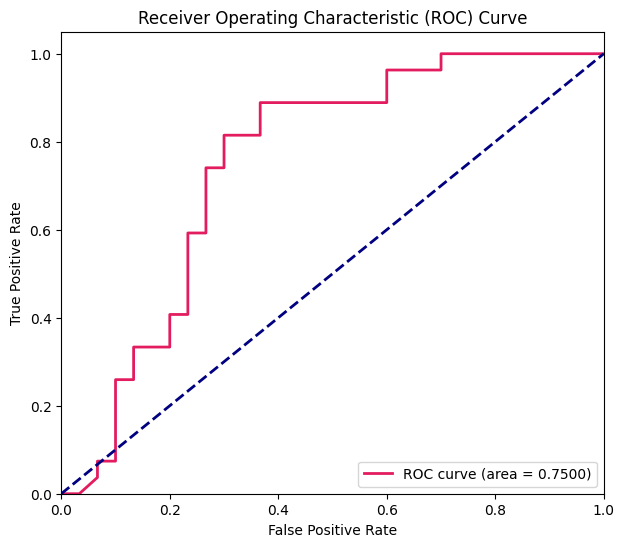

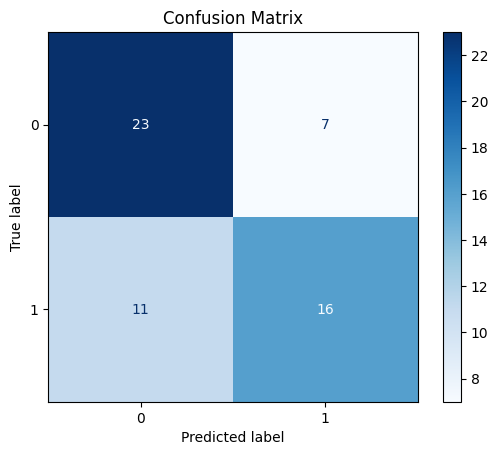



Fold 9 Results - Accuracy: 0.6842, F1 Score: 0.6794, Precision: 0.6861, Recall: 0.6796, AUROC: 0.7500

Fold 10/10

Epoch 0, Train Loss: 0.6885, Train Accuracy: 0.6940, Test Loss: 0.6884
Epoch 10, Train Loss: 0.5993, Train Accuracy: 0.6901, Test Loss: 0.6302
Epoch 20, Train Loss: 0.5698, Train Accuracy: 0.6901, Test Loss: 0.6786
Epoch 30, Train Loss: 0.5673, Train Accuracy: 0.6901, Test Loss: 0.7033
Epoch 40, Train Loss: 0.5608, Train Accuracy: 0.6901, Test Loss: 0.6696
Epoch 50, Train Loss: 0.5598, Train Accuracy: 0.6940, Test Loss: 0.6485
Epoch 60, Train Loss: 0.5529, Train Accuracy: 0.6959, Test Loss: 0.6443
Epoch 70, Train Loss: 0.5556, Train Accuracy: 0.6998, Test Loss: 0.6442
Epoch 80, Train Loss: 0.5527, Train Accuracy: 0.6998, Test Loss: 0.6382
Epoch 90, Train Loss: 0.5476, Train Accuracy: 0.6979, Test Loss: 0.6330
Epoch 100, Train Loss: 0.5441, Train Accuracy: 0.7076, Test Loss: 0.6311
Epoch 110, Train Loss: 0.5424, Train Accuracy: 0.7096, Test Loss: 0.6320
Epoch 120, Train L

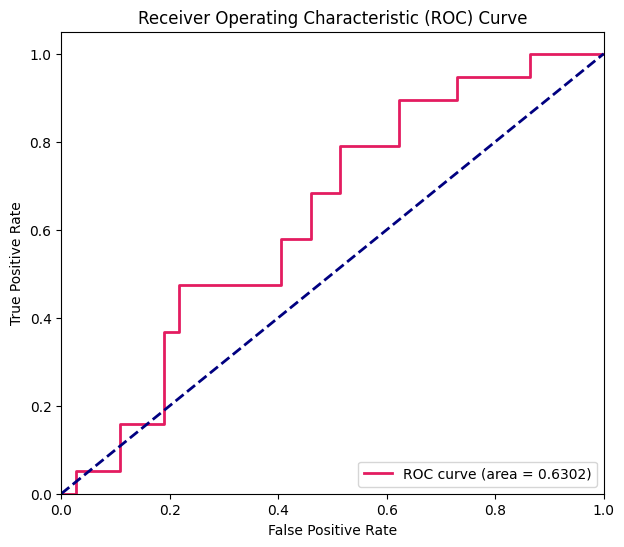

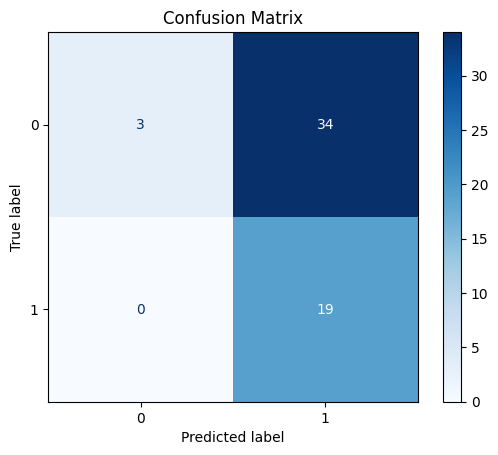



Fold 10 Results - Accuracy: 0.3929, F1 Score: 0.3389, Precision: 0.6792, Recall: 0.5405, AUROC: 0.6302

Average Results across 10 folds:
Accuracy: 0.6463, F1 Score: 0.5662, Precision: 0.6302, Recall: 0.6032, AUROC: 0.7111


In [ ]:
# Create KNN graph from the data
def create_knn_graph(X, k):
    index = faiss.IndexFlatL2(X.shape[1])  # L2 distance
    X_contiguous = np.ascontiguousarray(X.values.astype(np.float32))
    index.add(X_contiguous)
    _, knn_graph = index.search(X_contiguous, k)

    G = nx.Graph()
    for i in range(X.shape[0]):
        for j in knn_graph[i]:
            G.add_edge(i, j)
    return from_networkx(G)

# Define the GCN model
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.gcn_conv1 = GCNConv(num_features, hidden_channels)
        self.gcn_conv2 = GCNConv(hidden_channels, num_classes)
        self.init_weights()

    def init_weights(self):
        self.gcn_conv1.reset_parameters()
        self.gcn_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gcn_conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.gcn_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Training function
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.to(device))
    loss = F.nll_loss(out, data.y.to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

# Function to compute accuracy on the training data
def train_accuracy(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        correct = preds.eq(data.y.to(device)).sum().item()
        acc = correct / data.y.size(0)
    return acc

# Function to compute test loss
def test_loss(model, data):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        logits = model(data.to(device))
        loss = F.nll_loss(logits, data.y.to(device))  # Compute the loss for test data
    return loss.item()

# Evaluation function
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        y_true = data.y.to(device)
        y_pred = preds
        y_prob = logits[:, 1]  # Probability for the positive class

        test_acc = (y_pred == y_true).sum().item() / y_true.size(0)
        test_precision = FM.precision(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_recall = FM.recall(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_f1 = FM.f1_score(y_pred, y_true, average='macro', num_classes=2, task='multiclass')

        # Compute AUROC
        auroc = FM.auroc(y_prob, y_true, num_classes=2, task='binary')

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_true.cpu(), y_prob.cpu())
        roc_auc = auc(fpr, tpr)

        print('\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n')

        # Plot ROC curve
        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='#e31c60', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.show()

        print('\n')

        # Confusion Matrix
        cm = confusion_matrix(y_true.cpu(), y_pred.cpu())
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.show()

        print('\n')

    return test_acc, test_f1.item(), test_precision.item(), test_recall.item(), auroc.item()

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_channels = 320
num_classes = 2
optimizer_class = torch.optim.Adam

# Set up K-Fold Cross Validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics across folds
accuracy_list = []
f1_list = []
precision_list = []
recall_list = []
auroc_list = []

# Perform 10-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"\nFold {fold + 1}/{n_splits}\n")

    # Split into training and test sets for this fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalization (if needed)
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    # Create KNN graphs for training and test data
    k = 15
    train_graph = create_knn_graph(X_train, k)
    test_graph = create_knn_graph(X_test, k)

    # Convert features and labels for training and test data to tensors
    train_graph.x = torch.tensor(X_train.values, dtype=torch.float)
    train_graph.y = torch.tensor(y_train.values, dtype=torch.long)
    test_graph.x = torch.tensor(X_test.values, dtype=torch.float)
    test_graph.y = torch.tensor(y_test.values, dtype=torch.long)

    # Initialize model and optimizer for each fold
    # Choose either GCN or GAT model:

    # Uncomment to use GCN
    model = GCN(num_features=X_train.shape[1], hidden_channels=256, num_classes=num_classes).to(device)

    # Uncomment to use GAT
    # model = GAT(num_features=X_train.shape[1], hidden_channels=256, num_classes=num_classes, heads=8).to(device)

    optimizer = optimizer_class(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Train the model for this fold
    for epoch in range(600):
        train_loss = train(model, train_graph, optimizer)
        if epoch % 10 == 0:
            train_acc = train_accuracy(model, train_graph)
            current_test_loss = test_loss(model, test_graph)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model on the test set for this fold
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, test_graph)

    # Store the metrics
    accuracy_list.append(test_acc)
    f1_list.append(test_f1)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    auroc_list.append(auroc)

    print(f"Fold {fold + 1} Results - Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}")

# Calculate average metrics across all folds
avg_accuracy = np.mean(accuracy_list)
avg_f1 = np.mean(f1_list)
avg_precision = np.mean(precision_list)
avg_recall = np.mean(recall_list)
avg_auroc = np.mean(auroc_list)

print("\nAverage Results across 10 folds:")
print(f"Accuracy: {avg_accuracy:.4f}, F1 Score: {avg_f1:.4f}, Precision: {avg_precision:.4f}, Recall: {avg_recall:.4f}, AUROC: {avg_auroc:.4f}")


##### GAT


Fold 1/10

Epoch 0, Train Loss: 0.6866, Train Accuracy: 0.6699, Test Loss: 0.6283
Epoch 10, Train Loss: 0.5785, Train Accuracy: 0.6875, Test Loss: 0.5557
Epoch 20, Train Loss: 0.5301, Train Accuracy: 0.7344, Test Loss: 0.4795
Epoch 30, Train Loss: 0.4542, Train Accuracy: 0.8027, Test Loss: 0.4190
Epoch 40, Train Loss: 0.3687, Train Accuracy: 0.8691, Test Loss: 0.3602
Epoch 50, Train Loss: 0.2951, Train Accuracy: 0.9102, Test Loss: 0.3887
Epoch 60, Train Loss: 0.2467, Train Accuracy: 0.9355, Test Loss: 0.5974
Epoch 70, Train Loss: 0.1981, Train Accuracy: 0.9473, Test Loss: 0.5581
Epoch 80, Train Loss: 0.1619, Train Accuracy: 0.9648, Test Loss: 0.4573
Epoch 90, Train Loss: 0.1349, Train Accuracy: 0.9707, Test Loss: 0.3583
Epoch 100, Train Loss: 0.1185, Train Accuracy: 0.9766, Test Loss: 0.2947
Epoch 110, Train Loss: 0.1020, Train Accuracy: 0.9766, Test Loss: 0.3218
Epoch 120, Train Loss: 0.0890, Train Accuracy: 0.9785, Test Loss: 0.3061
Epoch 130, Train Loss: 0.0860, Train Accuracy: 0.9

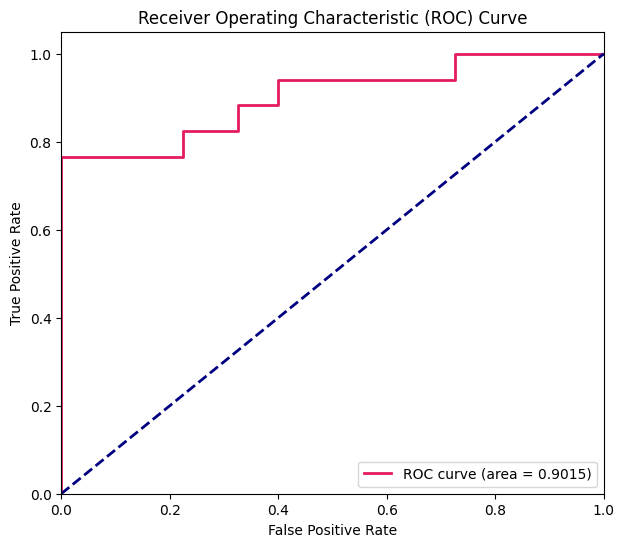

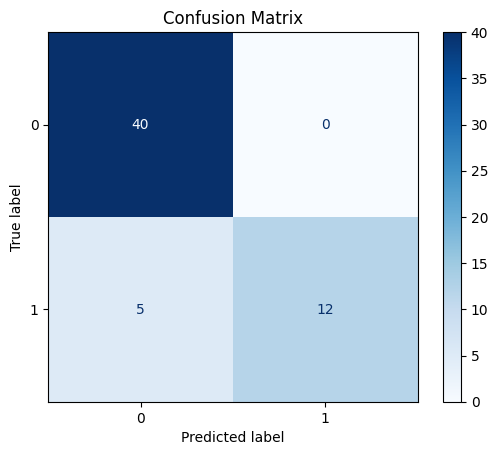



Fold 1 Results - Accuracy: 0.9123, F1 Score: 0.8844, Precision: 0.9444, Recall: 0.8529, AUROC: 0.9015

Fold 2/10

Epoch 0, Train Loss: 0.6962, Train Accuracy: 0.6660, Test Loss: 0.6618
Epoch 10, Train Loss: 0.5344, Train Accuracy: 0.7480, Test Loss: 0.8569
Epoch 20, Train Loss: 0.4756, Train Accuracy: 0.8008, Test Loss: 0.6001
Epoch 30, Train Loss: 0.4420, Train Accuracy: 0.8262, Test Loss: 0.6725
Epoch 40, Train Loss: 0.4230, Train Accuracy: 0.8477, Test Loss: 0.6052
Epoch 50, Train Loss: 0.3793, Train Accuracy: 0.8750, Test Loss: 0.5430
Epoch 60, Train Loss: 0.3239, Train Accuracy: 0.9004, Test Loss: 0.5555
Epoch 70, Train Loss: 0.2592, Train Accuracy: 0.9258, Test Loss: 0.4292
Epoch 80, Train Loss: 0.2301, Train Accuracy: 0.9258, Test Loss: 0.4923
Epoch 90, Train Loss: 0.2048, Train Accuracy: 0.9434, Test Loss: 0.6122
Epoch 100, Train Loss: 0.1858, Train Accuracy: 0.9512, Test Loss: 0.6784
Epoch 110, Train Loss: 0.1670, Train Accuracy: 0.9668, Test Loss: 0.7664
Epoch 120, Train Lo

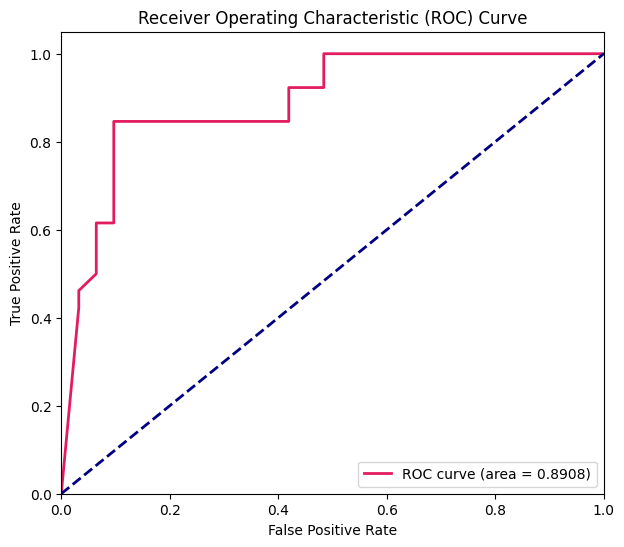

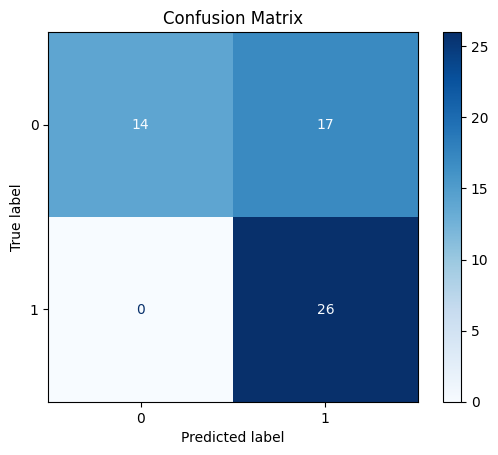



Fold 2 Results - Accuracy: 0.7018, F1 Score: 0.6879, Precision: 0.8023, Recall: 0.7258, AUROC: 0.8908

Fold 3/10

Epoch 0, Train Loss: 0.6945, Train Accuracy: 0.6836, Test Loss: 0.6300
Epoch 10, Train Loss: 0.5717, Train Accuracy: 0.6953, Test Loss: 0.6316
Epoch 20, Train Loss: 0.5537, Train Accuracy: 0.7188, Test Loss: 0.5971
Epoch 30, Train Loss: 0.5314, Train Accuracy: 0.7383, Test Loss: 0.5978
Epoch 40, Train Loss: 0.5085, Train Accuracy: 0.7637, Test Loss: 0.6352
Epoch 50, Train Loss: 0.4425, Train Accuracy: 0.7988, Test Loss: 0.7333
Epoch 60, Train Loss: 0.3715, Train Accuracy: 0.8555, Test Loss: 0.7931
Epoch 70, Train Loss: 0.3181, Train Accuracy: 0.8848, Test Loss: 0.7817
Epoch 80, Train Loss: 0.2730, Train Accuracy: 0.8945, Test Loss: 0.9290
Epoch 90, Train Loss: 0.2330, Train Accuracy: 0.9258, Test Loss: 0.8808
Epoch 100, Train Loss: 0.1989, Train Accuracy: 0.9355, Test Loss: 0.8928
Epoch 110, Train Loss: 0.2151, Train Accuracy: 0.9434, Test Loss: 1.0064
Epoch 120, Train Lo

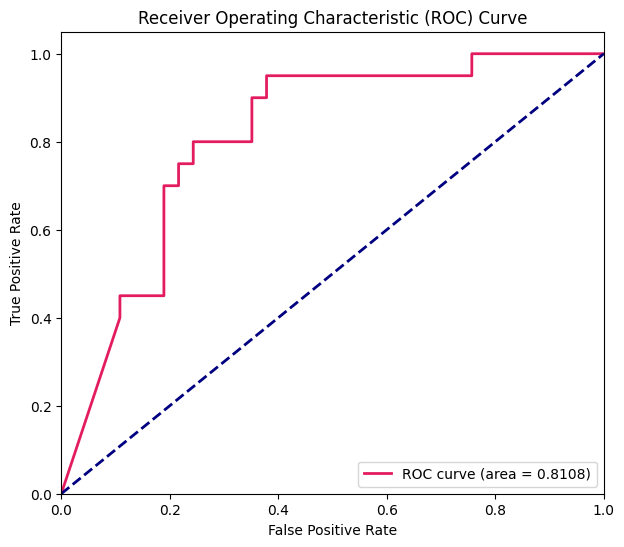

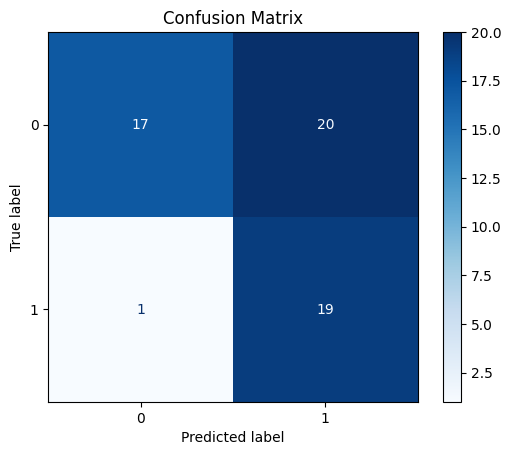



Fold 3 Results - Accuracy: 0.6316, F1 Score: 0.6311, Precision: 0.7158, Recall: 0.7047, AUROC: 0.8135

Fold 4/10

Epoch 0, Train Loss: 0.7005, Train Accuracy: 0.6484, Test Loss: 0.6122
Epoch 10, Train Loss: 0.5857, Train Accuracy: 0.6953, Test Loss: 0.5515
Epoch 20, Train Loss: 0.5644, Train Accuracy: 0.7129, Test Loss: 0.5658
Epoch 30, Train Loss: 0.5154, Train Accuracy: 0.7520, Test Loss: 0.4925
Epoch 40, Train Loss: 0.4480, Train Accuracy: 0.7793, Test Loss: 0.4380
Epoch 50, Train Loss: 0.3939, Train Accuracy: 0.8086, Test Loss: 0.3870
Epoch 60, Train Loss: 0.3367, Train Accuracy: 0.8535, Test Loss: 0.3559
Epoch 70, Train Loss: 0.3159, Train Accuracy: 0.8672, Test Loss: 0.3388
Epoch 80, Train Loss: 0.2781, Train Accuracy: 0.9082, Test Loss: 0.3300
Epoch 90, Train Loss: 0.2474, Train Accuracy: 0.9160, Test Loss: 0.3307
Epoch 100, Train Loss: 0.2110, Train Accuracy: 0.9453, Test Loss: 0.2916
Epoch 110, Train Loss: 0.1733, Train Accuracy: 0.9688, Test Loss: 0.2682
Epoch 120, Train Lo

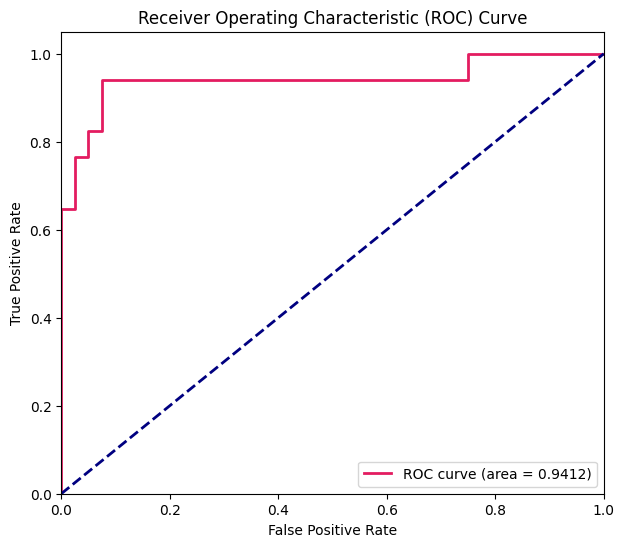

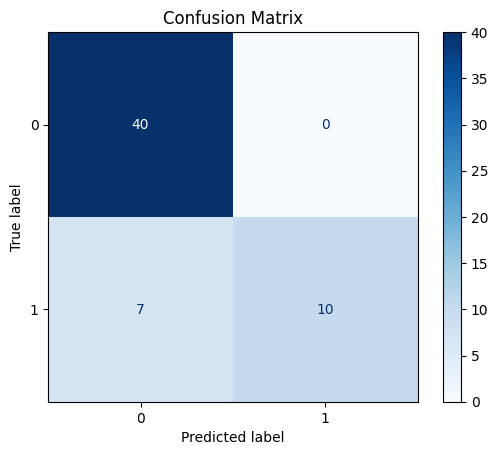



Fold 4 Results - Accuracy: 0.8772, F1 Score: 0.8301, Precision: 0.9255, Recall: 0.7941, AUROC: 0.9412

Fold 5/10

Epoch 0, Train Loss: 0.7078, Train Accuracy: 0.6602, Test Loss: 0.6256
Epoch 10, Train Loss: 0.5717, Train Accuracy: 0.6992, Test Loss: 0.7140
Epoch 20, Train Loss: 0.5225, Train Accuracy: 0.7500, Test Loss: 0.5722
Epoch 30, Train Loss: 0.4674, Train Accuracy: 0.7910, Test Loss: 0.5700
Epoch 40, Train Loss: 0.4110, Train Accuracy: 0.8379, Test Loss: 0.6053
Epoch 50, Train Loss: 0.3808, Train Accuracy: 0.8672, Test Loss: 0.7825
Epoch 60, Train Loss: 0.3384, Train Accuracy: 0.9004, Test Loss: 0.7067
Epoch 70, Train Loss: 0.2825, Train Accuracy: 0.9160, Test Loss: 0.8027
Epoch 80, Train Loss: 0.2391, Train Accuracy: 0.9609, Test Loss: 0.7801
Epoch 90, Train Loss: 0.2065, Train Accuracy: 0.9609, Test Loss: 0.7677
Epoch 100, Train Loss: 0.1774, Train Accuracy: 0.9668, Test Loss: 0.8072
Epoch 110, Train Loss: 0.1664, Train Accuracy: 0.9688, Test Loss: 1.0225
Epoch 120, Train Lo

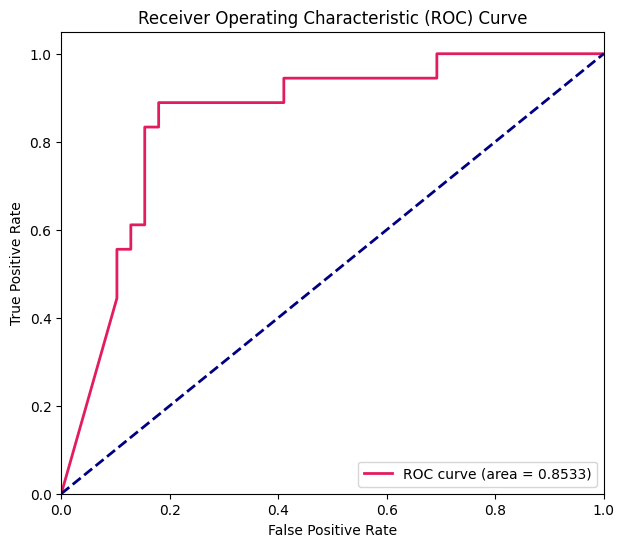

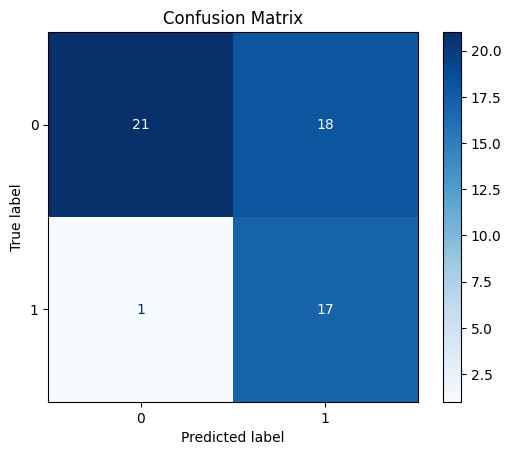



Fold 5 Results - Accuracy: 0.6667, F1 Score: 0.6650, Precision: 0.7201, Recall: 0.7415, AUROC: 0.8526

Fold 6/10

Epoch 0, Train Loss: 0.7023, Train Accuracy: 0.6641, Test Loss: 0.6648
Epoch 10, Train Loss: 0.5569, Train Accuracy: 0.7148, Test Loss: 0.7999
Epoch 20, Train Loss: 0.4936, Train Accuracy: 0.7734, Test Loss: 0.8471
Epoch 30, Train Loss: 0.3571, Train Accuracy: 0.8594, Test Loss: 1.4683
Epoch 40, Train Loss: 0.2130, Train Accuracy: 0.9336, Test Loss: 1.0986
Epoch 50, Train Loss: 0.1444, Train Accuracy: 0.9531, Test Loss: 1.0111
Epoch 60, Train Loss: 0.0941, Train Accuracy: 0.9785, Test Loss: 1.0098
Epoch 70, Train Loss: 0.0725, Train Accuracy: 0.9844, Test Loss: 1.0102
Epoch 80, Train Loss: 0.0622, Train Accuracy: 0.9922, Test Loss: 1.1695
Epoch 90, Train Loss: 0.0448, Train Accuracy: 0.9961, Test Loss: 1.1752
Epoch 100, Train Loss: 0.0425, Train Accuracy: 0.9941, Test Loss: 1.4746
Epoch 110, Train Loss: 0.0439, Train Accuracy: 0.9961, Test Loss: 1.1206
Epoch 120, Train Lo

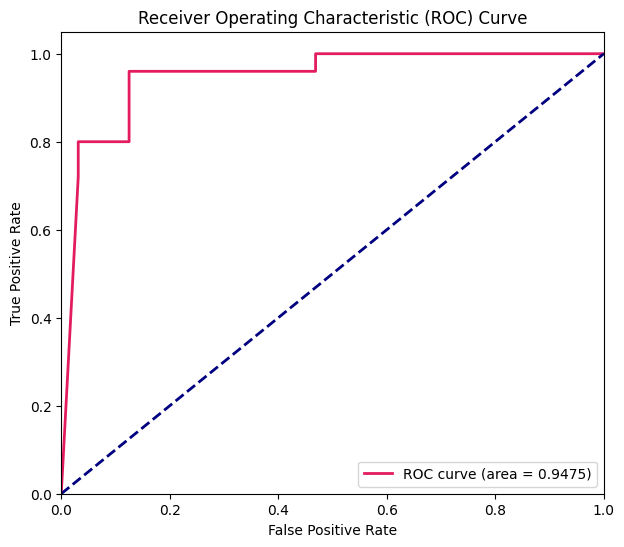

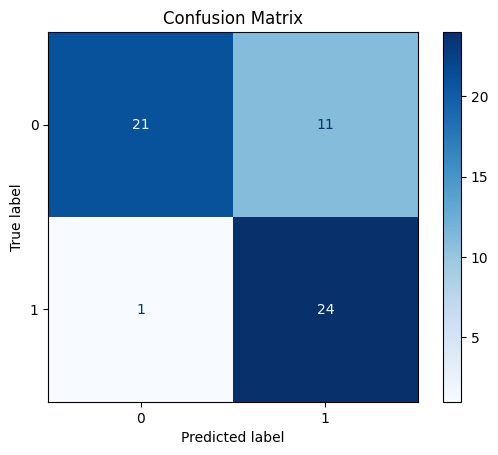



Fold 6 Results - Accuracy: 0.7895, F1 Score: 0.7889, Precision: 0.8201, Recall: 0.8081, AUROC: 0.9481

Fold 7/10

Epoch 0, Train Loss: 0.6847, Train Accuracy: 0.6660, Test Loss: 0.6134
Epoch 10, Train Loss: 0.5584, Train Accuracy: 0.7520, Test Loss: 0.6105
Epoch 20, Train Loss: 0.4861, Train Accuracy: 0.7891, Test Loss: 0.5865
Epoch 30, Train Loss: 0.4072, Train Accuracy: 0.8320, Test Loss: 0.5940
Epoch 40, Train Loss: 0.3219, Train Accuracy: 0.8906, Test Loss: 0.5007
Epoch 50, Train Loss: 0.2674, Train Accuracy: 0.9160, Test Loss: 0.4346
Epoch 60, Train Loss: 0.2271, Train Accuracy: 0.9375, Test Loss: 0.4010
Epoch 70, Train Loss: 0.1867, Train Accuracy: 0.9512, Test Loss: 0.4041
Epoch 80, Train Loss: 0.1788, Train Accuracy: 0.9570, Test Loss: 0.4521
Epoch 90, Train Loss: 0.1834, Train Accuracy: 0.9668, Test Loss: 0.4832
Epoch 100, Train Loss: 0.1496, Train Accuracy: 0.9648, Test Loss: 0.5189
Epoch 110, Train Loss: 0.1348, Train Accuracy: 0.9668, Test Loss: 0.5754
Epoch 120, Train Lo

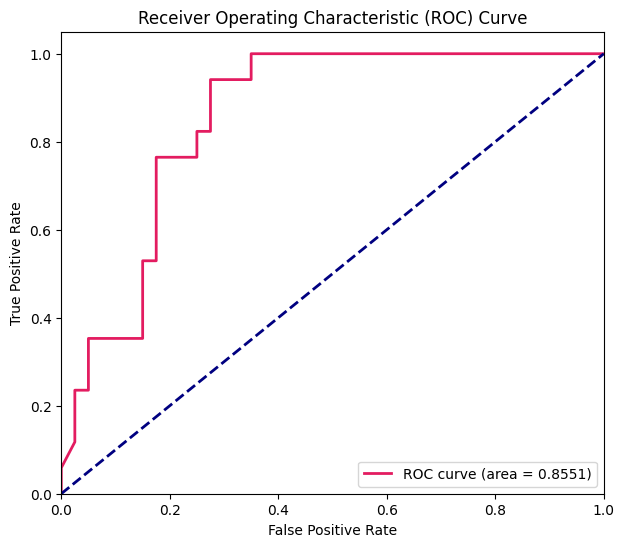

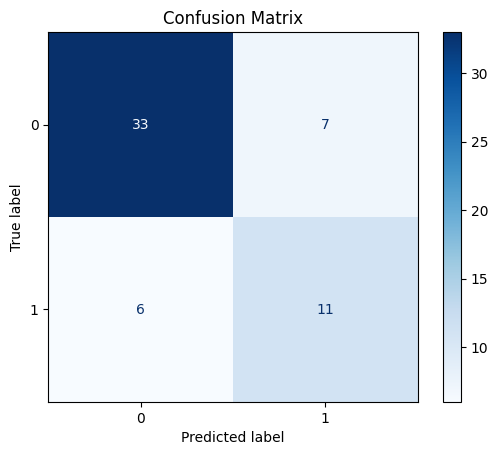



Fold 7 Results - Accuracy: 0.7719, F1 Score: 0.7320, Precision: 0.7286, Recall: 0.7360, AUROC: 0.8544

Fold 8/10

Epoch 0, Train Loss: 0.6919, Train Accuracy: 0.6875, Test Loss: 0.6695
Epoch 10, Train Loss: 0.5566, Train Accuracy: 0.7266, Test Loss: 0.6581
Epoch 20, Train Loss: 0.5430, Train Accuracy: 0.7090, Test Loss: 0.6106
Epoch 30, Train Loss: 0.5183, Train Accuracy: 0.7539, Test Loss: 0.6708
Epoch 40, Train Loss: 0.4880, Train Accuracy: 0.7812, Test Loss: 0.7091
Epoch 50, Train Loss: 0.4353, Train Accuracy: 0.8223, Test Loss: 0.7043
Epoch 60, Train Loss: 0.3864, Train Accuracy: 0.8555, Test Loss: 0.6932
Epoch 70, Train Loss: 0.2999, Train Accuracy: 0.8906, Test Loss: 0.8503
Epoch 80, Train Loss: 0.2353, Train Accuracy: 0.9141, Test Loss: 0.7120
Epoch 90, Train Loss: 0.1946, Train Accuracy: 0.9414, Test Loss: 0.4147
Epoch 100, Train Loss: 0.1603, Train Accuracy: 0.9609, Test Loss: 0.1713
Epoch 110, Train Loss: 0.1272, Train Accuracy: 0.9863, Test Loss: 0.1427
Epoch 120, Train Lo

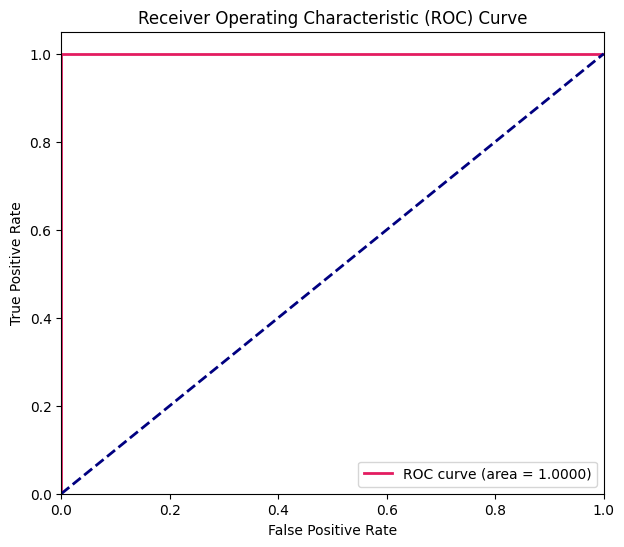

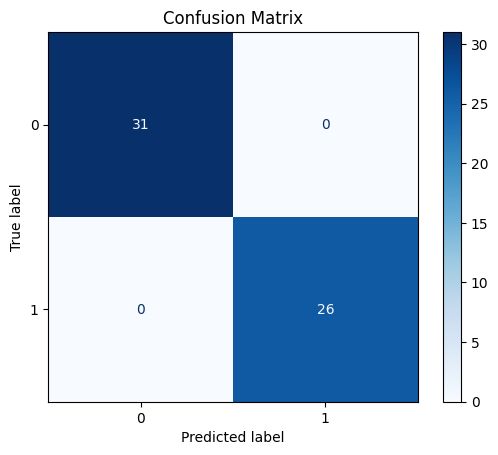



Fold 8 Results - Accuracy: 1.0000, F1 Score: 1.0000, Precision: 1.0000, Recall: 1.0000, AUROC: 1.0000

Fold 9/10

Epoch 0, Train Loss: 0.6868, Train Accuracy: 0.6914, Test Loss: 0.6293
Epoch 10, Train Loss: 0.5731, Train Accuracy: 0.7070, Test Loss: 0.6563
Epoch 20, Train Loss: 0.5600, Train Accuracy: 0.7227, Test Loss: 0.6170
Epoch 30, Train Loss: 0.5449, Train Accuracy: 0.7207, Test Loss: 0.6249
Epoch 40, Train Loss: 0.5235, Train Accuracy: 0.7324, Test Loss: 0.6082
Epoch 50, Train Loss: 0.4704, Train Accuracy: 0.7930, Test Loss: 0.8552
Epoch 60, Train Loss: 0.3850, Train Accuracy: 0.8730, Test Loss: 1.2368
Epoch 70, Train Loss: 0.2955, Train Accuracy: 0.9043, Test Loss: 1.6844
Epoch 80, Train Loss: 0.2475, Train Accuracy: 0.9023, Test Loss: 0.9745
Epoch 90, Train Loss: 0.2033, Train Accuracy: 0.9414, Test Loss: 2.3146
Epoch 100, Train Loss: 0.1993, Train Accuracy: 0.9551, Test Loss: 2.1325
Epoch 110, Train Loss: 0.1838, Train Accuracy: 0.9609, Test Loss: 1.4540
Epoch 120, Train Lo

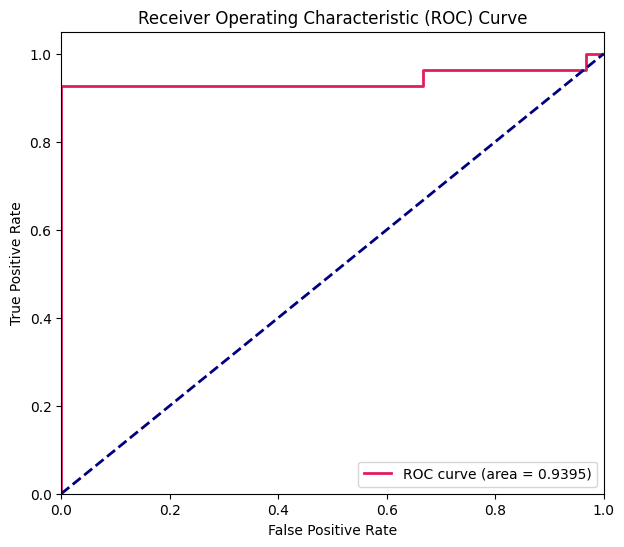

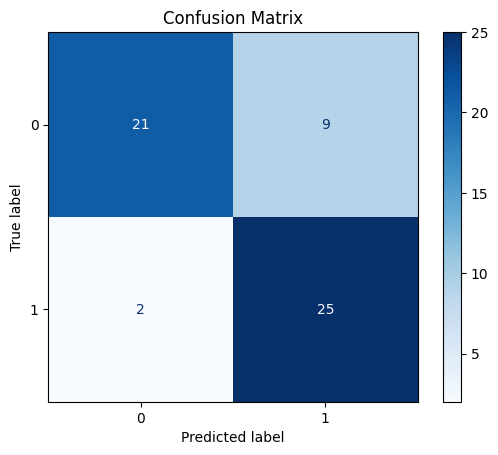



Fold 9 Results - Accuracy: 0.8070, F1 Score: 0.8061, Precision: 0.8242, Recall: 0.8130, AUROC: 0.9395

Fold 10/10

Epoch 0, Train Loss: 0.6860, Train Accuracy: 0.6784, Test Loss: 0.6287
Epoch 10, Train Loss: 0.5593, Train Accuracy: 0.7212, Test Loss: 0.6475
Epoch 20, Train Loss: 0.5325, Train Accuracy: 0.7583, Test Loss: 0.7440
Epoch 30, Train Loss: 0.4752, Train Accuracy: 0.8129, Test Loss: 0.7598
Epoch 40, Train Loss: 0.3815, Train Accuracy: 0.8674, Test Loss: 0.9105
Epoch 50, Train Loss: 0.3171, Train Accuracy: 0.8869, Test Loss: 0.7710
Epoch 60, Train Loss: 0.2872, Train Accuracy: 0.9298, Test Loss: 0.7079
Epoch 70, Train Loss: 0.2602, Train Accuracy: 0.9454, Test Loss: 0.6398
Epoch 80, Train Loss: 0.2213, Train Accuracy: 0.9532, Test Loss: 0.7910
Epoch 90, Train Loss: 0.1879, Train Accuracy: 0.9688, Test Loss: 0.8740
Epoch 100, Train Loss: 0.1773, Train Accuracy: 0.9688, Test Loss: 0.9034
Epoch 110, Train Loss: 0.1581, Train Accuracy: 0.9805, Test Loss: 1.0392
Epoch 120, Train L

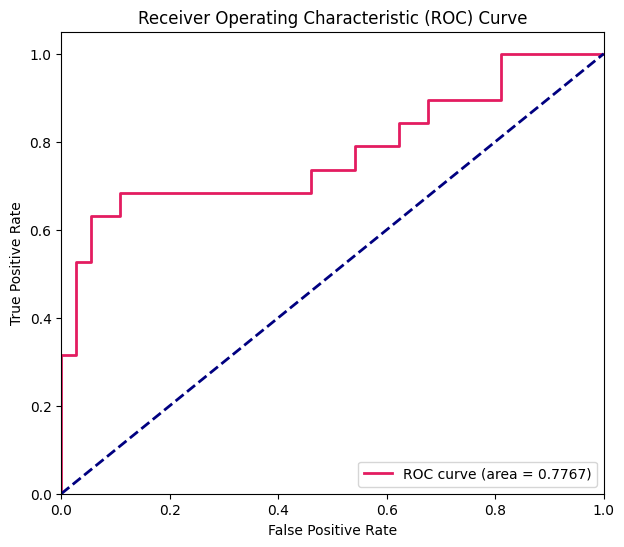

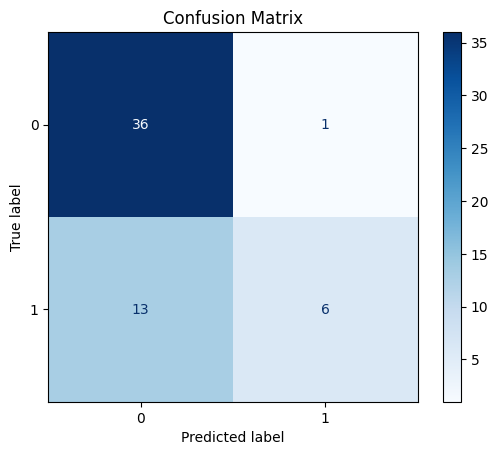



Fold 10 Results - Accuracy: 0.7500, F1 Score: 0.6494, Precision: 0.7959, Recall: 0.6444, AUROC: 0.7767

Average Results across 10 folds:
Accuracy: 0.7908, F1 Score: 0.7675, Precision: 0.8277, Recall: 0.7821, AUROC: 0.8918


In [ ]:
# Create KNN graph from the data
def create_knn_graph(X, k):
    index = faiss.IndexFlatL2(X.shape[1])  # L2 distance
    X_contiguous = np.ascontiguousarray(X.values.astype(np.float32))
    index.add(X_contiguous)
    _, knn_graph = index.search(X_contiguous, k)

    G = nx.Graph()
    for i in range(X.shape[0]):
        for j in knn_graph[i]:
            G.add_edge(i, j)
    return from_networkx(G)

# Define the GAT model
class GAT(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes, heads=8):
        super(GAT, self).__init__()
        self.gat_conv1 = GATConv(num_features, hidden_channels, heads=heads, concat=True)
        self.gat_conv2 = GATConv(hidden_channels * heads, num_classes, heads=1, concat=False)
        self.init_weights()

    def init_weights(self):
        self.gat_conv1.reset_parameters()
        self.gat_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gat_conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, training=self.training)
        x = self.gat_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Training function
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.to(device))
    loss = F.nll_loss(out, data.y.to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

# Function to compute accuracy on the training data
def train_accuracy(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        correct = preds.eq(data.y.to(device)).sum().item()
        acc = correct / data.y.size(0)
    return acc

# Function to compute test loss
def test_loss(model, data):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        logits = model(data.to(device))
        loss = F.nll_loss(logits, data.y.to(device))  # Compute the loss for test data
    return loss.item()

# Evaluation function
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        y_true = data.y.to(device)
        y_pred = preds
        y_prob = logits[:, 1]  # Probability for the positive class

        test_acc = (y_pred == y_true).sum().item() / y_true.size(0)
        test_precision = FM.precision(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_recall = FM.recall(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_f1 = FM.f1_score(y_pred, y_true, average='macro', num_classes=2, task='multiclass')

        # Compute AUROC
        auroc = FM.auroc(y_prob, y_true, num_classes=2, task='binary')

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_true.cpu(), y_prob.cpu())
        roc_auc = auc(fpr, tpr)

        print('\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n')

        # Plot ROC curve
        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='#e31c60', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.show()

        print('\n')

        # Confusion Matrix
        cm = confusion_matrix(y_true.cpu(), y_pred.cpu())
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.show()

        print('\n')

    return test_acc, test_f1.item(), test_precision.item(), test_recall.item(), auroc.item()

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_channels = 320
num_classes = 2
optimizer_class = torch.optim.Adam

# Set up K-Fold Cross Validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics across folds
accuracy_list = []
f1_list = []
precision_list = []
recall_list = []
auroc_list = []

# Perform 10-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"\nFold {fold + 1}/{n_splits}\n")

    # Split into training and test sets for this fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalization (if needed)
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    # Create KNN graphs for training and test data
    k = 15
    train_graph = create_knn_graph(X_train, k)
    test_graph = create_knn_graph(X_test, k)

    # Convert features and labels for training and test data to tensors
    train_graph.x = torch.tensor(X_train.values, dtype=torch.float)
    train_graph.y = torch.tensor(y_train.values, dtype=torch.long)
    test_graph.x = torch.tensor(X_test.values, dtype=torch.float)
    test_graph.y = torch.tensor(y_test.values, dtype=torch.long)

    # Initialize model and optimizer for each fold
    # Choose either GCN or GAT model:

    # Uncomment to use GAT
    model = GAT(num_features=X_train.shape[1], hidden_channels=256, num_classes=num_classes, heads=8).to(device)

    optimizer = optimizer_class(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Train the model for this fold
    for epoch in range(600):
        train_loss = train(model, train_graph, optimizer)
        if epoch % 10 == 0:
            train_acc = train_accuracy(model, train_graph)
            current_test_loss = test_loss(model, test_graph)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model on the test set for this fold
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, test_graph)

    # Store the metrics
    accuracy_list.append(test_acc)
    f1_list.append(test_f1)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    auroc_list.append(auroc)

    print(f"Fold {fold + 1} Results - Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}")

# Calculate average metrics across all folds
avg_accuracy = np.mean(accuracy_list)
avg_f1 = np.mean(f1_list)
avg_precision = np.mean(precision_list)
avg_recall = np.mean(recall_list)
avg_auroc = np.mean(auroc_list)

print("\nAverage Results across 10 folds:")
print(f"Accuracy: {avg_accuracy:.4f}, F1 Score: {avg_f1:.4f}, Precision: {avg_precision:.4f}, Recall: {avg_recall:.4f}, AUROC: {avg_auroc:.4f}")


##### GraphSAGE (with tuned hyperparameters: Hidden Channel 128, Learning Rate 0.001, Weight Decay 1e-4, Optimizer ADAM)


Fold 1/10

Epoch 0, Train Loss: 0.7244, Train Accuracy: 0.6211, Test Loss: 0.6272
Epoch 10, Train Loss: 0.3920, Train Accuracy: 0.9121, Test Loss: 0.3486
Epoch 20, Train Loss: 0.2592, Train Accuracy: 0.9414, Test Loss: 0.2240
Epoch 30, Train Loss: 0.1740, Train Accuracy: 0.9570, Test Loss: 0.1609
Epoch 40, Train Loss: 0.1367, Train Accuracy: 0.9688, Test Loss: 0.1265
Epoch 50, Train Loss: 0.1093, Train Accuracy: 0.9805, Test Loss: 0.1069
Epoch 60, Train Loss: 0.0932, Train Accuracy: 0.9844, Test Loss: 0.0950
Epoch 70, Train Loss: 0.0793, Train Accuracy: 0.9824, Test Loss: 0.0879
Epoch 80, Train Loss: 0.0723, Train Accuracy: 0.9844, Test Loss: 0.0832
Epoch 90, Train Loss: 0.0678, Train Accuracy: 0.9844, Test Loss: 0.0803
Epoch 100, Train Loss: 0.0660, Train Accuracy: 0.9863, Test Loss: 0.0786
Epoch 110, Train Loss: 0.0595, Train Accuracy: 0.9883, Test Loss: 0.0772
Epoch 120, Train Loss: 0.0526, Train Accuracy: 0.9863, Test Loss: 0.0762
Epoch 130, Train Loss: 0.0487, Train Accuracy: 0.9

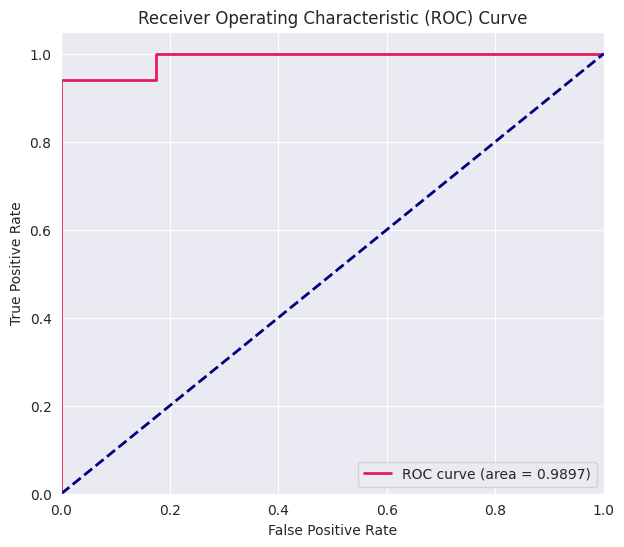

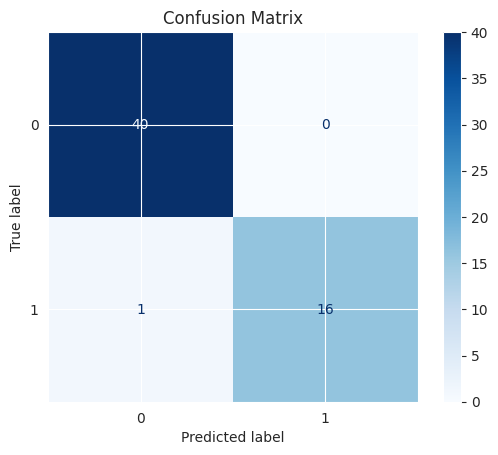



Fold 1 Results - Accuracy: 0.9825, F1 Score: 0.9787, Precision: 0.9878, Recall: 0.9706, AUROC: 0.9897

Fold 2/10

Epoch 0, Train Loss: 0.8378, Train Accuracy: 0.5977, Test Loss: 0.8139
Epoch 10, Train Loss: 0.4272, Train Accuracy: 0.9004, Test Loss: 0.3854
Epoch 20, Train Loss: 0.2639, Train Accuracy: 0.9297, Test Loss: 0.2242
Epoch 30, Train Loss: 0.1906, Train Accuracy: 0.9492, Test Loss: 0.1544
Epoch 40, Train Loss: 0.1521, Train Accuracy: 0.9570, Test Loss: 0.1160
Epoch 50, Train Loss: 0.1253, Train Accuracy: 0.9668, Test Loss: 0.0946
Epoch 60, Train Loss: 0.1055, Train Accuracy: 0.9648, Test Loss: 0.0778
Epoch 70, Train Loss: 0.0984, Train Accuracy: 0.9668, Test Loss: 0.0693
Epoch 80, Train Loss: 0.0877, Train Accuracy: 0.9766, Test Loss: 0.0620
Epoch 90, Train Loss: 0.0777, Train Accuracy: 0.9766, Test Loss: 0.0557
Epoch 100, Train Loss: 0.0706, Train Accuracy: 0.9805, Test Loss: 0.0522
Epoch 110, Train Loss: 0.0647, Train Accuracy: 0.9863, Test Loss: 0.0482
Epoch 120, Train Lo

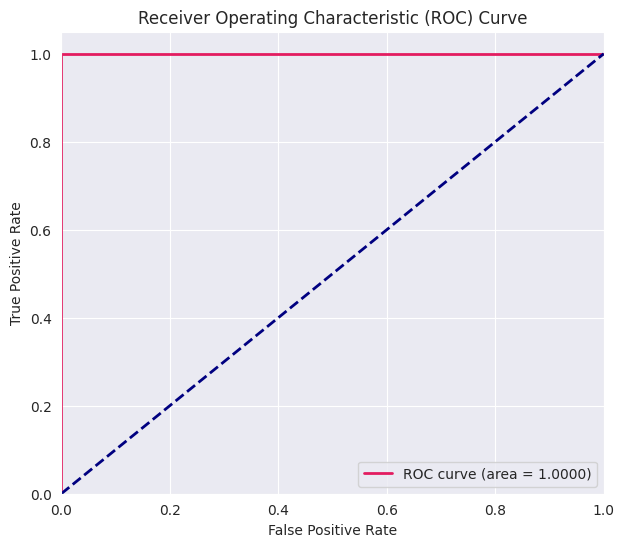

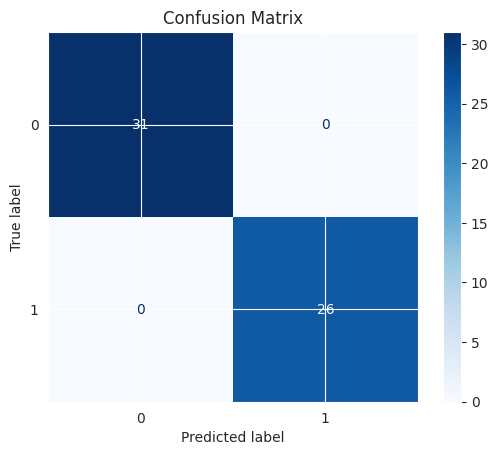



Fold 2 Results - Accuracy: 1.0000, F1 Score: 1.0000, Precision: 1.0000, Recall: 1.0000, AUROC: 1.0000

Fold 3/10

Epoch 0, Train Loss: 0.7277, Train Accuracy: 0.6270, Test Loss: 0.6585
Epoch 10, Train Loss: 0.3888, Train Accuracy: 0.9199, Test Loss: 0.3686
Epoch 20, Train Loss: 0.2460, Train Accuracy: 0.9453, Test Loss: 0.2640
Epoch 30, Train Loss: 0.1846, Train Accuracy: 0.9531, Test Loss: 0.2090
Epoch 40, Train Loss: 0.1484, Train Accuracy: 0.9609, Test Loss: 0.1631
Epoch 50, Train Loss: 0.1214, Train Accuracy: 0.9629, Test Loss: 0.1302
Epoch 60, Train Loss: 0.1027, Train Accuracy: 0.9668, Test Loss: 0.1082
Epoch 70, Train Loss: 0.0861, Train Accuracy: 0.9805, Test Loss: 0.0934
Epoch 80, Train Loss: 0.0852, Train Accuracy: 0.9805, Test Loss: 0.0823
Epoch 90, Train Loss: 0.0761, Train Accuracy: 0.9844, Test Loss: 0.0736
Epoch 100, Train Loss: 0.0582, Train Accuracy: 0.9863, Test Loss: 0.0675
Epoch 110, Train Loss: 0.0634, Train Accuracy: 0.9863, Test Loss: 0.0624
Epoch 120, Train Lo

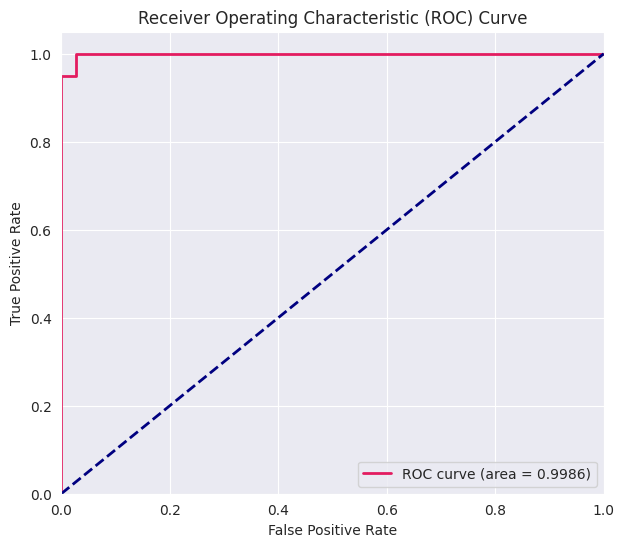

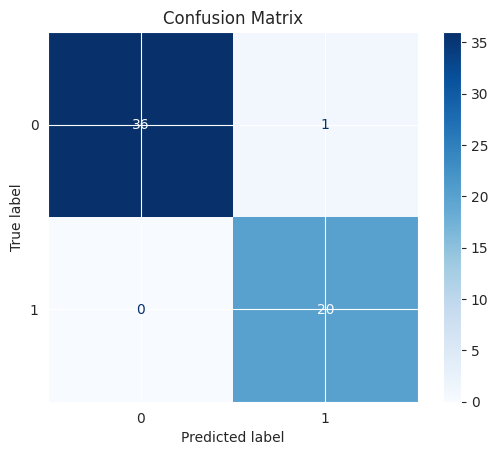



Fold 3 Results - Accuracy: 0.9825, F1 Score: 0.9810, Precision: 0.9762, Recall: 0.9865, AUROC: 0.9986

Fold 4/10

Epoch 0, Train Loss: 0.8114, Train Accuracy: 0.3750, Test Loss: 0.7315
Epoch 10, Train Loss: 0.4270, Train Accuracy: 0.8672, Test Loss: 0.3502
Epoch 20, Train Loss: 0.2633, Train Accuracy: 0.9316, Test Loss: 0.2257
Epoch 30, Train Loss: 0.1981, Train Accuracy: 0.9453, Test Loss: 0.1669
Epoch 40, Train Loss: 0.1543, Train Accuracy: 0.9551, Test Loss: 0.1311
Epoch 50, Train Loss: 0.1232, Train Accuracy: 0.9688, Test Loss: 0.1073
Epoch 60, Train Loss: 0.1137, Train Accuracy: 0.9766, Test Loss: 0.0920
Epoch 70, Train Loss: 0.0952, Train Accuracy: 0.9785, Test Loss: 0.0812
Epoch 80, Train Loss: 0.0896, Train Accuracy: 0.9785, Test Loss: 0.0724
Epoch 90, Train Loss: 0.0837, Train Accuracy: 0.9805, Test Loss: 0.0664
Epoch 100, Train Loss: 0.0741, Train Accuracy: 0.9824, Test Loss: 0.0610
Epoch 110, Train Loss: 0.0756, Train Accuracy: 0.9844, Test Loss: 0.0559
Epoch 120, Train Lo

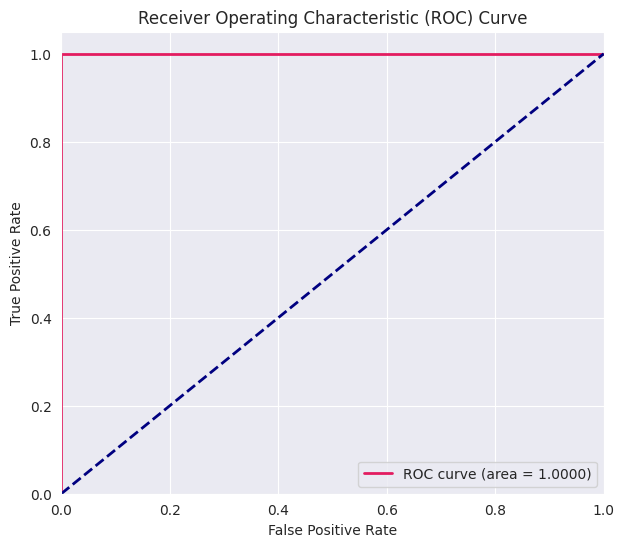

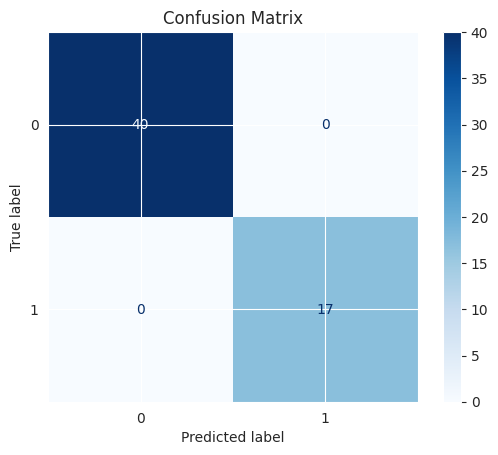



Fold 4 Results - Accuracy: 1.0000, F1 Score: 1.0000, Precision: 1.0000, Recall: 1.0000, AUROC: 1.0000

Fold 5/10

Epoch 0, Train Loss: 0.7478, Train Accuracy: 0.5508, Test Loss: 0.6953
Epoch 10, Train Loss: 0.4032, Train Accuracy: 0.9023, Test Loss: 0.3630
Epoch 20, Train Loss: 0.2455, Train Accuracy: 0.9414, Test Loss: 0.2361
Epoch 30, Train Loss: 0.1858, Train Accuracy: 0.9512, Test Loss: 0.1682
Epoch 40, Train Loss: 0.1449, Train Accuracy: 0.9609, Test Loss: 0.1305
Epoch 50, Train Loss: 0.1169, Train Accuracy: 0.9668, Test Loss: 0.1103
Epoch 60, Train Loss: 0.0981, Train Accuracy: 0.9746, Test Loss: 0.0974
Epoch 70, Train Loss: 0.0860, Train Accuracy: 0.9785, Test Loss: 0.0879
Epoch 80, Train Loss: 0.0828, Train Accuracy: 0.9805, Test Loss: 0.0803
Epoch 90, Train Loss: 0.0671, Train Accuracy: 0.9844, Test Loss: 0.0741
Epoch 100, Train Loss: 0.0605, Train Accuracy: 0.9883, Test Loss: 0.0693
Epoch 110, Train Loss: 0.0597, Train Accuracy: 0.9902, Test Loss: 0.0656
Epoch 120, Train Lo

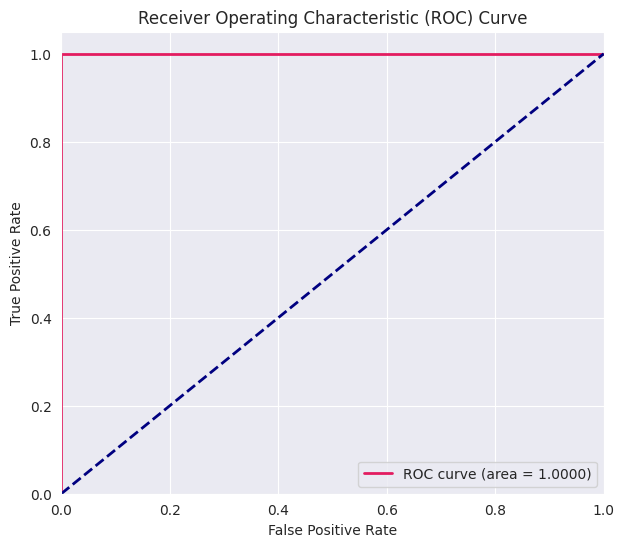

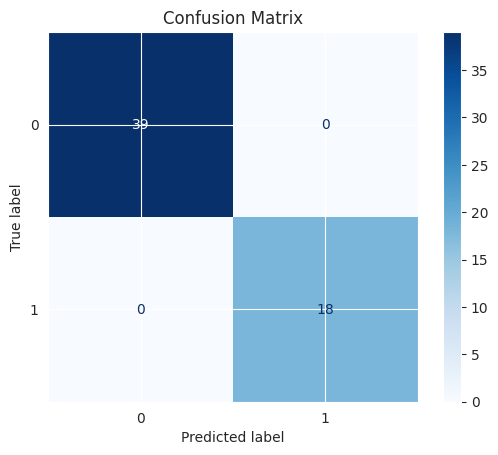



Fold 5 Results - Accuracy: 1.0000, F1 Score: 1.0000, Precision: 1.0000, Recall: 1.0000, AUROC: 1.0000

Fold 6/10

Epoch 0, Train Loss: 0.6289, Train Accuracy: 0.8555, Test Loss: 0.5804
Epoch 10, Train Loss: 0.3367, Train Accuracy: 0.9062, Test Loss: 0.3492
Epoch 20, Train Loss: 0.2274, Train Accuracy: 0.9336, Test Loss: 0.2497
Epoch 30, Train Loss: 0.1624, Train Accuracy: 0.9590, Test Loss: 0.1985
Epoch 40, Train Loss: 0.1224, Train Accuracy: 0.9668, Test Loss: 0.1695
Epoch 50, Train Loss: 0.1026, Train Accuracy: 0.9746, Test Loss: 0.1534
Epoch 60, Train Loss: 0.0898, Train Accuracy: 0.9785, Test Loss: 0.1440
Epoch 70, Train Loss: 0.0751, Train Accuracy: 0.9824, Test Loss: 0.1386
Epoch 80, Train Loss: 0.0702, Train Accuracy: 0.9883, Test Loss: 0.1375
Epoch 90, Train Loss: 0.0591, Train Accuracy: 0.9883, Test Loss: 0.1379
Epoch 100, Train Loss: 0.0540, Train Accuracy: 0.9902, Test Loss: 0.1386
Epoch 110, Train Loss: 0.0466, Train Accuracy: 0.9902, Test Loss: 0.1419
Epoch 120, Train Lo

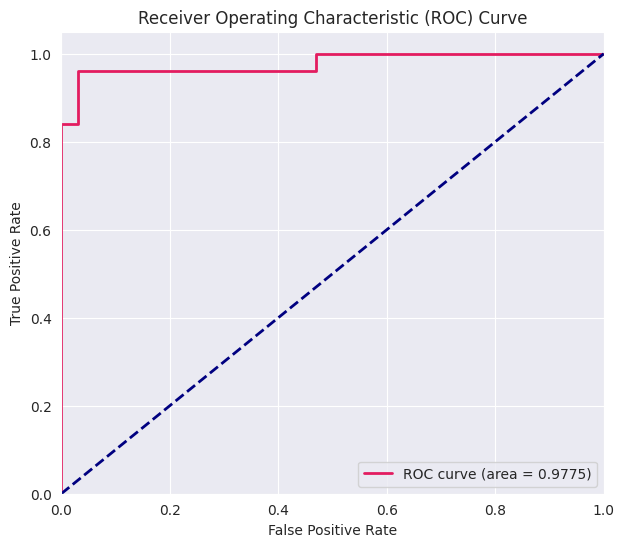

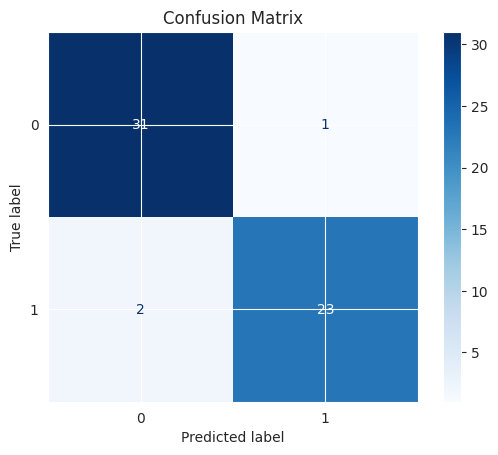



Fold 6 Results - Accuracy: 0.9474, F1 Score: 0.9463, Precision: 0.9489, Recall: 0.9444, AUROC: 0.9775

Fold 7/10

Epoch 0, Train Loss: 0.7356, Train Accuracy: 0.6621, Test Loss: 0.6625
Epoch 10, Train Loss: 0.3807, Train Accuracy: 0.9043, Test Loss: 0.3718
Epoch 20, Train Loss: 0.2540, Train Accuracy: 0.9336, Test Loss: 0.2450
Epoch 30, Train Loss: 0.1768, Train Accuracy: 0.9512, Test Loss: 0.1708
Epoch 40, Train Loss: 0.1388, Train Accuracy: 0.9629, Test Loss: 0.1235
Epoch 50, Train Loss: 0.1188, Train Accuracy: 0.9707, Test Loss: 0.0944
Epoch 60, Train Loss: 0.1021, Train Accuracy: 0.9727, Test Loss: 0.0765
Epoch 70, Train Loss: 0.0951, Train Accuracy: 0.9785, Test Loss: 0.0650
Epoch 80, Train Loss: 0.0818, Train Accuracy: 0.9824, Test Loss: 0.0566
Epoch 90, Train Loss: 0.0746, Train Accuracy: 0.9824, Test Loss: 0.0505
Epoch 100, Train Loss: 0.0777, Train Accuracy: 0.9824, Test Loss: 0.0443
Epoch 110, Train Loss: 0.0677, Train Accuracy: 0.9863, Test Loss: 0.0410
Epoch 120, Train Lo

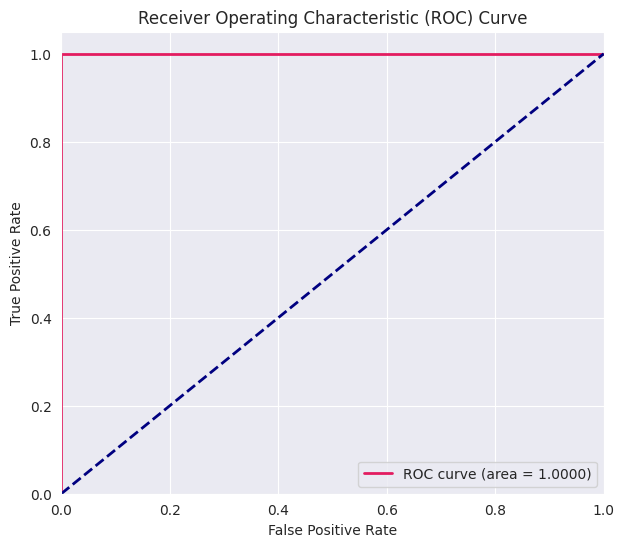

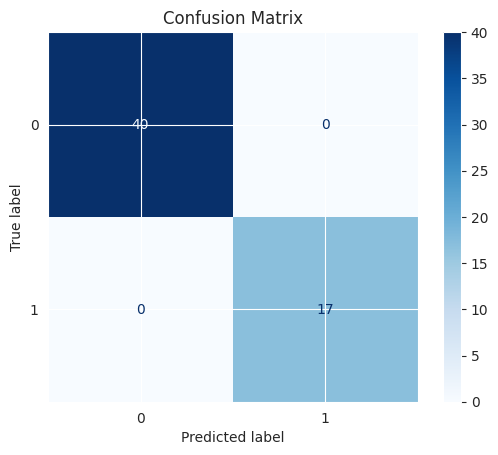



Fold 7 Results - Accuracy: 1.0000, F1 Score: 1.0000, Precision: 1.0000, Recall: 1.0000, AUROC: 1.0000

Fold 8/10

Epoch 0, Train Loss: 0.7549, Train Accuracy: 0.5820, Test Loss: 0.6578
Epoch 10, Train Loss: 0.3733, Train Accuracy: 0.9121, Test Loss: 0.3931
Epoch 20, Train Loss: 0.2345, Train Accuracy: 0.9316, Test Loss: 0.2636
Epoch 30, Train Loss: 0.1741, Train Accuracy: 0.9570, Test Loss: 0.1948
Epoch 40, Train Loss: 0.1332, Train Accuracy: 0.9668, Test Loss: 0.1585
Epoch 50, Train Loss: 0.1130, Train Accuracy: 0.9746, Test Loss: 0.1376
Epoch 60, Train Loss: 0.0951, Train Accuracy: 0.9766, Test Loss: 0.1227
Epoch 70, Train Loss: 0.0943, Train Accuracy: 0.9766, Test Loss: 0.1093
Epoch 80, Train Loss: 0.0810, Train Accuracy: 0.9785, Test Loss: 0.0982
Epoch 90, Train Loss: 0.0707, Train Accuracy: 0.9824, Test Loss: 0.0900
Epoch 100, Train Loss: 0.0683, Train Accuracy: 0.9824, Test Loss: 0.0834
Epoch 110, Train Loss: 0.0565, Train Accuracy: 0.9844, Test Loss: 0.0785
Epoch 120, Train Lo

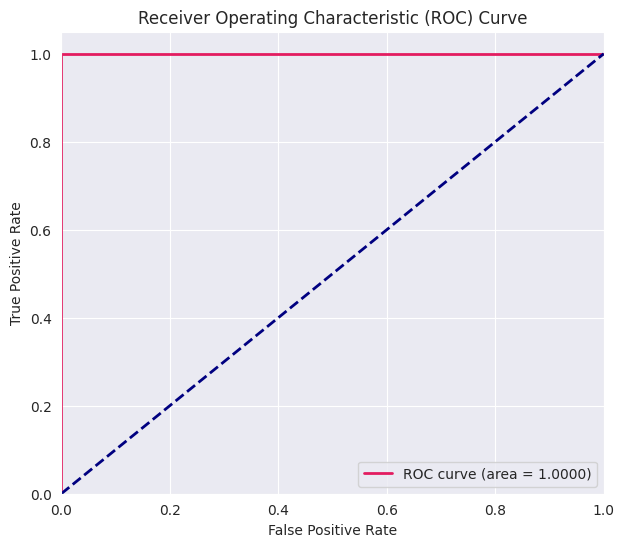

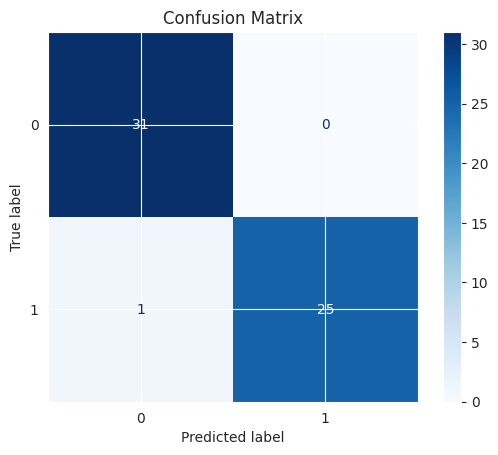



Fold 8 Results - Accuracy: 0.9825, F1 Score: 0.9823, Precision: 0.9844, Recall: 0.9808, AUROC: 1.0000

Fold 9/10

Epoch 0, Train Loss: 0.7495, Train Accuracy: 0.6504, Test Loss: 0.7965
Epoch 10, Train Loss: 0.3848, Train Accuracy: 0.9082, Test Loss: 0.3770
Epoch 20, Train Loss: 0.2371, Train Accuracy: 0.9375, Test Loss: 0.2292
Epoch 30, Train Loss: 0.1808, Train Accuracy: 0.9531, Test Loss: 0.1813
Epoch 40, Train Loss: 0.1409, Train Accuracy: 0.9629, Test Loss: 0.1604
Epoch 50, Train Loss: 0.1163, Train Accuracy: 0.9746, Test Loss: 0.1483
Epoch 60, Train Loss: 0.0994, Train Accuracy: 0.9766, Test Loss: 0.1400
Epoch 70, Train Loss: 0.0873, Train Accuracy: 0.9824, Test Loss: 0.1342
Epoch 80, Train Loss: 0.0758, Train Accuracy: 0.9863, Test Loss: 0.1297
Epoch 90, Train Loss: 0.0707, Train Accuracy: 0.9863, Test Loss: 0.1284
Epoch 100, Train Loss: 0.0624, Train Accuracy: 0.9863, Test Loss: 0.1267
Epoch 110, Train Loss: 0.0558, Train Accuracy: 0.9863, Test Loss: 0.1246
Epoch 120, Train Lo

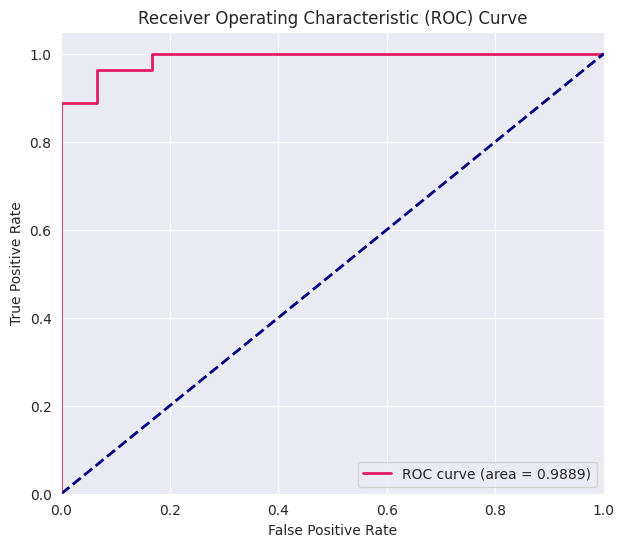

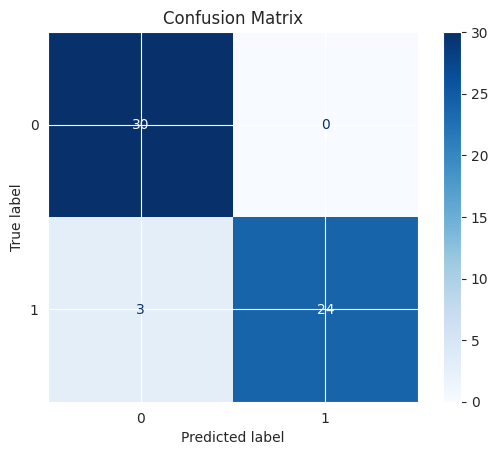



Fold 9 Results - Accuracy: 0.9474, F1 Score: 0.9468, Precision: 0.9545, Recall: 0.9444, AUROC: 0.9889

Fold 10/10

Epoch 0, Train Loss: 0.7885, Train Accuracy: 0.4483, Test Loss: 0.7067
Epoch 10, Train Loss: 0.4276, Train Accuracy: 0.9084, Test Loss: 0.3942
Epoch 20, Train Loss: 0.2607, Train Accuracy: 0.9298, Test Loss: 0.2810
Epoch 30, Train Loss: 0.1947, Train Accuracy: 0.9454, Test Loss: 0.2208
Epoch 40, Train Loss: 0.1460, Train Accuracy: 0.9571, Test Loss: 0.1825
Epoch 50, Train Loss: 0.1251, Train Accuracy: 0.9591, Test Loss: 0.1559
Epoch 60, Train Loss: 0.1012, Train Accuracy: 0.9688, Test Loss: 0.1362
Epoch 70, Train Loss: 0.0904, Train Accuracy: 0.9766, Test Loss: 0.1214
Epoch 80, Train Loss: 0.0929, Train Accuracy: 0.9825, Test Loss: 0.1102
Epoch 90, Train Loss: 0.0803, Train Accuracy: 0.9844, Test Loss: 0.1021
Epoch 100, Train Loss: 0.0671, Train Accuracy: 0.9844, Test Loss: 0.0968
Epoch 110, Train Loss: 0.0639, Train Accuracy: 0.9864, Test Loss: 0.0923
Epoch 120, Train L

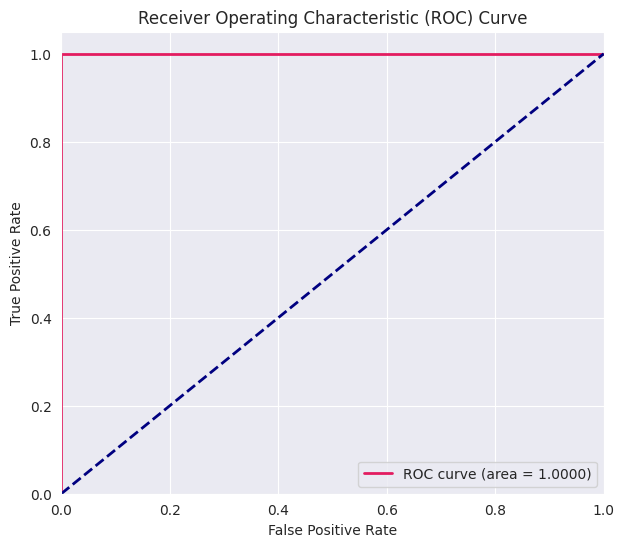

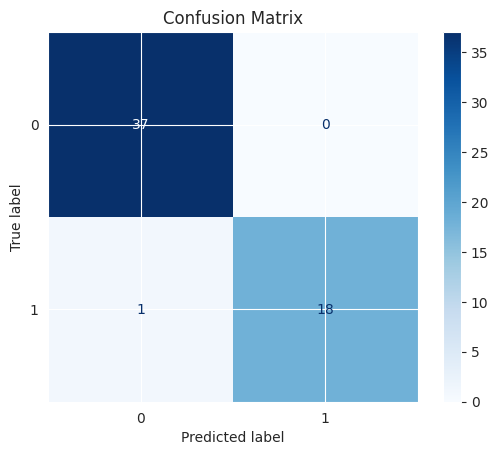



Fold 10 Results - Accuracy: 0.9821, F1 Score: 0.9798, Precision: 0.9868, Recall: 0.9737, AUROC: 1.0000

Average Results across 10 folds:
Accuracy: 0.9824, F1 Score: 0.9815, Precision: 0.9839, Recall: 0.9800, AUROC: 0.9955


In [ ]:
# Set up K-Fold Cross Validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Split X and y into training and test sets before graph construction
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a function to convert a dataset into a KNN graph
def create_knn_graph(X, k):
    index = faiss.IndexFlatL2(X.shape[1])  # L2 distance
    X_contiguous = np.ascontiguousarray(X.values.astype(np.float32))
    index.add(X_contiguous)
    _, knn_graph = index.search(X_contiguous, k)

    G = nx.Graph()
    for i in range(X.shape[0]):
        for j in knn_graph[i]:
            G.add_edge(i, j)
    return from_networkx(G)

# Create KNN graphs for training and testing data separately
k = 15
train_graph = create_knn_graph(X_train, k)
test_graph = create_knn_graph(X_test, k)

# Convert features and labels for training and test data to tensors
train_graph.x = torch.tensor(X_train.values, dtype=torch.float)
train_graph.y = torch.tensor(y_train.values, dtype=torch.long)
test_graph.x = torch.tensor(X_test.values, dtype=torch.float)
test_graph.y = torch.tensor(y_test.values, dtype=torch.long)

# Define the GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.sage_conv1 = SAGEConv(num_features, hidden_channels)
        self.sage_conv2 = SAGEConv(hidden_channels, num_classes)
        self.init_weights()

    def init_weights(self):
        self.sage_conv1.reset_parameters()
        self.sage_conv2.reset_parameters()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.sage_conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.sage_conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Training function
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.to(device))
    loss = F.nll_loss(out, data.y.to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

# Function to compute accuracy on the training data
def train_accuracy(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        correct = preds.eq(data.y.to(device)).sum().item()
        acc = correct / data.y.size(0)
    return acc

def test_loss(model, data):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        logits = model(data.to(device))
        loss = F.nll_loss(logits, data.y.to(device))  # Compute the loss for test data
    return loss.item()

# Evaluation function
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.to(device))
        preds = logits.max(1)[1]
        y_true = data.y.to(device)
        y_pred = preds
        y_prob = logits[:, 1]  # Probability for the positive class

        test_acc = (y_pred == y_true).sum().item() / y_true.size(0)
        test_precision = FM.precision(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_recall = FM.recall(y_pred, y_true, average='macro', num_classes=2, task='multiclass')
        test_f1 = FM.f1_score(y_pred, y_true, average='macro', num_classes=2, task='multiclass')

        # Compute AUROC
        auroc = FM.auroc(y_prob, y_true, num_classes=2, task='binary')

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_true.cpu(), y_prob.cpu())
        roc_auc = auc(fpr, tpr)

        print('\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n')

        # Plot ROC curve
        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='#e31c60', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.show()

        print('\n')

        # Confusion Matrix
        cm = confusion_matrix(y_true.cpu(), y_pred.cpu())
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.show()

        print('\n')

    return test_acc, test_f1.item(), test_precision.item(), test_recall.item(), auroc.item()

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_channels = 128
num_classes = 2
optimizer_class = torch.optim.Adam

# Lists to store metrics across folds
accuracy_list = []
f1_list = []
precision_list = []
recall_list = []
auroc_list = []

# Perform 10-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"\nFold {fold + 1}/{n_splits}\n")

    # Split into training and test sets for this fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalization (if needed)
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    # Create KNN graphs for training and test data
    k = 15
    train_graph = create_knn_graph(X_train, k)
    test_graph = create_knn_graph(X_test, k)

    # Convert features and labels for training and test data to tensors
    train_graph.x = torch.tensor(X_train.values, dtype=torch.float)
    train_graph.y = torch.tensor(y_train.values, dtype=torch.long)
    test_graph.x = torch.tensor(X_test.values, dtype=torch.float)
    test_graph.y = torch.tensor(y_test.values, dtype=torch.long)

    # Initialize model and optimizer for each fold
    model = GraphSAGE(num_features=X_train.shape[1], hidden_channels=hidden_channels, num_classes=num_classes).to(device)
    optimizer = optimizer_class(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Train the model for this fold
    for epoch in range(600):
        train_loss = train(model, train_graph, optimizer)
        if epoch % 10 == 0:
            train_acc = train_accuracy(model, train_graph)
            current_test_loss = test_loss(model, test_graph)
            print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {current_test_loss:.4f}')

    # Evaluate the model on the test set for this fold
    test_acc, test_f1, test_precision, test_recall, auroc = evaluate_model(model, test_graph)

    # Store the metrics
    accuracy_list.append(test_acc)
    f1_list.append(test_f1)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    auroc_list.append(auroc)

    print(f"Fold {fold + 1} Results - Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, AUROC: {auroc:.4f}")

# Calculate and print the average results across all folds
avg_accuracy = np.mean(accuracy_list)
avg_f1 = np.mean(f1_list)
avg_precision = np.mean(precision_list)
avg_recall = np.mean(recall_list)
avg_auroc = np.mean(auroc_list)

print("\nAverage Results across 10 folds:")
print(f"Accuracy: {avg_accuracy:.4f}, F1 Score: {avg_f1:.4f}, Precision: {avg_precision:.4f}, Recall: {avg_recall:.4f}, AUROC: {avg_auroc:.4f}")


##### GraphSAGE + AutoEncoder

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracies, f1_scores, precisions, recalls, aucs, jaccards, mccs = [], [], [], [], [], [], []

fold = 1
for train_index, test_index in skf.split(X, y):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

    for epoch in range(num_epochs_ae):
        autoencoder.train()
        optimizer_ae.zero_grad()
        encoded, decoded = autoencoder(X_train_tensor)
        loss = criterion(decoded, X_train_tensor)
        loss.backward()
        optimizer_ae.step()

    autoencoder.eval()
    with torch.no_grad():
        X_train_encoded, _ = autoencoder(X_train_tensor)
        X_test_encoded, _ = autoencoder(X_test_tensor)

    X_train_encoded = X_train_encoded.cpu().numpy()
    X_test_encoded = X_test_encoded.cpu().numpy()

    train_graph = create_knn_graph(X_train_encoded, k)
    test_graph = create_knn_graph(X_test_encoded, k)

    train_graph.x = torch.tensor(X_train_encoded, dtype=torch.float32)
    train_graph.y = torch.tensor(y_train.values, dtype=torch.long)
    test_graph.x = torch.tensor(X_test_encoded, dtype=torch.float32)
    test_graph.y = torch.tensor(y_test.values, dtype=torch.long)

    train_graph.train_mask = torch.zeros(train_graph.num_nodes, dtype=torch.bool)
    train_graph.train_mask[:len(train_index)] = True

    test_graph.test_mask = torch.zeros(test_graph.num_nodes, dtype=torch.bool)
    test_graph.test_mask[:len(test_index)] = True

    model = GraphSAGE(num_features=X_train_encoded.shape[1],
                      hidden_channels=hidden_channels,
                      num_classes=num_classes).to(device)

    optimizer = optimizer_class(model.parameters(), lr=0.01, weight_decay=5e-4)

    for epoch in range(num_epochs_gnn):
        model.train()
        optimizer.zero_grad()
        out = model(train_graph)
        loss = F.nll_loss(out[train_graph.train_mask], train_graph.y[train_graph.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(test_graph)
        pred = out[test_graph.test_mask].argmax(dim=1).cpu().numpy()
        true = test_graph.y[test_graph.test_mask].cpu().numpy()

        test_acc = accuracy_score(true, pred)
        test_f1 = f1_score(true, pred)
        test_precision = precision_score(true, pred)
        test_recall = recall_score(true, pred)
        test_auc = roc_auc_score(true, pred)
        test_jaccard = jaccard_score(true, pred)
        test_mcc = matthews_corrcoef(true, pred)

        accuracies.append(test_acc)
        f1_scores.append(test_f1)
        precisions.append(test_precision)
        recalls.append(test_recall)
        aucs.append(test_auc)
        jaccards.append(test_jaccard)
        mccs.append(test_mcc)

    fold += 1

average_accuracy = sum(accuracies) / len(accuracies)
average_f1 = sum(f1_scores) / len(f1_scores)
average_precision = sum(precisions) / len(precisions)
average_recall = sum(recalls) / len(recalls)
average_auc = sum(aucs) / len(aucs)
average_jaccard = sum(jaccards) / len(jaccards)
average_mcc = sum(mccs) / len(mccs)

print(f"\nAverage Test Accuracy over 10 folds: {average_accuracy:.4f}")
print(f"Average F1 Score: {average_f1:.4f}")
print(f"Average Precision: {average_precision:.4f}")
print(f"Average Recall: {average_recall:.4f}")
print(f"Average AUC: {average_auc:.4f}")



Average Test Accuracy over 10 folds: 0.9754
Average F1 Score: 0.9734
Average Precision: 0.9739
Average Recall: 0.9736
Average AUC: 0.9958
